# E1 - Evaluation score design and friction analysis


## Notebook Setup
This cell locates the project root, imports the E1 analysis helpers, and defines generic plotting/dataframe imports. Run it first after opening this notebook.


In [1]:
from pathlib import Path
from typing import Optional
import csv
import importlib
import json
import subprocess
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display


def find_project_root(start: Optional[Path] = None) -> Path:
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start, *start.parents):
        helper = candidate / "experiments" / "master-thesis" / "notebook_helpers" / "e1_analysis.py"
        if helper.exists():
            return candidate.resolve()
    raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")


PROJECT_ROOT = find_project_root()
HELPER_DIR = PROJECT_ROOT / "experiments" / "master-thesis" / "notebook_helpers"
for path in (PROJECT_ROOT, HELPER_DIR):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

import e1_analysis as e1_analysis_module
importlib.reload(e1_analysis_module)
from e1_analysis import (
    iqm,
    load_e1_result_rows,
    summarize_trials_by_config,
    compute_snr_table,
    compute_kendall_matrix,
    compute_k_convergence_table,
    analyze_e1_e0_style_results,
    analyze_e1_e0_style_results_by_config,
    build_e1_visual_selection_table,
    e1_visual_command_from_selection,
)
from steve_recommender.eval_v2.experimental_prep_scripts.sample_anatomies import sample_anatomies_from_registry
from steve_recommender.eval_v2.service import DefaultEvaluationService

print(f"PROJECT_ROOT={PROJECT_ROOT}")
print(f"HELPER_DIR={HELPER_DIR}")
print(f"pandas={pd.__version__}")


PROJECT_ROOT=/home/hannes-deittert/dev/Uni/master-project
HELPER_DIR=/home/hannes-deittert/dev/Uni/master-project/experiments/master-thesis/notebook_helpers
pandas=2.0.3


## Experiment Overview
E1 evaluates candidate wires across deterministic/stochastic policy modes and fixed/random starts. The notebook covers cluster setup, result loading, per-config score/force/ranking analysis, visual rerun command generation, and comparison between the merged `0.001` dataset and the real `0.1` friction dataset.


## Experiment Setup


In [3]:
from pathlib import Path

E1_SAMPLE_SCRIPT = PROJECT_ROOT / "scripts" / "sample_e1_anatomies.py"
E1_SAMPLE_JSON = PROJECT_ROOT / "results" / "experimental_prep" / "sample_12_e1.json"
E1_RESULTS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1"

print(f"E1_SAMPLE_SCRIPT={E1_SAMPLE_SCRIPT}")
print(f"E1_SAMPLE_JSON={E1_SAMPLE_JSON}")
print(f"E1_RESULTS_ROOT={E1_RESULTS_ROOT}")


E1_SAMPLE_SCRIPT=/home/hannes-deittert/dev/Uni/master-project/scripts/sample_e1_anatomies.py
E1_SAMPLE_JSON=/home/hannes-deittert/dev/Uni/master-project/results/experimental_prep/sample_12_e1.json
E1_RESULTS_ROOT=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1


### 1. Sample 12 anatomies for E1

This writes a fresh 12-anatomy input set for E1 without touching the E0 sample. The script is reproducible because it uses a fixed seed.

```bash
python3 scripts/sample_e1_anatomies.py \
  --output results/experimental_prep/sample_12_e1.json \
  --n 12 \
  --seed 123 \
  --strata none \
  --sampling-method random \
  --branches bct,lcca,lsa \
  --workers 4
```

If you want a smaller smoke file, sample only one anatomy and keep the same target generation logic:

```bash
python3 scripts/sample_e1_anatomies.py --output results/experimental_prep/sample_1.json --n 1 --seed 123
```


In [4]:
POOL = PROJECT_ROOT / 'data' / 'anatomy_registry'
OUT = PROJECT_ROOT / 'results' / 'experimental_prep' / 'sample_12_e1.json'
POOL_INDEX = POOL / 'index.json'

payload = sample_anatomies_from_registry(
    pool_path=POOL,
    n=12,
    seed=456,  # different from E0
    strata='none',
    sampling_method='random',
    branches=('bct', 'lcca', 'lsa'),
    workers=4,
)

OUT.parent.mkdir(parents=True, exist_ok=True)
OUT.write_text(json.dumps(payload, indent=2, sort_keys=True) + '\n', encoding='utf-8')

service = DefaultEvaluationService()
rows = []
for item in payload['selected_anatomies']:
    anatomy = service.get_anatomy(record_id=item['record_id'], registry_path=POOL_INDEX)
    branches = service.list_branches(anatomy)
    rows.append(
        {
            'record_id': item['record_id'],
            'arch_type': item['arch_type'],
            'seed': item['seed'],
            'target_branches': ', '.join(branch.name for branch in branches),
            'tortuosity': item['tortuosity'],
            'stratum': item['stratum'],
        }
    )

table_lines = [
    '| record_id | arch_type | seed | target_branches | tortuosity | stratum |',
    '|---|---|---:|---|---:|---|',
]
for row in rows:
    table_lines.append(
        '| {record_id} | {arch_type} | {seed} | {target_branches} | {tortuosity:.6f} | {stratum} |'.format(**row)
    )

display(Markdown('\n'.join(table_lines)))
print(json.dumps(rows, indent=2, sort_keys=True))


| record_id | arch_type | seed | target_branches | tortuosity | stratum |
|---|---|---:|---|---:|---|
| Tree_660 | I | 1986021659 | aorta, bct, lcca, lsa, rcca, rsa | 0.017733 | all |
| Tree_1382 | I | 1330280170 | aorta, bct, lcca, lsa, rcca, rsa | 0.022330 | all |
| Tree_1882 | I | 667750211 | aorta, bct, lcca, lsa, rcca, rsa | 0.021278 | all |
| Tree_1996 | I | 1895465938 | aorta, bct, lcca, lsa, rcca, rsa | 0.016279 | all |
| Tree_5348 | I | 349931947 | aorta, bct, lcca, lsa, rcca, rsa | 0.014258 | all |
| Tree_6399 | I | 931406019 | aorta, bct, lcca, lsa, rcca, rsa | 0.019328 | all |
| Tree_7130 | I | 36334367 | aorta, bct, lcca, lsa, rcca, rsa | 0.020217 | all |
| Tree_7363 | I | 1192301222 | aorta, bct, lcca, lsa, rcca, rsa | 0.015256 | all |
| Tree_7638 | I | 2023377108 | aorta, bct, lcca, lsa, rcca, rsa | 0.018607 | all |
| Tree_7841 | I | 353179492 | aorta, bct, lcca, lsa, rcca, rsa | 0.015801 | all |
| Tree_8010 | I | 995137380 | aorta, bct, lcca, lsa, rcca, rsa | 0.021043 | all |
| Tree_8547 | I | 711060338 | aorta, bct, lcca, lsa, rcca, rsa | 0.029898 | all |

[
  {
    "arch_type": "I",
    "record_id": "Tree_660",
    "seed": 1986021659,
    "stratum": "all",
    "target_branches": "aorta, bct, lcca, lsa, rcca, rsa",
    "tortuosity": 0.017732588784
  },
  {
    "arch_type": "I",
    "record_id": "Tree_1382",
    "seed": 1330280170,
    "stratum": "all",
    "target_branches": "aorta, bct, lcca, lsa, rcca, rsa",
    "tortuosity": 0.02232958738
  },
  {
    "arch_type": "I",
    "record_id": "Tree_1882",
    "seed": 667750211,
    "stratum": "all",
    "target_branches": "aorta, bct, lcca, lsa, rcca, rsa",
    "tortuosity": 0.021278029057
  },
  {
    "arch_type": "I",
    "record_id": "Tree_1996",
    "seed": 1895465938,
    "stratum": "all",
    "target_branches": "aorta, bct, lcca, lsa, rcca, rsa",
    "tortuosity": 0.016278766868
  },
  {
    "arch_type": "I",
    "record_id": "Tree_5348",
    "seed": 349931947,
    "stratum": "all",
    "target_branches": "aorta, bct, lcca, lsa, rcca, rsa",
    "tortuosity": 0.01425790713
  },
  {
    

## Setup and start on cluster

### 2. Sync the E1 files to TinyGPU

Sync the helpers, the generator, the runner, and the validation scripts to the cluster before submitting anything. Keep `--relative` so the paths land in the same layout on the cluster.

```bash
rsync -av --relative \
  experiments/master-thesis/notebook_helpers/e1.py \
  experiments/master-thesis/notebook_helpers/e1_analysis.py \
  experiments/master-thesis/generate_e1_jobs.py \
  experiments/master-thesis/run_e1_cell.py \
  scripts/sample_e1_anatomies.py \
  scripts/e1_generate_validate.py \
  scripts/e1_partition_probe.py \
  scripts/e1_analyze_manifest.py \
  tests/e1/ \
  iwhr106h@tinyx.nhr.fau.de:/home/woody/iwhr/iwhr106h/master-project/
```

If you changed only the notebook, you do not need to sync the generated `results/` tree. For a real submission, sync the updated `results/experimental_prep/sample_12_e1.json` if you generated it locally.


### 3. Generate and validate the manifest

Use the validation wrapper to probe the live cluster, derive partition weights, generate the bucketed Slurm scripts, and verify that the same targets are reused across all 4 configs.

```bash
python3 scripts/e1_generate_validate.py \
  --sample-json results/experimental_prep/sample_12_e1.json \
  --output-root results/master_thesis/e1 \
  --probe-cluster \
  --max-episode-steps 1000
```

Useful variants:

```bash
# Force a single partition instead of probing the cluster
python3 scripts/e1_generate_validate.py --sample-json results/experimental_prep/sample_12_e1.json --output-root results/master_thesis/e1 --partitions work --max-episode-steps 1000

# True smoke run: one anatomy, one target, one trial per config
python3 scripts/e1_generate_validate.py \
  --sample-json results/experimental_prep/sample_1.json \
  --output-root results/master_thesis/e1_smoke_tiny \
  --target-count-per-anatomy 1 \
  --trial-count 1 \
  --partitions work \
  --max-episode-steps 50
```

The partition probe uses the current TinyGPU state. In the current heuristic, the weight for a partition is proportional to `idle_nodes + 0.5 * mix_nodes`. If no usable partition is found, the generator falls back to `work`.


### 4. Submit the cluster jobs

The validation wrapper writes one sbatch file per selected partition. Submit the generated scripts directly. The exact set depends on the probe result; `work` is always valid, while `a100`, `rtx3080`, or `v100` only appear if the live cluster allocation gives them weight.

```bash
sbatch.tinygpu scripts/e1_work.sbatch
sbatch.tinygpu scripts/e1_a100.sbatch
sbatch.tinygpu scripts/e1_rtx3080.sbatch
```

For direct debugging of a single generated row, use the runner and pass a step budget explicitly:

```bash
python3 experiments/master-thesis/run_e1_cell.py \
  --manifest results/master_thesis/e1/metadata/job_manifest_work.json \
  --array-index 0 \
  --step-budget 1000
```

The names to remember are:

- `--max-episode-steps` on `scripts/e1_generate_validate.py` and `generate_e1_jobs.py`
- `--step-budget` on `experiments/master-thesis/run_e1_cell.py`


## Analysis


### Analysis Configuration
The `0.001` section uses the merged aggregated result folder. The `0.1` section uses the new real-friction result folder.


In [5]:
E1_TINYFAT_0001_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_0001_merged"
E1_TINYFAT_0001_ANALYSIS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_0001"
E1_TINYFAT_0001_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

E1_TINYFAT_01_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_friction_01_real"
E1_TINYFAT_01_ANALYSIS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_01_real"
E1_TINYFAT_01_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

print(f"E1_TINYFAT_0001_ROOT={E1_TINYFAT_0001_ROOT}")
print(f"E1_TINYFAT_0001_ANALYSIS_ROOT={E1_TINYFAT_0001_ANALYSIS_ROOT}")
print(f"E1_TINYFAT_01_ROOT={E1_TINYFAT_01_ROOT}")
print(f"E1_TINYFAT_01_ANALYSIS_ROOT={E1_TINYFAT_01_ANALYSIS_ROOT}")


E1_TINYFAT_0001_ROOT=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_tinyfat_0001_merged
E1_TINYFAT_0001_ANALYSIS_ROOT=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_0001
E1_TINYFAT_01_ROOT=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_tinyfat_friction_01_real
E1_TINYFAT_01_ANALYSIS_ROOT=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real


### Result datasets and per-friction analyses

The E1 analysis is split into two fully explicit friction sections. Each section contains the same step-by-step code, duplicated on purpose:

- **E1 TinyFat, friction = 0.001**: original run. The loader tolerates unfinished jobs and corrupt `trials.h5` files.
- **E1 TinyFat, friction = 0.1**: explicit-friction rerun. Re-run after syncing that result tree from TinyFat.

The shared helper `load_e1_result_rows` only handles robust filesystem loading; the analysis itself is visible in the notebook cells below.

## E1 TinyFat friction 0.001

Step-by-step analysis for this specific E1 result tree. The code is intentionally duplicated across friction settings so each section can be run and inspected independently.

### Step 1: load data and inspect coverage

In [6]:
# Bootstrap for direct execution after a kernel restart.
from pathlib import Path
from typing import Optional
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

if "PROJECT_ROOT" not in globals():
    def find_project_root(start: Optional[Path] = None) -> Path:
        start = Path.cwd() if start is None else Path(start)
        for candidate in (start, *start.parents):
            helper = candidate / "experiments" / "master-thesis" / "notebook_helpers" / "e1_analysis.py"
            if helper.exists():
                return candidate.resolve()
        raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")

    PROJECT_ROOT = find_project_root()

HELPER_DIR = PROJECT_ROOT / "experiments" / "master-thesis" / "notebook_helpers"
for _path in (PROJECT_ROOT, HELPER_DIR):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import e1_analysis as e1_analysis_module
importlib.reload(e1_analysis_module)
from e1_analysis import (
    iqm,
    load_e1_result_rows,
    summarize_trials_by_config,
    compute_snr_table,
    compute_kendall_matrix,
    compute_k_convergence_table,
    analyze_e1_e0_style_results,
    analyze_e1_e0_style_results_by_config,
    build_e1_visual_selection_table,
    e1_visual_command_from_selection,
)

if "E1_TINYFAT_0001_ROOT" not in globals():
    E1_TINYFAT_0001_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_0001_merged"
if "E1_TINYFAT_0001_ANALYSIS_ROOT" not in globals():
    E1_TINYFAT_0001_ANALYSIS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_0001"
E1_TINYFAT_0001_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

if "E1_TINYFAT_01_ROOT" not in globals():
    E1_TINYFAT_01_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_friction_01_real"
if "E1_TINYFAT_01_ANALYSIS_ROOT" not in globals():
    E1_TINYFAT_01_ANALYSIS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_01_real"
E1_TINYFAT_01_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

# E1 TinyFat friction 0.001: Step 1 - load data and inspect coverage
try:
    manifest_rows_0001, summary_rows_0001, trial_rows_0001 = load_e1_result_rows(E1_TINYFAT_0001_ROOT)
except FileNotFoundError as exc:
    display(Markdown(f"### No synced E1 results found\n- expected root: `{E1_TINYFAT_0001_ROOT}`\n- loader error: `{exc}`"))
    raise

manifest_df_0001 = pd.DataFrame(manifest_rows_0001)
candidate_df_0001 = pd.DataFrame(summary_rows_0001)
trial_df_0001 = pd.DataFrame(trial_rows_0001)

# Defensive compatibility: older loaded helper versions or minimal manifests may not carry these columns.
for _df in [manifest_df_0001]:
    if "trials_h5_status" not in _df.columns:
        _df["trials_h5_status"] = "unknown"
    if "trials_h5_error" not in _df.columns:
        _df["trials_h5_error"] = ""
    if "trial_rows_loaded" not in _df.columns:
        _df["trial_rows_loaded"] = 0
    if "load_status" not in _df.columns:
        _df["load_status"] = "unknown"

for column in ["config_id", "target_index", "trial_count", "max_episode_steps", "n_trials_total", "trial_rows_loaded", "friction"]:
    if column in manifest_df_0001.columns:
        manifest_df_0001[column] = pd.to_numeric(manifest_df_0001[column], errors="coerce")

for column in ["config_id", "target_index", "score_total", "candidate_score_final", "score_mean", "success_rate", "valid_rate", "friction"]:
    if column in candidate_df_0001.columns:
        candidate_df_0001[column] = pd.to_numeric(candidate_df_0001[column], errors="coerce")

for column in ["config_id", "target_index", "score_total", "trial_index", "steps_total", "wire_force_normal_trial_max_N", "friction"]:
    if column in trial_df_0001.columns:
        trial_df_0001[column] = pd.to_numeric(trial_df_0001[column], errors="coerce")

print(f"result_root={E1_TINYFAT_0001_ROOT}")
print(f"manifests_or_expected_jobs={len(manifest_df_0001)}")
print(f"candidate_rows={len(candidate_df_0001)}")
print(f"trial_rows={len(trial_df_0001)}")

if not manifest_df_0001.empty:
    display(Markdown("### HDF5 load status by config"))
    status_summary_0001 = (
        manifest_df_0001.groupby(["config_id", "trials_h5_status"], dropna=False)
        .size()
        .reset_index(name="jobs")
        .sort_values(["config_id", "trials_h5_status"])
    )
    display(status_summary_0001)

    coverage_cols_0001 = [
        c for c in [
            "job_name", "config_id", "anatomy_id", "target_index", "trial_count",
            "trial_rows_loaded", "trials_h5_status", "trials_h5_error",
            "load_status", "run_dir",
        ] if c in manifest_df_0001.columns
    ]
    sort_cols_0001 = [c for c in ["config_id", "anatomy_id", "target_index"] if c in manifest_df_0001.columns]
    display(Markdown("### Expected/completed job coverage"))
    display(manifest_df_0001[coverage_cols_0001].sort_values(sort_cols_0001).reset_index(drop=True))

    bad_df_0001 = manifest_df_0001.loc[manifest_df_0001.get("trials_h5_status", pd.Series(dtype=object)).eq("unreadable")]
    if not bad_df_0001.empty:
        display(Markdown("### Skipped unreadable/corrupt `trials.h5` files"))
        bad_cols_0001 = [c for c in ["job_name", "config_id", "trial_rows_loaded", "trials_h5_error", "run_dir"] if c in bad_df_0001.columns]
        display(bad_df_0001[bad_cols_0001])


result_root=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_tinyfat_0001_merged
manifests_or_expected_jobs=144
candidate_rows=1800
trial_rows=1337665


### HDF5 load status by config

,config_id,trials_h5_status,jobs
0,1,loaded,36
1,2,loaded,30
2,2,unreadable,6
3,3,loaded,32
4,3,unreadable,4
5,4,loaded,32
6,4,unreadable,4


### Expected/completed job coverage

,job_name,config_id,anatomy_id,target_index,trial_count,trial_rows_loaded,trials_h5_status,trials_h5_error,load_status,run_dir
0,Tree_1382__target_0__seedbase_223,1,Tree_1382,0,1,15.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
1,Tree_1382__target_1__seedbase_224,1,Tree_1382,1,1,15.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
2,Tree_1382__target_2__seedbase_225,1,Tree_1382,2,1,15.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
3,Tree_1882__target_0__seedbase_323,1,Tree_1882,0,1,15.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
4,Tree_1882__target_1__seedbase_324,1,Tree_1882,1,1,15.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
...,...,...,...,...,...,...,...,...,...,...
139,Tree_8010__target_1__seedbase_1124,4,Tree_8010,1,1000,15000.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
140,Tree_8010__target_2__seedbase_1125,4,Tree_8010,2,1000,15000.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
141,Tree_8547__target_0__seedbase_1223,4,Tree_8547,0,1000,15000.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
142,Tree_8547__target_1__seedbase_1224,4,Tree_8547,1,1000,15000.0,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...


### Skipped unreadable/corrupt `trials.h5` files

,job_name,config_id,trial_rows_loaded,trials_h5_error,run_dir
45,cfg2__Tree_1996__target0__seed423,2,NaN,OSError: Unable to synchronously open file (ba...,/home/hannes-deittert/dev/Uni/master-project/r...
48,cfg2__Tree_5348__target0__seed523,2,NaN,OSError: Unable to synchronously open file (fi...,/home/hannes-deittert/dev/Uni/master-project/r...
54,cfg2__Tree_7130__target0__seed723,2,NaN,OSError: Unable to synchronously open file (ba...,/home/hannes-deittert/dev/Uni/master-project/r...
57,cfg2__Tree_7363__target0__seed823,2,NaN,OSError: Unable to synchronously open file (ba...,/home/hannes-deittert/dev/Uni/master-project/r...
64,cfg2__Tree_7841__target1__seed1024,2,NaN,OSError: Unable to synchronously open file (ba...,/home/hannes-deittert/dev/Uni/master-project/r...
65,cfg2__Tree_7841__target2__seed1025,2,NaN,OSError: Unable to synchronously open file (ba...,/home/hannes-deittert/dev/Uni/master-project/r...
81,cfg3__Tree_1996__target0__seed423,3,NaN,OSError: Unable to synchronously open file (ba...,/home/hannes-deittert/dev/Uni/master-project/r...
82,cfg3__Tree_1996__target1__seed424,3,NaN,OSError: Unable to synchronously open file (ba...,/home/hannes-deittert/dev/Uni/master-project/r...
91,cfg3__Tree_7130__target1__seed724,3,NaN,OSError: Unable to synchronously open file (fi...,/home/hannes-deittert/dev/Uni/master-project/r...
107,cfg3__Tree_8547__target2__seed1225,3,NaN,OSError: Unable to synchronously open file (ba...,/home/hannes-deittert/dev/Uni/master-project/r...


### Step 2: baseline score distribution

In [ ]:
# E1 TinyFat friction 0.001: Step 2 - baseline score distribution
if trial_df_0001.empty or "score_total" not in trial_df_0001.columns:
    display(Markdown("### No readable trial rows yet\nThe coverage table above is still useful, but score analysis waits until at least one readable `trials.h5` exists."))
else:
    summary_df_0001 = pd.DataFrame(summarize_trials_by_config(trial_rows_0001))
    display(Markdown("### Pooled trial-score summary by config"))
    display(summary_df_0001)

    config_ids_0001 = sorted(int(c) for c in trial_df_0001["config_id"].dropna().unique())
    n_axes_0001 = max(1, len(config_ids_0001))
    n_cols_0001 = min(2, n_axes_0001)
    n_rows_0001 = (n_axes_0001 + n_cols_0001 - 1) // n_cols_0001
    fig, axes = plt.subplots(n_rows_0001, n_cols_0001, figsize=(7 * n_cols_0001, 4 * n_rows_0001), sharex=True, sharey=False)
    axes = list(axes.ravel()) if hasattr(axes, "ravel") else [axes]

    for idx, config_id in enumerate(config_ids_0001):
        ax = axes[idx]
        subset = trial_df_0001.loc[trial_df_0001["config_id"] == config_id, "score_total"].dropna().astype(float)
        ax.hist(subset, bins=30, alpha=0.85, color="#2c7fb8", edgecolor="white")
        ax.set_title(f"Config {config_id} | n={len(subset)} | IQM={iqm(subset):.3f}")
        ax.set_xlabel("score_total")
        ax.set_ylabel("count")

    for ax in axes[len(config_ids_0001):]:
        ax.axis("off")

    fig.suptitle("E1 TinyFat friction 0.001: score distribution by config", y=1.02)
    fig.tight_layout()
    hist_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / "e1_tinyfat_friction_0001_score_hist_by_config.png"
    fig.savefig(hist_path_0001, dpi=200, bbox_inches="tight")
    display(Markdown(f"- saved histogram: `{hist_path_0001}`"))


### Step 3: signal-to-noise ratio

### Step 2b: general performance analysis


In [ ]:
# E1 TinyFat friction 0.001: Step 2b - general performance analysis
if trial_df_0001.empty:
    display(Markdown("No performance dataframe could be built because there are no readable trial rows."))
else:
    _analysis_df_0001 = trial_df_0001.copy()

    if "success" in _analysis_df_0001.columns:
        _success_raw_0001 = _analysis_df_0001["success"]
        if pd.api.types.is_bool_dtype(_success_raw_0001):
            _analysis_df_0001["success_numeric"] = _success_raw_0001.astype(float)
        else:
            _success_mapped_0001 = _success_raw_0001.map({True: 1.0, False: 0.0, "true": 1.0, "false": 0.0, "True": 1.0, "False": 0.0})
            _analysis_df_0001["success_numeric"] = _success_mapped_0001.fillna(pd.to_numeric(_success_raw_0001, errors="coerce"))
    elif "score_success" in _analysis_df_0001.columns:
        _analysis_df_0001["success_numeric"] = pd.to_numeric(_analysis_df_0001["score_success"], errors="coerce")
    else:
        raise KeyError("Expected either `success` or `score_success` in the trial dataframe.")

    for _column in ["config_id", "target_index", "score_total", "success_numeric"]:
        if _column in _analysis_df_0001.columns:
            _analysis_df_0001[_column] = pd.to_numeric(_analysis_df_0001[_column], errors="coerce")

    _score_component_cols_0001 = [
        _column for _column in [
            "score_success",
            "score_efficiency",
            "score_safety",
            "score_smoothness",
        ] if _column in _analysis_df_0001.columns
    ]
    _force_cols_0001 = [
        _column for _column in _analysis_df_0001.columns
        if "force" in _column and pd.api.types.is_numeric_dtype(pd.to_numeric(_analysis_df_0001[_column], errors="coerce"))
    ]
    _force_summary_cols_0001 = [
        _column for _column in [
            "wire_force_normal_trial_max_N",
            "wire_force_normal_trial_mean_N",
            "wire_force_magnitude_trial_max_N",
            "wire_force_magnitude_trial_mean_N",
            "tip_force_normal_trial_max_N",
            "tip_force_normal_trial_mean_N",
            "tip_force_magnitude_trial_max_N",
            "tip_force_magnitude_trial_mean_N",
            "force_within_safety_threshold",
            "force_available_for_score",
        ] if _column in _force_cols_0001 or _column in _analysis_df_0001.columns
    ]
    for _column in _score_component_cols_0001 + _force_summary_cols_0001:
        _analysis_df_0001[_column] = pd.to_numeric(_analysis_df_0001[_column], errors="coerce")

    _group_cols_0001 = ["config_id", "anatomy_id", "target_index"]
    _agg_spec_0001 = {
        "n_trials": ("score_total", "size"),
        "success_rate": ("success_numeric", "mean"),
        "mean_score": ("score_total", "mean"),
        "median_score": ("score_total", "median"),
        "iqm_score": ("score_total", lambda s: iqm(s.dropna().tolist())),
    }
    for _column in _score_component_cols_0001:
        _agg_spec_0001[f"mean_{_column}"] = (_column, "mean")
    for _column in _force_summary_cols_0001:
        _agg_spec_0001[f"mean_{_column}"] = (_column, "mean")

    performance_cell_df_0001 = (
        _analysis_df_0001
        .dropna(subset=["config_id", "anatomy_id", "target_index"])
        .groupby(_group_cols_0001, dropna=False)
        .agg(**_agg_spec_0001)
        .reset_index()
        .sort_values(_group_cols_0001)
        .reset_index(drop=True)
    )

    performance_config_df_0001 = (
        performance_cell_df_0001
        .groupby("config_id", dropna=False)
        .agg(
            anatomy_target_combinations=("success_rate", "count"),
            mean_success_rate=("success_rate", "mean"),
            std_success_rate=("success_rate", "std"),
            mean_score_over_combinations=("mean_score", "mean"),
            iqm_score_over_combinations=("iqm_score", lambda s: iqm(s.dropna().tolist())),
            mean_trials_per_combination=("n_trials", "mean"),
        )
        .reset_index()
        .sort_values("config_id")
        .reset_index(drop=True)
    )

    _force_mean_cols_0001 = [
        _column for _column in performance_cell_df_0001.columns
        if _column.startswith("mean_") and "force" in _column
    ]
    if _force_mean_cols_0001:
        _force_config_df_0001 = (
            performance_cell_df_0001
            .groupby("config_id", dropna=False)[_force_mean_cols_0001]
            .mean()
            .reset_index()
            .sort_values("config_id")
            .reset_index(drop=True)
        )
        performance_config_df_0001 = performance_config_df_0001.merge(_force_config_df_0001, on="config_id", how="left")

    _n_cells_0001 = int(performance_cell_df_0001[["anatomy_id", "target_index"]].drop_duplicates().shape[0])
    display(Markdown(
        f"### General performance dataframe\n"
        f"Per-cell rows: `{len(performance_cell_df_0001)}`; unique anatomy/target combinations: `{_n_cells_0001}`. "
        "The config bars below average the per-anatomy/target success rates first, so each combination has the same weight."
    ))
    display(performance_cell_df_0001.head(20))

    display(Markdown("### Config summary: success, score, and force terms"))
    display(performance_config_df_0001)

    _plot_df_0001 = performance_config_df_0001.copy()
    _plot_df_0001["config_label"] = _plot_df_0001["config_id"].map(lambda value: f"Config {int(value)}" if pd.notna(value) else "Config n/a")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(_plot_df_0001["config_label"], _plot_df_0001["mean_success_rate"], color="#2878b5", edgecolor="#2f3337", linewidth=0.8)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Mean success rate")
    ax.set_xlabel("Config")
    ax.set_title("E1 TinyFat friction 0.001: mean success rate over anatomy/target combinations")
    ax.grid(axis="y", alpha=0.25)
    for _idx, _row in _plot_df_0001.iterrows():
        _value = float(_row["mean_success_rate"])
        ax.text(_idx, min(0.98, _value + 0.025), f"{_value:.2f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    success_plot_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / "e1_tinyfat_friction_0001_mean_success_rate_by_config.png"
    fig.savefig(success_plot_path_0001, dpi=200, bbox_inches="tight")
    display(Markdown(f"- saved success-rate plot: `{success_plot_path_0001}`"))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(_plot_df_0001["config_label"], _plot_df_0001["mean_score_over_combinations"], color="#4a8f3a", edgecolor="#2f3337", linewidth=0.8)
    ax.set_ylabel("Mean score")
    ax.set_xlabel("Config")
    ax.set_title("E1 TinyFat friction 0.001: mean score over anatomy/target combinations")
    ax.grid(axis="y", alpha=0.25)
    _score_min = _plot_df_0001["mean_score_over_combinations"].min()
    _score_max = _plot_df_0001["mean_score_over_combinations"].max()
    _label_offset = max(0.02, float((_score_max - _score_min) * 0.03)) if pd.notna(_score_max) and pd.notna(_score_min) else 0.02
    for _idx, _row in _plot_df_0001.iterrows():
        _value = float(_row["mean_score_over_combinations"])
        ax.text(_idx, _value + _label_offset, f"{_value:.3f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    score_plot_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / "e1_tinyfat_friction_0001_mean_score_by_config.png"
    fig.savefig(score_plot_path_0001, dpi=200, bbox_inches="tight")
    display(Markdown(f"- saved mean-score plot: `{score_plot_path_0001}`"))


In [ ]:
# E1 TinyFat friction 0.001: Step 3 - signal-to-noise ratio
if trial_df_0001.empty:
    display(Markdown("No SNR rows could be built because there are no readable trial rows."))
else:
    snr_rows_0001 = compute_snr_table(trial_rows_0001, aggregate_fn=iqm, n_boot=300, seed=42)
    snr_df_0001 = pd.DataFrame(snr_rows_0001)
    if snr_df_0001.empty:
        display(Markdown("No SNR rows could be built from the readable trial table."))
    else:
        display(Markdown("### SNR summary by anatomy/target group"))
        display(snr_df_0001.head())

        config_summary_0001 = snr_df_0001.groupby("config_id", dropna=False).agg(
            n_groups=("snr", "count"),
            snr_iqm=("snr", lambda s: iqm(s.dropna().tolist())),
            snr_mean=("snr", "mean"),
            snr_median=("snr", "median"),
            within_sigma_iqm=("within_sigma", lambda s: iqm(s.dropna().tolist())),
            between_sigma_iqm=("between_sigma", lambda s: iqm(s.dropna().tolist())),
        ).reset_index()
        display(Markdown("### Config-level SNR summary"))
        display(config_summary_0001)

        fig, ax = plt.subplots(figsize=(10, 5))
        snr_config_ids_0001 = sorted(snr_df_0001["config_id"].dropna().unique())
        grouped_0001 = [snr_df_0001.loc[snr_df_0001["config_id"] == config_id, "snr"].dropna().astype(float).to_numpy() for config_id in snr_config_ids_0001]
        ax.boxplot(grouped_0001, labels=[f"Cfg {int(c)}" for c in snr_config_ids_0001], showmeans=True)
        ax.set_ylabel("SNR = between_sigma / within_sigma")
        ax.set_title("E1 TinyFat friction 0.001: signal-to-noise ratio by config")
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()
        snr_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / "e1_tinyfat_friction_0001_snr_by_config.png"
        fig.savefig(snr_path_0001, dpi=200, bbox_inches="tight")
        display(Markdown(f"- saved SNR plot: `{snr_path_0001}`"))


### Step 4: ranking consistency

In [ ]:
# E1 TinyFat friction 0.001: Step 4 - ranking consistency
if trial_df_0001.empty:
    display(Markdown("No Kendall-tau rows could be built because there are no readable trial rows."))
else:
    kendall_rows_0001, candidate_rows_for_tau_0001 = compute_kendall_matrix(trial_rows_0001, aggregate_fn=iqm)
    kendall_df_0001 = pd.DataFrame(kendall_rows_0001)
    if kendall_df_0001.empty:
        display(Markdown("No Kendall-tau rows could be built from the readable trial table."))
    else:
        display(Markdown("### Kendall-tau summary across config pairs"))
        display(kendall_df_0001.sort_values(["config_left", "config_right"]))

        matrix_config_ids_0001 = sorted(set(kendall_df_0001["config_left"]).union(set(kendall_df_0001["config_right"])))
        matrix_0001 = pd.DataFrame(index=matrix_config_ids_0001, columns=matrix_config_ids_0001, dtype=float)
        for _, row in kendall_df_0001.iterrows():
            matrix_0001.loc[int(row["config_left"]), int(row["config_right"])] = row["mean_tau"]

        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        im = ax.imshow(matrix_0001.to_numpy(dtype=float), vmin=-1, vmax=1, cmap="coolwarm")
        ax.set_xticks(range(len(matrix_config_ids_0001)))
        ax.set_yticks(range(len(matrix_config_ids_0001)))
        ax.set_xticklabels([f"Cfg {c}" for c in matrix_config_ids_0001])
        ax.set_yticklabels([f"Cfg {c}" for c in matrix_config_ids_0001])
        ax.set_title("E1 TinyFat friction 0.001: pairwise Kendall-tau over config rankings")
        for i, left in enumerate(matrix_config_ids_0001):
            for j, right in enumerate(matrix_config_ids_0001):
                value = matrix_0001.loc[left, right]
                if pd.notna(value):
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")
        fig.colorbar(im, ax=ax, label="mean Kendall-tau")
        fig.tight_layout()
        tau_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / "e1_tinyfat_friction_0001_kendall_tau_matrix.png"
        fig.savefig(tau_path_0001, dpi=200, bbox_inches="tight")
        display(Markdown(f"- saved Kendall-tau plot: `{tau_path_0001}`"))


### Step 5: convergence in k

In [ ]:
# E1 TinyFat friction 0.001: Step 5 - convergence in k
if trial_df_0001.empty:
    display(Markdown("No convergence rows could be built because there are no readable trial rows."))
else:
    k_values_0001 = [1, 2, 5, 10, 20, 30, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500]
    k_conv_rows_0001 = compute_k_convergence_table(trial_rows_0001, aggregate_fn=iqm, k_values=k_values_0001, n_boot=120, seed=99)
    k_conv_df_0001 = pd.DataFrame(k_conv_rows_0001)
    if k_conv_df_0001.empty:
        display(Markdown("No convergence rows could be built from the readable trial table."))
    else:
        display(Markdown("### Within-wire noise as a function of k"))
        display(k_conv_df_0001.head())

        fig, ax = plt.subplots(figsize=(10, 5))
        for config_id in sorted(k_conv_df_0001["config_id"].dropna().unique()):
            subset = k_conv_df_0001.loc[k_conv_df_0001["config_id"] == config_id].sort_values("k")
            ax.plot(subset["k"], subset["within_sigma"], marker="o", label=f"Cfg {int(config_id)}")
        ax.set_xscale("log")
        ax.set_xlabel("k trials per candidate")
        ax.set_ylabel("mean within-wire sigma")
        ax.set_title("E1 TinyFat friction 0.001: convergence of within-wire noise with trial budget")
        ax.grid(True, alpha=0.25)
        ax.legend()
        fig.tight_layout()
        k_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / "e1_tinyfat_friction_0001_within_sigma_vs_k.png"
        fig.savefig(k_path_0001, dpi=200, bbox_inches="tight")
        display(Markdown(f"- saved k-convergence plot: `{k_path_0001}`"))


        def arithmetic_mean_0001(values):
            values = [float(value) for value in values if value is not None and pd.notna(value)]
            return float(sum(values) / len(values)) if values else float("nan")

        k_conv_mean_rows_0001 = compute_k_convergence_table(
            trial_rows_0001,
            aggregate_fn=arithmetic_mean_0001,
            k_values=k_values_0001,
            n_boot=120,
            seed=99,
        )
        k_conv_mean_df_0001 = pd.DataFrame(k_conv_mean_rows_0001)
        if not k_conv_mean_df_0001.empty:
            display(Markdown("### Mean-aggregated convergence as a function of k"))
            display(k_conv_mean_df_0001.head())

            fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
            for config_id in sorted(k_conv_mean_df_0001["config_id"].dropna().unique()):
                subset = k_conv_mean_df_0001.loc[k_conv_mean_df_0001["config_id"] == config_id].sort_values("k")
                axes[0].plot(subset["k"], subset["between_sigma"], marker="o", label=f"Cfg {int(config_id)}")
                axes[1].plot(subset["k"], subset["snr"], marker="o", label=f"Cfg {int(config_id)}")

            axes[0].set_ylabel("between-wire sigma")
            axes[0].set_title("Mean score: between-wire separation")
            axes[1].set_ylabel("SNR = between_sigma / within_sigma")
            axes[1].set_title("Mean score: ranking signal-to-noise")
            for ax in axes:
                ax.set_xscale("log")
                ax.set_xlabel("k trials per candidate")
                ax.grid(True, alpha=0.25)
                ax.legend(fontsize=8)
            fig.suptitle("E1 TinyFat friction 0.001: mean-aggregated convergence with trial budget", y=1.02)
            fig.tight_layout()
            k_mean_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / "e1_tinyfat_friction_0001_mean_aggregate_convergence_vs_k.png"
            fig.savefig(k_mean_path_0001, dpi=200, bbox_inches="tight")
            display(Markdown(f"- saved mean-aggregate k-convergence plot: `{k_mean_path_0001}`"))


### Step 5b: ranking stability versus full trial budget


In [ ]:
# E1 TinyFat friction 0.001: Step 5b - ranking stability versus full trial budget
if trial_df_0001.empty:
    display(Markdown("No ranking-stability rows could be built because there are no readable trial rows."))
else:
    import random
    from statistics import mean, median
    from scipy.stats import kendalltau

    ranking_k_values_0001 = [1, 2, 5, 10, 20, 30, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 750, 1000]
    ranking_n_boot_0001 = 120
    ranking_tau_target_0001 = 0.95
    ranking_tau_p10_target_0001 = 0.90

    def _ranking_stability_vs_full_0001(trial_rows, *, k_values, n_boot, seed):
        grouped = {}
        for row in trial_rows:
            config_id = row.get("config_id")
            anatomy_id = row.get("anatomy_id")
            target_index = row.get("target_index")
            candidate_name = row.get("candidate_name") or row.get("candidate")
            score = row.get("score_total")
            if config_id is None or anatomy_id is None or target_index is None or candidate_name is None or score is None:
                continue
            key = (int(config_id), str(anatomy_id), int(target_index))
            grouped.setdefault(key, {}).setdefault(str(candidate_name), []).append(float(score))

        rows = []
        for (config_id, anatomy_id, target_index), wire_scores in sorted(grouped.items()):
            wire_scores = {name: scores for name, scores in wire_scores.items() if scores}
            if len(wire_scores) < 2:
                continue
            full_scores = {name: float(iqm(scores)) for name, scores in wire_scores.items()}
            shared_names = sorted(full_scores)
            full_vector = [full_scores[name] for name in shared_names]
            for k in k_values:
                taus = []
                rng = random.Random((seed + config_id * 100_003 + target_index * 1009 + int(k) * 37) & 0xFFFFFFFF)
                for _ in range(int(n_boot)):
                    sampled_scores = {}
                    for name in shared_names:
                        scores = wire_scores[name]
                        resampled = [scores[rng.randrange(len(scores))] for _ in range(int(k))]
                        sampled_scores[name] = float(iqm(resampled))
                    sampled_vector = [sampled_scores[name] for name in shared_names]
                    tau = kendalltau(full_vector, sampled_vector, nan_policy="omit").statistic
                    if tau is not None and pd.notna(tau):
                        taus.append(float(tau))
                if not taus:
                    continue
                taus_sorted = sorted(taus)
                p10_index = max(0, min(len(taus_sorted) - 1, int(round(0.10 * (len(taus_sorted) - 1)))))
                rows.append({
                    "config_id": config_id,
                    "anatomy_id": anatomy_id,
                    "target_index": target_index,
                    "k": int(k),
                    "n_wires": len(shared_names),
                    "n_boot": len(taus),
                    "tau_mean_vs_full": float(mean(taus)),
                    "tau_median_vs_full": float(median(taus)),
                    "tau_p10_vs_full": float(taus_sorted[p10_index]),
                    "tau_min_vs_full": float(min(taus)),
                })
        return rows

    ranking_k_rows_0001 = _ranking_stability_vs_full_0001(
        trial_rows_0001,
        k_values=ranking_k_values_0001,
        n_boot=ranking_n_boot_0001,
        seed=1234,
    )
    ranking_k_df_0001 = pd.DataFrame(ranking_k_rows_0001)

    if ranking_k_df_0001.empty:
        display(Markdown("No ranking-stability rows could be built from the readable trial table."))
    else:
        display(Markdown("### Ranking stability versus the full available-trial ranking"))
        display(ranking_k_df_0001.head())

        ranking_k_summary_df_0001 = (
            ranking_k_df_0001
            .groupby(["config_id", "k"], dropna=False)
            .agg(
                n_groups=("tau_mean_vs_full", "count"),
                tau_mean=("tau_mean_vs_full", "mean"),
                tau_median=("tau_median_vs_full", "median"),
                tau_p10=("tau_p10_vs_full", "mean"),
            )
            .reset_index()
            .sort_values(["config_id", "k"])
            .reset_index(drop=True)
        )
        display(Markdown("### Config-level ranking stability by k"))
        display(ranking_k_summary_df_0001)

        recommendation_rows_0001 = []
        for config_id, subset in ranking_k_summary_df_0001.groupby("config_id", dropna=False):
            subset = subset.sort_values("k")
            stable = subset.loc[
                (subset["tau_median"] >= ranking_tau_target_0001)
                & (subset["tau_p10"] >= ranking_tau_p10_target_0001)
            ]
            recommendation_rows_0001.append({
                "config_id": int(config_id) if pd.notna(config_id) else config_id,
                "tau_median_target": ranking_tau_target_0001,
                "tau_p10_target": ranking_tau_p10_target_0001,
                "recommended_k": int(stable.iloc[0]["k"]) if not stable.empty else None,
                "best_available_k": int(subset.iloc[-1]["k"]),
                "tau_median_at_best_k": float(subset.iloc[-1]["tau_median"]),
                "tau_p10_at_best_k": float(subset.iloc[-1]["tau_p10"]),
            })
        ranking_k_recommendation_df_0001 = pd.DataFrame(recommendation_rows_0001)
        display(Markdown("### Smallest k that is close to the full-trial ranking"))
        display(ranking_k_recommendation_df_0001)

        fig, ax = plt.subplots(figsize=(10, 5))
        for config_id in sorted(ranking_k_summary_df_0001["config_id"].dropna().unique()):
            subset = ranking_k_summary_df_0001.loc[ranking_k_summary_df_0001["config_id"] == config_id].sort_values("k")
            ax.plot(subset["k"], subset["tau_median"], marker="o", label=f"Cfg {int(config_id)} median")
            ax.plot(subset["k"], subset["tau_p10"], linestyle="--", alpha=0.65, label=f"Cfg {int(config_id)} p10")
        ax.axhline(ranking_tau_target_0001, color="black", linewidth=1, alpha=0.55)
        ax.axhline(ranking_tau_p10_target_0001, color="black", linewidth=1, linestyle="--", alpha=0.45)
        ax.set_xscale("log")
        ax.set_ylim(-1.02, 1.02)
        ax.set_xlabel("k trials per candidate")
        ax.set_ylabel("Kendall tau vs full available-trial ranking")
        ax.set_title("E1 TinyFat friction 0.001: ranking stability as k increases")
        ax.grid(True, alpha=0.25)
        ax.legend(ncol=2, fontsize=8)
        fig.tight_layout()
        ranking_k_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / "e1_tinyfat_friction_0001_ranking_stability_vs_k.png"
        fig.savefig(ranking_k_path_0001, dpi=200, bbox_inches="tight")
        display(Markdown(f"- saved ranking-stability plot: `{ranking_k_path_0001}`"))


### Single-Anatomy Discrimination Analysis


In [ ]:
# E1 TinyFat friction 0.001: Single-Anatomy Discrimination Analysis
if "k_conv_df_0001" not in globals() or k_conv_df_0001.empty:
    display(Markdown("Run Step 5 first so the discrimination analysis can reuse `k_conv_df` without recomputing `within_sigma`."))
else:
    import math
    import numpy as np
    from scipy.stats import norm

    discrimination_reference_rows_0001 = (
        k_conv_df_0001
        .loc[k_conv_df_0001["k"] == k_conv_df_0001["k"].max()]
        .copy()
    )
    discrimination_reference_rows_0001 = discrimination_reference_rows_0001.loc[
        discrimination_reference_rows_0001["within_sigma"].notna()
        & (discrimination_reference_rows_0001["within_sigma"] > 0)
    ]

    if discrimination_reference_rows_0001.empty:
        display(Markdown("No positive `within_sigma` reference values were available in `k_conv_df` for this friction setting."))
    else:
        discrimination_reference_rows_0001 = (
            discrimination_reference_rows_0001[["config_id", "k", "within_sigma"]]
            .sort_values("config_id")
            .reset_index(drop=True)
        )
        display(Markdown("### Reference within-wire sigma by config"))
        display(discrimination_reference_rows_0001)

        discrimination_se_by_config_0001 = {}
        discrimination_power_by_config_0001 = {}

        alpha_0001 = 0.05
        power_0001 = 0.80
        z_alpha_half_0001 = float(norm.ppf(1.0 - alpha_0001 / 2.0))
        z_beta_0001 = float(norm.ppf(power_0001))
        se_k_values_0001 = [5, 10, 20, 30, 50, 100, 200, 500, 1000]
        effect_specs_0001 = [
            (0.10, "large effect, easily detectable"),
            (0.05, "moderate effect, clinically relevant threshold"),
            (0.034, "achievable at k=30"),
            (0.02, "small effect, below clinical relevance"),
        ]
        candidate_k_lines_0001 = [30, 50, 100]

        for _ref_row in discrimination_reference_rows_0001.to_dict("records"):
            config_id_0001 = int(_ref_row["config_id"])
            reference_k_0001 = int(_ref_row["k"])
            sigma_within_reference_0001 = float(_ref_row["within_sigma"])

            display(Markdown(
                f"### Config {config_id_0001}: reference within-wire sigma\n"
                f"Using `within_sigma` from the largest available convergence budget `k = {reference_k_0001}` for this config. "
                f"This gives `sigma_within = {sigma_within_reference_0001:.4f}` score units."
            ))

            se_rows_0001 = []
            for k in se_k_values_0001:
                se_mean = sigma_within_reference_0001 / math.sqrt(float(k))
                se_rows_0001.append({
                    "k": int(k),
                    "SE_mean": round(se_mean, 4),
                    "discrimination_resolution_2SE": round(2.0 * se_mean, 4),
                })
            discrimination_se_df_0001 = pd.DataFrame(se_rows_0001)
            discrimination_se_by_config_0001[config_id_0001] = discrimination_se_df_0001.copy()
            display(Markdown(f"### Config {config_id_0001}: standard error and pairwise discrimination resolution"))
            display(discrimination_se_df_0001)

            power_rows_0001 = []
            for effect_size_d, interpretation in effect_specs_0001:
                required_n = 2.0 * (z_alpha_half_0001 + z_beta_0001) ** 2 * (sigma_within_reference_0001 / effect_size_d) ** 2
                power_rows_0001.append({
                    "effect_size_d": round(float(effect_size_d), 4),
                    "required_n_per_group": int(math.ceil(required_n)),
                    "interpretation": interpretation,
                })
            discrimination_power_df_0001 = pd.DataFrame(power_rows_0001)
            discrimination_power_by_config_0001[config_id_0001] = discrimination_power_df_0001.copy()
            display(Markdown(f"### Config {config_id_0001}: power analysis for single-anatomy pairwise comparisons"))
            display(discrimination_power_df_0001)

            k_curve_0001 = np.arange(1, 1001, dtype=float)
            se_curve_0001 = sigma_within_reference_0001 / np.sqrt(k_curve_0001)
            resolution_curve_0001 = 2.0 * se_curve_0001

            d_curve_0001 = np.linspace(0.01, 0.20, 600)
            n_curve_0001 = 2.0 * (z_alpha_half_0001 + z_beta_0001) ** 2 * (sigma_within_reference_0001 / d_curve_0001) ** 2

            fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

            axes[0].plot(k_curve_0001, se_curve_0001, label="SE(mean)", color="#2b6cb0", linewidth=2)
            axes[0].plot(k_curve_0001, resolution_curve_0001, label="2 x SE", color="#c05621", linewidth=2)
            axes[0].axhline(0.05, color="#2f855a", linestyle="--", linewidth=1)
            axes[0].axhline(0.10, color="#9b2c2c", linestyle="--", linewidth=1)
            axes[0].axvline(30, color="#4a5568", linestyle="--", linewidth=1)
            axes[0].set_xscale("log")
            axes[0].set_xlabel("k trials per candidate")
            axes[0].set_ylabel("score units")
            axes[0].set_title("Discrimination resolution vs. trial budget")
            axes[0].grid(True, alpha=0.25)
            axes[0].legend()

            axes[1].plot(d_curve_0001, n_curve_0001, color="#7b341e", linewidth=2)
            for k_line in candidate_k_lines_0001:
                axes[1].axhline(k_line, color="#4a5568", linestyle="--", linewidth=1, alpha=0.7)
                detectable_d = sigma_within_reference_0001 * math.sqrt(2.0 * (z_alpha_half_0001 + z_beta_0001) ** 2 / float(k_line))
                axes[1].plot([detectable_d], [k_line], marker="o", color="#1a202c")
                axes[1].annotate(
                    f"k={k_line} -> d={detectable_d:.3f}",
                    xy=(detectable_d, k_line),
                    xytext=(6, 6),
                    textcoords="offset points",
                    fontsize=8,
                )
            axes[1].set_xlim(0.01, 0.20)
            axes[1].set_xlabel("effect size d")
            axes[1].set_ylabel("required n per group")
            axes[1].set_title("Required sample size vs. effect size")
            axes[1].grid(True, alpha=0.25)

            fig.suptitle(f"E1 TinyFat friction 0.001: Config {config_id_0001} discrimination analysis", y=1.02)
            fig.tight_layout()
            discrimination_plot_path_0001 = E1_TINYFAT_0001_ANALYSIS_ROOT / f"e1_tinyfat_friction_0001_single_anatomy_discrimination_config_{config_id_0001}.png"
            fig.savefig(discrimination_plot_path_0001, dpi=200, bbox_inches="tight")
            display(Markdown(f"- saved discrimination plot: `{discrimination_plot_path_0001}`"))


### Step 6: E0-style step-budget summary

This repeats the E0-style reporting for this E1 friction setting: candidate summary table, success-step percentiles, suggested step cutoff, and the same four plots used in E0.

In [ ]:
# E1 TinyFat friction 0.001: additional E0-style step-budget analysis per config

# Direct-run bootstrap: this lets the Step 6 cell run after a kernel restart.
from pathlib import Path
from typing import Optional
import importlib
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

if "PROJECT_ROOT" not in globals():
    def find_project_root(start: Optional[Path] = None) -> Path:
        start = Path.cwd() if start is None else Path(start)
        for candidate in (start, *start.parents):
            helper = candidate / "experiments" / "master-thesis" / "notebook_helpers" / "e1_analysis.py"
            if helper.exists():
                return candidate.resolve()
        raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")

    PROJECT_ROOT = find_project_root()

HELPER_DIR = PROJECT_ROOT / "experiments" / "master-thesis" / "notebook_helpers"
for _path in (PROJECT_ROOT, HELPER_DIR):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import e1_analysis as e1_analysis_module
importlib.reload(e1_analysis_module)
from e1_analysis import (
    analyze_e1_e0_style_results_by_config,
    load_e1_result_rows,
)

if "E1_TINYFAT_0001_ROOT" not in globals():
    E1_TINYFAT_0001_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_0001_merged"
if "E1_TINYFAT_0001_ANALYSIS_ROOT" not in globals():
    E1_TINYFAT_0001_ANALYSIS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_0001"
E1_TINYFAT_0001_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

if "trial_df_0001" not in globals() or "candidate_df_0001" not in globals():
    manifest_rows_0001, summary_rows_0001, trial_rows_0001 = load_e1_result_rows(E1_TINYFAT_0001_ROOT)
    manifest_df_0001 = pd.DataFrame(manifest_rows_0001)
    candidate_df_0001 = pd.DataFrame(summary_rows_0001)
    trial_df_0001 = pd.DataFrame(trial_rows_0001)

    for _column in ["config_id", "target_index", "trial_count", "max_episode_steps", "n_trials_total", "trial_rows_loaded", "friction"]:
        if _column in manifest_df_0001.columns:
            manifest_df_0001[_column] = pd.to_numeric(manifest_df_0001[_column], errors="coerce")
    for _column in ["config_id", "target_index", "score_total", "candidate_score_final", "score_mean", "success_rate", "valid_rate", "friction"]:
        if _column in candidate_df_0001.columns:
            candidate_df_0001[_column] = pd.to_numeric(candidate_df_0001[_column], errors="coerce")
    for _column in ["config_id", "target_index", "score_total", "trial_index", "steps_total", "wire_force_normal_trial_max_N", "friction"]:
        if _column in trial_df_0001.columns:
            trial_df_0001[_column] = pd.to_numeric(trial_df_0001[_column], errors="coerce")
if trial_df_0001.empty:
    display(Markdown("""#### No trial rows available yet
- The synced E1 result tree currently contains no readable `trials.h5` rows for this friction setting.
- Once more results are synced, rerun this cell to generate the per-config E0-style plots and derived tables."""))
    if not candidate_df_0001.empty:
        display(Markdown("#### Candidate summary rows loaded from CSV"))
        summary_columns_0001 = [
            column
            for column in [
                "execution_wire",
                "trial_count",
                "success_rate",
                "score_mean",
                "score_std",
                "steps_total_mean",
                "steps_to_success_mean",
                "wire_force_normal_trial_max_mean_N",
                "tip_force_normal_trial_max_mean_N",
            ]
            if column in candidate_df_0001.columns
        ]
        display(candidate_df_0001[summary_columns_0001].head(20) if summary_columns_0001 else candidate_df_0001.head(20))
    else:
        display(Markdown("**No candidate summary rows were loaded either.**"))
else:
    e1_e0_style_by_config_0001 = analyze_e1_e0_style_results_by_config(
        trial_df_0001.to_dict("records"),
        analysis_root=E1_TINYFAT_0001_ANALYSIS_ROOT,
        prefix="e1_tinyfat_friction_0001_e0_style",
        title_prefix="E1 TinyFat friction 0.001",
    )

    if not e1_e0_style_by_config_0001:
        display(Markdown("**No per-config E0-style analyses could be built. Check that `config_id` is present in `trial_df`.**"))

    for config_id_0001, analysis_0001 in e1_e0_style_by_config_0001.items():
        display(Markdown(f"### Config {config_id_0001}: candidate summary"))
        display(pd.DataFrame(analysis_0001["candidate_rows"]))

        if analysis_0001["percentiles_rows"]:
            display(Markdown(f"### Config {config_id_0001}: step-budget percentiles for successful trials"))
            percentiles_df_0001 = pd.DataFrame(analysis_0001["percentiles_rows"])
            display(percentiles_df_0001)
            summary_lines_0001 = [
                f"- config: `{config_id_0001}`",
                f"- current max_episode_steps: `{analysis_0001['current_max']}`",
                f"- suggested 95th-percentile cutoff: `{analysis_0001['recommended_cutoff']}` steps",
                f"- successful trials analyzed: `{len(analysis_0001['successful_steps'])}`",
                f"- all readable trials analyzed: `{len(analysis_0001['all_steps'])}`",
            ]
            display(Markdown("\n".join(summary_lines_0001)))
        else:
            display(Markdown(f"**Config {config_id_0001}: no successful trials were found yet.**"))

        for image_name in [
            f"e1_tinyfat_friction_0001_e0_style_config_{config_id_0001}_candidate_summary.png",
            f"e1_tinyfat_friction_0001_e0_style_config_{config_id_0001}_step_budget_curve.png",
            f"e1_tinyfat_friction_0001_e0_style_config_{config_id_0001}_episode_length_ecdf.png",
            f"e1_tinyfat_friction_0001_e0_style_config_{config_id_0001}_success_steps_hist.png",
        ]:
            image_path = E1_TINYFAT_0001_ANALYSIS_ROOT / image_name
            if image_path.exists():
                display(Image(filename=str(image_path)))
                display(Markdown(f"*Saved:* `{image_path}`"))


### Step 7: select an execution wire
Run this cell first, then type the displayed `wire_id` into `E1_0001_VISUAL_WIRE_ID`. The next step will only show trials for that wire.

In [ ]:
# E1 TinyFat friction 0.001: Step 7 - select execution wire
E1_0001_VISUAL_WIRE_ID = 11

if trial_df_0001.empty or "execution_wire" not in trial_df_0001.columns:
    e1_visual_wire_df_0001 = pd.DataFrame()
    display(Markdown("No readable trial rows with execution wires are available."))
else:
    e1_visual_wire_df_0001 = (
        trial_df_0001.groupby("execution_wire", dropna=False)
        .agg(
            trial_rows=("execution_wire", "size"),
            configs=("config_id", lambda s: ", ".join(str(int(v)) for v in sorted(pd.Series(s).dropna().unique()))),
            policies=("candidate_name", lambda s: ", ".join(str(v) for v in sorted(pd.Series(s).dropna().unique()))),
        )
        .reset_index()
        .sort_values("execution_wire")
        .reset_index(drop=True)
    )
    e1_visual_wire_df_0001.insert(0, "wire_id", range(len(e1_visual_wire_df_0001)))
    display(Markdown("### Available execution wires"))
    display(e1_visual_wire_df_0001)

    selected_wire_rows_0001 = e1_visual_wire_df_0001.loc[
        e1_visual_wire_df_0001["wire_id"].eq(E1_0001_VISUAL_WIRE_ID)
    ]
    if selected_wire_rows_0001.empty:
        valid_ids = e1_visual_wire_df_0001["wire_id"].tolist()
        raise ValueError(f"Unknown E1_0001_VISUAL_WIRE_ID={E1_0001_VISUAL_WIRE_ID}. Valid ids: {valid_ids}")
    E1_0001_VISUAL_WIRE = selected_wire_rows_0001.iloc[0]["execution_wire"]
    display(Markdown(f"**Selected wire:** `{E1_0001_VISUAL_WIRE}`"))


### Step 8: select one concrete trial
For the selected wire, this samples 10 random trials per policy/candidate and config. Use one `selection_id` from these tables in the next cell.

In [ ]:
# E1 TinyFat friction 0.001: Step 8 - trial-level visual rerun selection table
E1_0001_VISUAL_RANDOM_SEED = 42
E1_0001_VISUAL_TRIALS_PER_POLICY_CONFIG = 10

if "E1_0001_VISUAL_WIRE" not in globals():
    display(Markdown("Run Step 7 first to select an execution wire."))
elif trial_df_0001.empty:
    e1_visual_df_0001 = pd.DataFrame()
    display(Markdown("No readable trial rows are available for visual rerun selection."))
else:
    selected_trials_0001 = trial_df_0001.loc[trial_df_0001["execution_wire"].eq(E1_0001_VISUAL_WIRE)].copy()
    if selected_trials_0001.empty:
        e1_visual_df_0001 = pd.DataFrame()
        display(Markdown(f"No trial rows found for wire `{E1_0001_VISUAL_WIRE}`."))
    else:
        sampled_0001 = (
            selected_trials_0001
            .groupby(["config_id", "candidate_name"], dropna=False, group_keys=False)
            .apply(lambda g: g.sample(n=min(E1_0001_VISUAL_TRIALS_PER_POLICY_CONFIG, len(g)), random_state=E1_0001_VISUAL_RANDOM_SEED))
            .reset_index(drop=True)
        )
        e1_visual_rows_0001 = build_e1_visual_selection_table(
            sampled_0001.to_dict("records"),
            max_rows_per_config=None,
            representative="worst_score",
        )
        e1_visual_df_0001 = pd.DataFrame(e1_visual_rows_0001)
        display(Markdown(f"### Selectable visual reruns for `{E1_0001_VISUAL_WIRE}`: {len(e1_visual_df_0001)} trial rows"))

        if e1_visual_df_0001.empty:
            display(Markdown("No selectable visual rerun rows could be built."))
        else:
            visual_cols_0001 = [
                "selection_id", "config_id", "anatomy_id", "target_index", "target_seed",
                "execution_wire", "candidate_name", "trial_index", "env_seed", "policy_seed",
                "success", "valid_for_ranking", "end_reason", "score_total", "score_safety",
                "steps_total", "steps_to_success", "wire_force_normal_trial_max_N",
                "wire_force_normal_trial_mean_N", "tip_force_normal_trial_max_N", "wall_time_s",
            ]
            visual_cols_0001 = [c for c in visual_cols_0001 if c in e1_visual_df_0001.columns]
            for config_id in sorted(e1_visual_df_0001["config_id"].dropna().unique()):
                cfg_df = (
                    e1_visual_df_0001.loc[e1_visual_df_0001["config_id"].eq(config_id), visual_cols_0001]
                    .sort_values(["candidate_name", "trial_index", "selection_id"])
                    .reset_index(drop=True)
                )
                display(Markdown(f"#### Config {int(config_id)}"))
                display(cfg_df)


### Step 9: generate a single visualized rerun command
Enter one `selection_id` from Step 8. The generated command reuses the selected config mode, anatomy, target seed, environment seed, policy seed when present, candidate policy, execution wire, and friction.

In [ ]:
# E1 TinyFat friction 0.001: Step 9 - generate visualized Eval V2 rerun command
E1_0001_VISUAL_SELECTION_ID = 22
E1_0001_VISUAL_FRICTION = 0.001

if "e1_visual_df_0001" not in globals() or e1_visual_df_0001.empty:
    display(Markdown("Run Step 8 first; no visual selection table is available."))
else:
    selected_0001 = e1_visual_df_0001.loc[
        e1_visual_df_0001["selection_id"].eq(E1_0001_VISUAL_SELECTION_ID)
    ]
    if selected_0001.empty:
        valid_ids = e1_visual_df_0001["selection_id"].head(20).tolist()
        raise ValueError(
            f"Unknown E1_0001_VISUAL_SELECTION_ID={E1_0001_VISUAL_SELECTION_ID}. "
            f"Example valid ids: {valid_ids}"
        )

    selected_row_0001 = selected_0001.iloc[0].to_dict()
    display(Markdown("### Selected visual rerun"))
    display(pd.DataFrame([selected_row_0001]))

    command_0001 = e1_visual_command_from_selection(
        selected_row_0001,
        output_root=PROJECT_ROOT / "results" / "master_thesis" / "e1_visual_reruns" / "friction_0001",
        friction=E1_0001_VISUAL_FRICTION,
    )
    print(command_0001)
    display(Markdown("```bash\n" + command_0001 + "\n```"))


## E1 TinyFat friction 0.1

Step-by-step analysis for this specific E1 result tree. The code is intentionally duplicated across friction settings so each section can be run and inspected independently.

### Step 1: load data and inspect coverage

In [2]:
# Bootstrap for direct execution after a kernel restart.
from pathlib import Path
from typing import Optional
import importlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, Markdown, display

if "PROJECT_ROOT" not in globals():
    def find_project_root(start: Optional[Path] = None) -> Path:
        start = Path.cwd() if start is None else Path(start)
        for candidate in (start, *start.parents):
            helper = candidate / "experiments" / "master-thesis" / "notebook_helpers" / "e1_analysis.py"
            if helper.exists():
                return candidate.resolve()
        raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")

    PROJECT_ROOT = find_project_root()

HELPER_DIR = PROJECT_ROOT / "experiments" / "master-thesis" / "notebook_helpers"
for _path in (PROJECT_ROOT, HELPER_DIR):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import e1_analysis as e1_analysis_module
importlib.reload(e1_analysis_module)
from e1_analysis import (
    iqm,
    load_e1_result_rows,
    summarize_trials_by_config,
    compute_snr_table,
    compute_kendall_matrix,
    compute_k_convergence_table,
    analyze_e1_e0_style_results,
    analyze_e1_e0_style_results_by_config,
    build_e1_visual_selection_table,
    e1_visual_command_from_selection,
)

if "E1_TINYFAT_0001_ROOT" not in globals():
    E1_TINYFAT_0001_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_0001_merged"
if "E1_TINYFAT_0001_ANALYSIS_ROOT" not in globals():
    E1_TINYFAT_0001_ANALYSIS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_0001"
E1_TINYFAT_0001_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

if "E1_TINYFAT_01_ROOT" not in globals():
    E1_TINYFAT_01_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_friction_01_real"
if "E1_TINYFAT_01_ANALYSIS_ROOT" not in globals():
    E1_TINYFAT_01_ANALYSIS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_01_real"
E1_TINYFAT_01_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

# E1 TinyFat friction 0.1: Step 1 - load data and inspect coverage
try:
    manifest_rows_01, summary_rows_01, trial_rows_01 = load_e1_result_rows(E1_TINYFAT_01_ROOT)
except FileNotFoundError as exc:
    display(Markdown(f"### No synced E1 results found\n- expected root: `{E1_TINYFAT_01_ROOT}`\n- loader error: `{exc}`"))
    raise

manifest_df_01 = pd.DataFrame(manifest_rows_01)
candidate_df_01 = pd.DataFrame(summary_rows_01)
trial_df_01 = pd.DataFrame(trial_rows_01)

# Defensive compatibility: older loaded helper versions or minimal manifests may not carry these columns.
for _df in [manifest_df_01]:
    if "trials_h5_status" not in _df.columns:
        _df["trials_h5_status"] = "unknown"
    if "trials_h5_error" not in _df.columns:
        _df["trials_h5_error"] = ""
    if "trial_rows_loaded" not in _df.columns:
        _df["trial_rows_loaded"] = 0
    if "load_status" not in _df.columns:
        _df["load_status"] = "unknown"

for column in ["config_id", "target_index", "trial_count", "max_episode_steps", "n_trials_total", "trial_rows_loaded", "friction"]:
    if column in manifest_df_01.columns:
        manifest_df_01[column] = pd.to_numeric(manifest_df_01[column], errors="coerce")

for column in ["config_id", "target_index", "score_total", "candidate_score_final", "score_mean", "success_rate", "valid_rate", "friction"]:
    if column in candidate_df_01.columns:
        candidate_df_01[column] = pd.to_numeric(candidate_df_01[column], errors="coerce")

for column in ["config_id", "target_index", "score_total", "trial_index", "steps_total", "wire_force_normal_trial_max_N", "friction"]:
    if column in trial_df_01.columns:
        trial_df_01[column] = pd.to_numeric(trial_df_01[column], errors="coerce")

print(f"result_root={E1_TINYFAT_01_ROOT}")
print(f"manifests_or_expected_jobs={len(manifest_df_01)}")
print(f"candidate_rows={len(candidate_df_01)}")
print(f"trial_rows={len(trial_df_01)}")

if not manifest_df_01.empty:
    display(Markdown("### HDF5 load status by config"))
    status_summary_01 = (
        manifest_df_01.groupby(["config_id", "trials_h5_status"], dropna=False)
        .size()
        .reset_index(name="jobs")
        .sort_values(["config_id", "trials_h5_status"])
    )
    display(status_summary_01)

    coverage_cols_01 = [
        c for c in [
            "job_name", "config_id", "anatomy_id", "target_index", "trial_count",
            "trial_rows_loaded", "trials_h5_status", "trials_h5_error",
            "load_status", "run_dir",
        ] if c in manifest_df_01.columns
    ]
    sort_cols_01 = [c for c in ["config_id", "anatomy_id", "target_index"] if c in manifest_df_01.columns]
    display(Markdown("### Expected/completed job coverage"))
    display(manifest_df_01[coverage_cols_01].sort_values(sort_cols_01).reset_index(drop=True))

    bad_df_01 = manifest_df_01.loc[manifest_df_01.get("trials_h5_status", pd.Series(dtype=object)).eq("unreadable")]
    if not bad_df_01.empty:
        display(Markdown("### Skipped unreadable/corrupt `trials.h5` files"))
        bad_cols_01 = [c for c in ["job_name", "config_id", "trial_rows_loaded", "trials_h5_error", "run_dir"] if c in bad_df_01.columns]
        display(bad_df_01[bad_cols_01])


result_root=/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_tinyfat_friction_01_real
manifests_or_expected_jobs=144
candidate_rows=2160
trial_rows=1620540


### HDF5 load status by config

,config_id,trials_h5_status,jobs
0,1,loaded,36
1,2,loaded,36
2,3,loaded,36
3,4,loaded,36


### Expected/completed job coverage

,job_name,config_id,anatomy_id,target_index,trial_count,trial_rows_loaded,trials_h5_status,trials_h5_error,load_status,run_dir
0,Tree_1382__target_0__seedbase_223,1,Tree_1382,0,1,15,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
1,Tree_1382__target_1__seedbase_224,1,Tree_1382,1,1,15,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
2,Tree_1382__target_2__seedbase_225,1,Tree_1382,2,1,15,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
3,Tree_1882__target_0__seedbase_323,1,Tree_1882,0,1,15,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
4,Tree_1882__target_1__seedbase_324,1,Tree_1882,1,1,15,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
...,...,...,...,...,...,...,...,...,...,...
139,Tree_8010__target_1__seedbase_1124,4,Tree_8010,1,1000,15000,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
140,Tree_8010__target_2__seedbase_1125,4,Tree_8010,2,1000,15000,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
141,Tree_8547__target_0__seedbase_1223,4,Tree_8547,0,1000,15000,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...
142,Tree_8547__target_1__seedbase_1224,4,Tree_8547,1,1000,15000,loaded,,completed_manifest,/home/hannes-deittert/dev/Uni/master-project/r...


### Step 2: baseline score distribution

### Pooled trial-score summary by config

,config_id,n_trials,mean_score,iqm_score,median_score,score_min,score_max
0,1,540,0.638474,0.721886,0.745275,0.058824,0.987623
1,2,540000,0.643799,0.730151,0.745628,0.058824,0.987983
2,3,540000,0.672410,0.778371,0.748454,0.058824,0.986924
3,4,540000,0.672250,0.777936,0.748808,0.058824,0.986924


- saved histogram: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_score_hist_by_config.png`

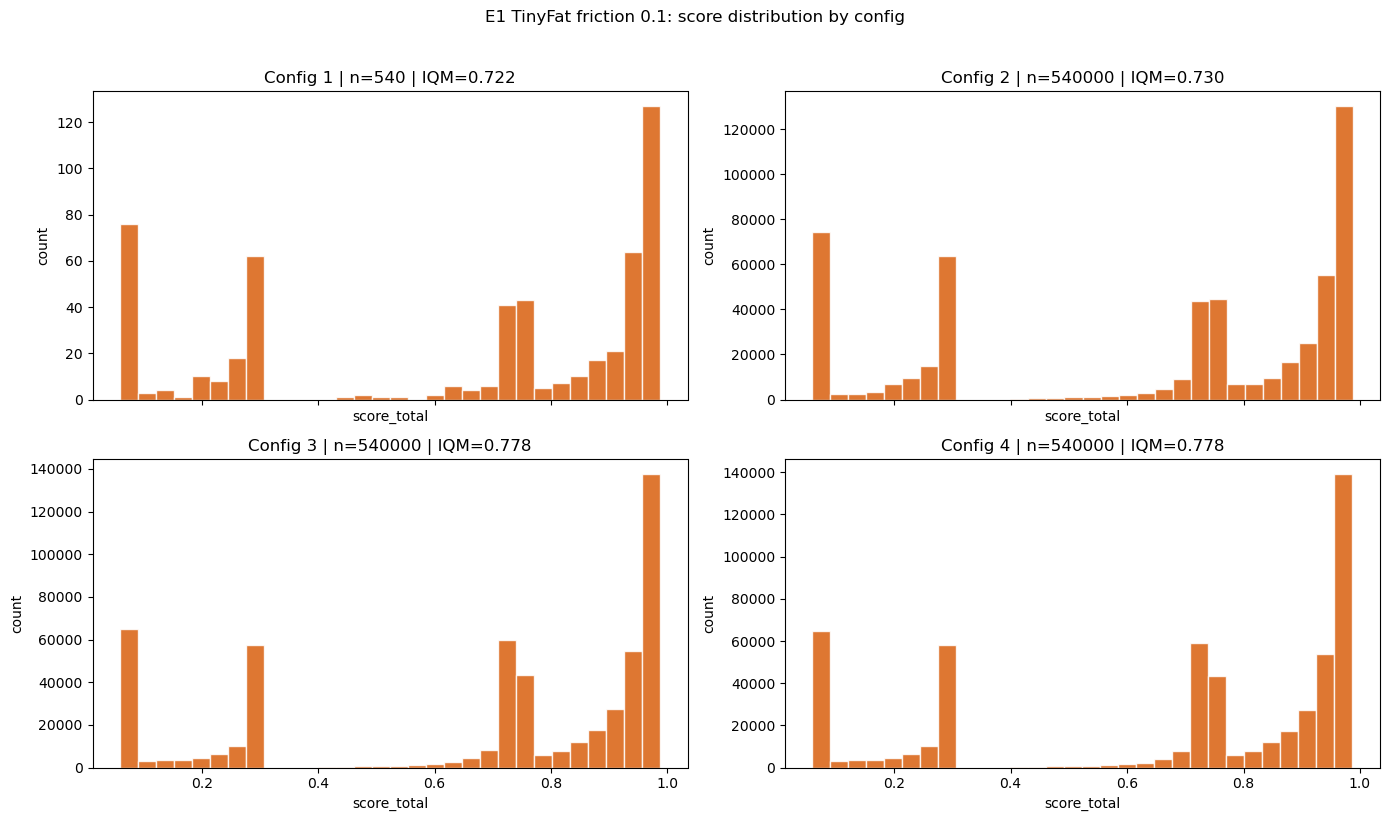

In [3]:
# E1 TinyFat friction 0.1: Step 2 - baseline score distribution
if trial_df_01.empty or "score_total" not in trial_df_01.columns:
    display(Markdown("### No readable trial rows yet\nThe coverage table above is still useful, but score analysis waits until at least one readable `trials.h5` exists."))
else:
    summary_df_01 = pd.DataFrame(summarize_trials_by_config(trial_rows_01))
    display(Markdown("### Pooled trial-score summary by config"))
    display(summary_df_01)

    config_ids_01 = sorted(int(c) for c in trial_df_01["config_id"].dropna().unique())
    n_axes_01 = max(1, len(config_ids_01))
    n_cols_01 = min(2, n_axes_01)
    n_rows_01 = (n_axes_01 + n_cols_01 - 1) // n_cols_01
    fig, axes = plt.subplots(n_rows_01, n_cols_01, figsize=(7 * n_cols_01, 4 * n_rows_01), sharex=True, sharey=False)
    axes = list(axes.ravel()) if hasattr(axes, "ravel") else [axes]

    for idx, config_id in enumerate(config_ids_01):
        ax = axes[idx]
        subset = trial_df_01.loc[trial_df_01["config_id"] == config_id, "score_total"].dropna().astype(float)
        ax.hist(subset, bins=30, alpha=0.85, color="#d95f0e", edgecolor="white")
        ax.set_title(f"Config {config_id} | n={len(subset)} | IQM={iqm(subset):.3f}")
        ax.set_xlabel("score_total")
        ax.set_ylabel("count")

    for ax in axes[len(config_ids_01):]:
        ax.axis("off")

    fig.suptitle("E1 TinyFat friction 0.1: score distribution by config", y=1.02)
    fig.tight_layout()
    hist_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / "e1_tinyfat_friction_01_score_hist_by_config.png"
    fig.savefig(hist_path_01, dpi=200, bbox_inches="tight")
    display(Markdown(f"- saved histogram: `{hist_path_01}`"))


### Step 3: signal-to-noise ratio

### Step 2b: general performance analysis


### General performance dataframe
Per-cell rows: `144`; unique anatomy/target combinations: `36`. The config bars below average the per-anatomy/target success rates first, so each combination has the same weight.

,config_id,anatomy_id,target_index,n_trials,success_rate,mean_score,median_score,iqm_score,mean_score_success,mean_score_efficiency,...,mean_wire_force_normal_trial_max_N,mean_wire_force_normal_trial_mean_N,mean_wire_force_magnitude_trial_max_N,mean_wire_force_magnitude_trial_mean_N,mean_tip_force_normal_trial_max_N,mean_tip_force_normal_trial_mean_N,mean_tip_force_magnitude_trial_max_N,mean_tip_force_magnitude_trial_mean_N,mean_force_within_safety_threshold,mean_force_available_for_score
0,1,Tree_1382,0,15,0.533333,0.498543,0.636107,0.511339,0.533333,0.356156,...,4.597775,0.474701,4.598386,0.477848,3.664695,0.288146,3.664695,0.289545,0.600000,1.0
1,1,Tree_1382,1,15,0.866667,0.741698,0.850443,0.829053,0.866667,0.659326,...,2.246274,0.334122,2.246795,0.341212,2.071640,0.251067,2.071640,0.254613,0.733333,1.0
2,1,Tree_1382,2,15,0.133333,0.277742,0.240801,0.219973,0.133333,0.090557,...,3.733939,0.364176,3.747701,0.370684,3.091238,0.288154,3.091238,0.289236,0.666667,1.0
3,1,Tree_1882,0,15,0.733333,0.641124,0.729023,0.703210,0.733333,0.527995,...,2.823129,0.374977,2.918138,0.385385,2.397397,0.287538,2.521166,0.292693,0.666667,1.0
4,1,Tree_1882,1,15,0.666667,0.619504,0.733848,0.693538,0.666667,0.564431,...,5.479006,0.728461,5.534684,0.747545,3.457734,0.421075,3.471052,0.423381,0.600000,1.0
5,1,Tree_1882,2,15,0.866667,0.779649,0.816214,0.847167,0.866667,0.728195,...,2.588067,0.436727,2.588067,0.438454,2.266987,0.285458,2.267135,0.285737,0.733333,1.0
6,1,Tree_1996,0,15,0.466667,0.495045,0.291937,0.489166,0.466667,0.367835,...,5.030723,1.045071,5.035145,1.056410,3.998905,0.410313,3.998905,0.411728,0.666667,1.0
7,1,Tree_1996,1,15,0.333333,0.399934,0.293819,0.334114,0.333333,0.284284,...,3.825971,0.586683,3.827849,0.592533,3.245658,0.456711,3.245658,0.457883,0.600000,1.0
8,1,Tree_1996,2,15,1.000000,0.893968,0.959453,0.916542,1.000000,0.928996,...,1.792153,0.349651,1.795243,0.354491,1.477027,0.251467,1.486814,0.255115,0.666667,1.0
9,1,Tree_5348,0,15,1.000000,0.901573,0.972427,0.928052,1.000000,0.939339,...,1.554888,0.250633,1.556958,0.256393,1.547015,0.227106,1.550709,0.230582,0.733333,1.0


### Config summary: success, score, and force terms

,config_id,anatomy_target_combinations,mean_success_rate,std_success_rate,mean_score_over_combinations,iqm_score_over_combinations,mean_trials_per_combination,mean_wire_force_normal_trial_max_N,mean_wire_force_normal_trial_mean_N,mean_wire_force_magnitude_trial_max_N,mean_wire_force_magnitude_trial_mean_N,mean_tip_force_normal_trial_max_N,mean_tip_force_normal_trial_mean_N,mean_tip_force_magnitude_trial_max_N,mean_tip_force_magnitude_trial_mean_N,mean_force_within_safety_threshold,mean_force_available_for_score
0,1,36,0.662963,0.263767,0.638474,0.714145,15.0,3.387421,0.524524,3.463784,0.541411,2.627891,0.328530,2.675789,0.333853,0.696296,0.998148
1,2,36,0.671828,0.253126,0.643799,0.741245,15000.0,3.450925,0.508787,3.520237,0.525643,2.598590,0.314805,2.627463,0.320486,0.703861,0.999037
2,3,36,0.715500,0.239989,0.672410,0.770864,15000.0,3.438307,0.511288,3.516624,0.524784,2.440805,0.288423,2.467939,0.294589,0.705637,1.000000
3,4,36,0.714624,0.241127,0.672250,0.769042,15000.0,3.446850,0.513186,3.527304,0.526438,2.429579,0.285976,2.456626,0.291878,0.706996,1.000000


- saved success-rate plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_mean_success_rate_by_config.png`

- saved mean-score plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_mean_score_by_config.png`

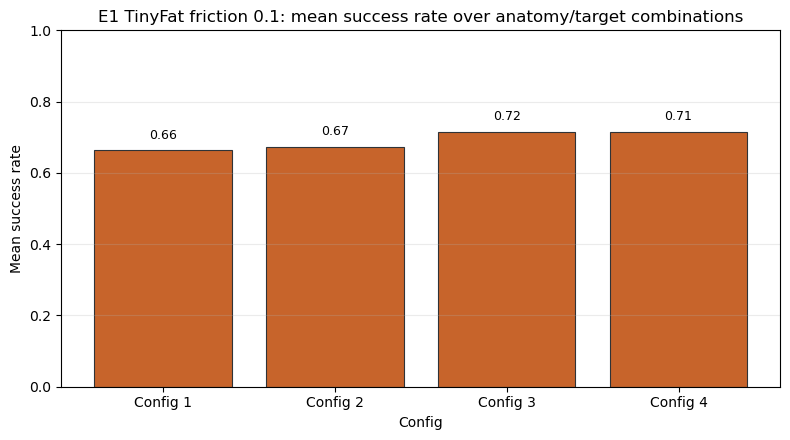

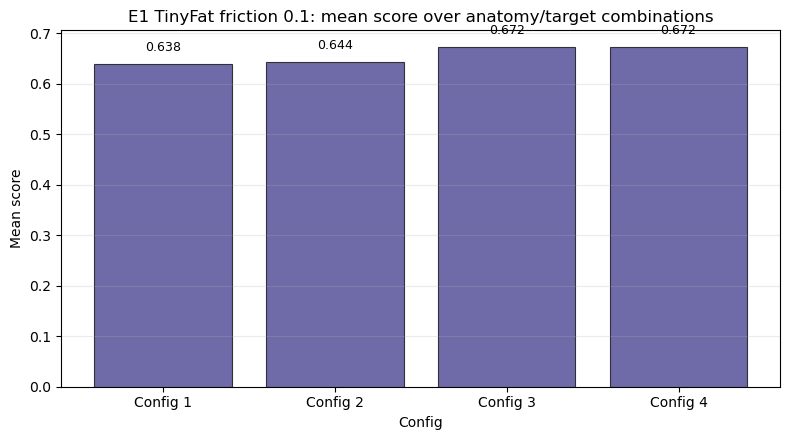

In [4]:
# E1 TinyFat friction 0.1: Step 2b - general performance analysis
if trial_df_01.empty:
    display(Markdown("No performance dataframe could be built because there are no readable trial rows."))
else:
    _analysis_df_01 = trial_df_01.copy()

    if "success" in _analysis_df_01.columns:
        _success_raw_01 = _analysis_df_01["success"]
        if pd.api.types.is_bool_dtype(_success_raw_01):
            _analysis_df_01["success_numeric"] = _success_raw_01.astype(float)
        else:
            _success_mapped_01 = _success_raw_01.map({True: 1.0, False: 0.0, "true": 1.0, "false": 0.0, "True": 1.0, "False": 0.0})
            _analysis_df_01["success_numeric"] = _success_mapped_01.fillna(pd.to_numeric(_success_raw_01, errors="coerce"))
    elif "score_success" in _analysis_df_01.columns:
        _analysis_df_01["success_numeric"] = pd.to_numeric(_analysis_df_01["score_success"], errors="coerce")
    else:
        raise KeyError("Expected either `success` or `score_success` in the trial dataframe.")

    for _column in ["config_id", "target_index", "score_total", "success_numeric"]:
        if _column in _analysis_df_01.columns:
            _analysis_df_01[_column] = pd.to_numeric(_analysis_df_01[_column], errors="coerce")

    _score_component_cols_01 = [
        _column for _column in [
            "score_success",
            "score_efficiency",
            "score_safety",
            "score_smoothness",
        ] if _column in _analysis_df_01.columns
    ]
    _force_cols_01 = [
        _column for _column in _analysis_df_01.columns
        if "force" in _column and pd.api.types.is_numeric_dtype(pd.to_numeric(_analysis_df_01[_column], errors="coerce"))
    ]
    _force_summary_cols_01 = [
        _column for _column in [
            "wire_force_normal_trial_max_N",
            "wire_force_normal_trial_mean_N",
            "wire_force_magnitude_trial_max_N",
            "wire_force_magnitude_trial_mean_N",
            "tip_force_normal_trial_max_N",
            "tip_force_normal_trial_mean_N",
            "tip_force_magnitude_trial_max_N",
            "tip_force_magnitude_trial_mean_N",
            "force_within_safety_threshold",
            "force_available_for_score",
        ] if _column in _force_cols_01 or _column in _analysis_df_01.columns
    ]
    for _column in _score_component_cols_01 + _force_summary_cols_01:
        _analysis_df_01[_column] = pd.to_numeric(_analysis_df_01[_column], errors="coerce")

    _group_cols_01 = ["config_id", "anatomy_id", "target_index"]
    _agg_spec_01 = {
        "n_trials": ("score_total", "size"),
        "success_rate": ("success_numeric", "mean"),
        "mean_score": ("score_total", "mean"),
        "median_score": ("score_total", "median"),
        "iqm_score": ("score_total", lambda s: iqm(s.dropna().tolist())),
    }
    for _column in _score_component_cols_01:
        _agg_spec_01[f"mean_{_column}"] = (_column, "mean")
    for _column in _force_summary_cols_01:
        _agg_spec_01[f"mean_{_column}"] = (_column, "mean")

    performance_cell_df_01 = (
        _analysis_df_01
        .dropna(subset=["config_id", "anatomy_id", "target_index"])
        .groupby(_group_cols_01, dropna=False)
        .agg(**_agg_spec_01)
        .reset_index()
        .sort_values(_group_cols_01)
        .reset_index(drop=True)
    )

    performance_config_df_01 = (
        performance_cell_df_01
        .groupby("config_id", dropna=False)
        .agg(
            anatomy_target_combinations=("success_rate", "count"),
            mean_success_rate=("success_rate", "mean"),
            std_success_rate=("success_rate", "std"),
            mean_score_over_combinations=("mean_score", "mean"),
            iqm_score_over_combinations=("iqm_score", lambda s: iqm(s.dropna().tolist())),
            mean_trials_per_combination=("n_trials", "mean"),
        )
        .reset_index()
        .sort_values("config_id")
        .reset_index(drop=True)
    )

    _force_mean_cols_01 = [
        _column for _column in performance_cell_df_01.columns
        if _column.startswith("mean_") and "force" in _column
    ]
    if _force_mean_cols_01:
        _force_config_df_01 = (
            performance_cell_df_01
            .groupby("config_id", dropna=False)[_force_mean_cols_01]
            .mean()
            .reset_index()
            .sort_values("config_id")
            .reset_index(drop=True)
        )
        performance_config_df_01 = performance_config_df_01.merge(_force_config_df_01, on="config_id", how="left")

    _n_cells_01 = int(performance_cell_df_01[["anatomy_id", "target_index"]].drop_duplicates().shape[0])
    display(Markdown(
        f"### General performance dataframe\n"
        f"Per-cell rows: `{len(performance_cell_df_01)}`; unique anatomy/target combinations: `{_n_cells_01}`. "
        "The config bars below average the per-anatomy/target success rates first, so each combination has the same weight."
    ))
    display(performance_cell_df_01.head(20))

    display(Markdown("### Config summary: success, score, and force terms"))
    display(performance_config_df_01)

    _plot_df_01 = performance_config_df_01.copy()
    _plot_df_01["config_label"] = _plot_df_01["config_id"].map(lambda value: f"Config {int(value)}" if pd.notna(value) else "Config n/a")

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(_plot_df_01["config_label"], _plot_df_01["mean_success_rate"], color="#c7642b", edgecolor="#2f3337", linewidth=0.8)
    ax.set_ylim(0, 1)
    ax.set_ylabel("Mean success rate")
    ax.set_xlabel("Config")
    ax.set_title("E1 TinyFat friction 0.1: mean success rate over anatomy/target combinations")
    ax.grid(axis="y", alpha=0.25)
    for _idx, _row in _plot_df_01.iterrows():
        _value = float(_row["mean_success_rate"])
        ax.text(_idx, min(0.98, _value + 0.025), f"{_value:.2f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    success_plot_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / "e1_tinyfat_friction_01_mean_success_rate_by_config.png"
    fig.savefig(success_plot_path_01, dpi=200, bbox_inches="tight")
    display(Markdown(f"- saved success-rate plot: `{success_plot_path_01}`"))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.bar(_plot_df_01["config_label"], _plot_df_01["mean_score_over_combinations"], color="#6f6aa8", edgecolor="#2f3337", linewidth=0.8)
    ax.set_ylabel("Mean score")
    ax.set_xlabel("Config")
    ax.set_title("E1 TinyFat friction 0.1: mean score over anatomy/target combinations")
    ax.grid(axis="y", alpha=0.25)
    _score_min = _plot_df_01["mean_score_over_combinations"].min()
    _score_max = _plot_df_01["mean_score_over_combinations"].max()
    _label_offset = max(0.02, float((_score_max - _score_min) * 0.03)) if pd.notna(_score_max) and pd.notna(_score_min) else 0.02
    for _idx, _row in _plot_df_01.iterrows():
        _value = float(_row["mean_score_over_combinations"])
        ax.text(_idx, _value + _label_offset, f"{_value:.3f}", ha="center", va="bottom", fontsize=9)
    fig.tight_layout()
    score_plot_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / "e1_tinyfat_friction_01_mean_score_by_config.png"
    fig.savefig(score_plot_path_01, dpi=200, bbox_inches="tight")
    display(Markdown(f"- saved mean-score plot: `{score_plot_path_01}`"))


### SNR summary by anatomy/target group

,config_id,anatomy_id,target_index,n_wires,between_sigma,within_sigma,snr,snr_boot_low,snr_boot_high
0,1,Tree_1382,0,15,0.322705,0.0,NaN,NaN,NaN
1,1,Tree_1382,1,15,0.269454,0.0,NaN,NaN,NaN
2,1,Tree_1382,2,15,0.248281,0.0,NaN,NaN,NaN
3,1,Tree_1882,0,15,0.330361,0.0,NaN,NaN,NaN
4,1,Tree_1882,1,15,0.349235,0.0,NaN,NaN,NaN


### Config-level SNR summary

,config_id,n_groups,snr_iqm,snr_mean,snr_median,within_sigma_iqm,between_sigma_iqm
0,1,0,NaN,NaN,NaN,0.000000,0.301535
1,2,36,2.618950,3.404555,2.587263,0.103846,0.276668
2,3,36,2.786754,3.401169,2.804748,0.100646,0.264955
3,4,36,2.771503,3.280994,2.828006,0.101089,0.265140


- saved SNR plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_snr_by_config.png`

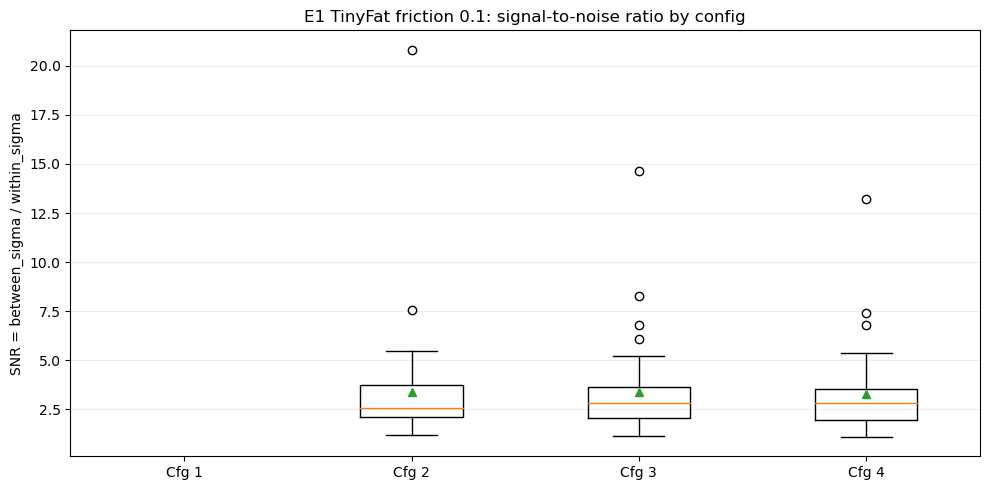

In [5]:
# E1 TinyFat friction 0.1: Step 3 - signal-to-noise ratio
if trial_df_01.empty:
    display(Markdown("No SNR rows could be built because there are no readable trial rows."))
else:
    snr_rows_01 = compute_snr_table(trial_rows_01, aggregate_fn=iqm, n_boot=300, seed=42)
    snr_df_01 = pd.DataFrame(snr_rows_01)
    if snr_df_01.empty:
        display(Markdown("No SNR rows could be built from the readable trial table."))
    else:
        display(Markdown("### SNR summary by anatomy/target group"))
        display(snr_df_01.head())

        config_summary_01 = snr_df_01.groupby("config_id", dropna=False).agg(
            n_groups=("snr", "count"),
            snr_iqm=("snr", lambda s: iqm(s.dropna().tolist())),
            snr_mean=("snr", "mean"),
            snr_median=("snr", "median"),
            within_sigma_iqm=("within_sigma", lambda s: iqm(s.dropna().tolist())),
            between_sigma_iqm=("between_sigma", lambda s: iqm(s.dropna().tolist())),
        ).reset_index()
        display(Markdown("### Config-level SNR summary"))
        display(config_summary_01)

        fig, ax = plt.subplots(figsize=(10, 5))
        snr_config_ids_01 = sorted(snr_df_01["config_id"].dropna().unique())
        grouped_01 = [snr_df_01.loc[snr_df_01["config_id"] == config_id, "snr"].dropna().astype(float).to_numpy() for config_id in snr_config_ids_01]
        ax.boxplot(grouped_01, labels=[f"Cfg {int(c)}" for c in snr_config_ids_01], showmeans=True)
        ax.set_ylabel("SNR = between_sigma / within_sigma")
        ax.set_title("E1 TinyFat friction 0.1: signal-to-noise ratio by config")
        ax.grid(axis="y", alpha=0.25)
        fig.tight_layout()
        snr_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / "e1_tinyfat_friction_01_snr_by_config.png"
        fig.savefig(snr_path_01, dpi=200, bbox_inches="tight")
        display(Markdown(f"- saved SNR plot: `{snr_path_01}`"))


### Step 4: ranking consistency

### Kendall-tau summary across config pairs

,config_left,config_right,mean_tau,median_tau,n_groups
0,1,1,1.000000,1.000000,36
1,1,2,0.792578,0.790476,36
2,1,3,0.659088,0.689724,36
3,1,4,0.651973,0.664136,36
4,2,1,0.792578,0.790476,36
5,2,2,1.000000,1.000000,36
6,2,3,0.679820,0.687441,36
7,2,4,0.682176,0.714286,36
8,3,1,0.659088,0.689724,36
9,3,2,0.679820,0.687441,36


- saved Kendall-tau plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_kendall_tau_matrix.png`

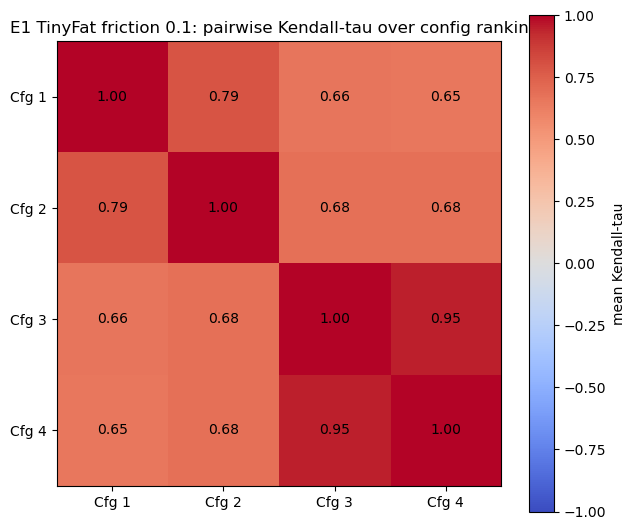

In [6]:
# E1 TinyFat friction 0.1: Step 4 - ranking consistency
if trial_df_01.empty:
    display(Markdown("No Kendall-tau rows could be built because there are no readable trial rows."))
else:
    kendall_rows_01, candidate_rows_for_tau_01 = compute_kendall_matrix(trial_rows_01, aggregate_fn=iqm)
    kendall_df_01 = pd.DataFrame(kendall_rows_01)
    if kendall_df_01.empty:
        display(Markdown("No Kendall-tau rows could be built from the readable trial table."))
    else:
        display(Markdown("### Kendall-tau summary across config pairs"))
        display(kendall_df_01.sort_values(["config_left", "config_right"]))

        matrix_config_ids_01 = sorted(set(kendall_df_01["config_left"]).union(set(kendall_df_01["config_right"])))
        matrix_01 = pd.DataFrame(index=matrix_config_ids_01, columns=matrix_config_ids_01, dtype=float)
        for _, row in kendall_df_01.iterrows():
            matrix_01.loc[int(row["config_left"]), int(row["config_right"])] = row["mean_tau"]

        fig, ax = plt.subplots(figsize=(6.5, 5.5))
        im = ax.imshow(matrix_01.to_numpy(dtype=float), vmin=-1, vmax=1, cmap="coolwarm")
        ax.set_xticks(range(len(matrix_config_ids_01)))
        ax.set_yticks(range(len(matrix_config_ids_01)))
        ax.set_xticklabels([f"Cfg {c}" for c in matrix_config_ids_01])
        ax.set_yticklabels([f"Cfg {c}" for c in matrix_config_ids_01])
        ax.set_title("E1 TinyFat friction 0.1: pairwise Kendall-tau over config rankings")
        for i, left in enumerate(matrix_config_ids_01):
            for j, right in enumerate(matrix_config_ids_01):
                value = matrix_01.loc[left, right]
                if pd.notna(value):
                    ax.text(j, i, f"{value:.2f}", ha="center", va="center", color="black")
        fig.colorbar(im, ax=ax, label="mean Kendall-tau")
        fig.tight_layout()
        tau_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / "e1_tinyfat_friction_01_kendall_tau_matrix.png"
        fig.savefig(tau_path_01, dpi=200, bbox_inches="tight")
        display(Markdown(f"- saved Kendall-tau plot: `{tau_path_01}`"))


### Step 5: convergence in k

### Within-wire noise as a function of k

,config_id,k,within_sigma,between_sigma,snr
0,1,1,0.0,0.273138,NaN
1,1,2,0.0,0.273138,NaN
2,1,5,0.0,0.273138,NaN
3,1,10,0.0,0.273138,NaN
4,1,20,0.0,0.273138,NaN


- saved k-convergence plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_within_sigma_vs_k.png`

### Mean-aggregated convergence as a function of k

,config_id,k,within_sigma,between_sigma,snr
0,1,1,0.0,0.273138,NaN
1,1,2,0.0,0.273138,NaN
2,1,5,0.0,0.273138,NaN
3,1,10,0.0,0.273138,NaN
4,1,20,0.0,0.273138,NaN


- saved mean-aggregate k-convergence plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_mean_aggregate_convergence_vs_k.png`

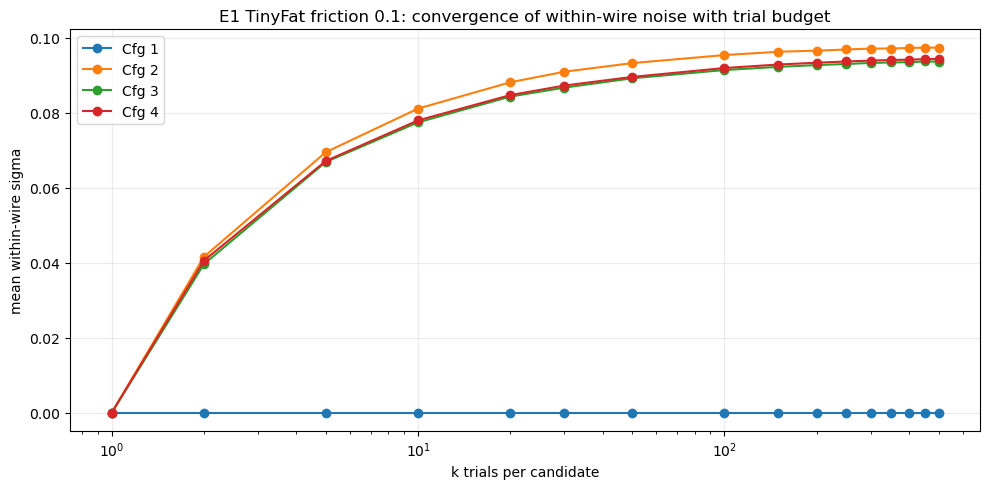

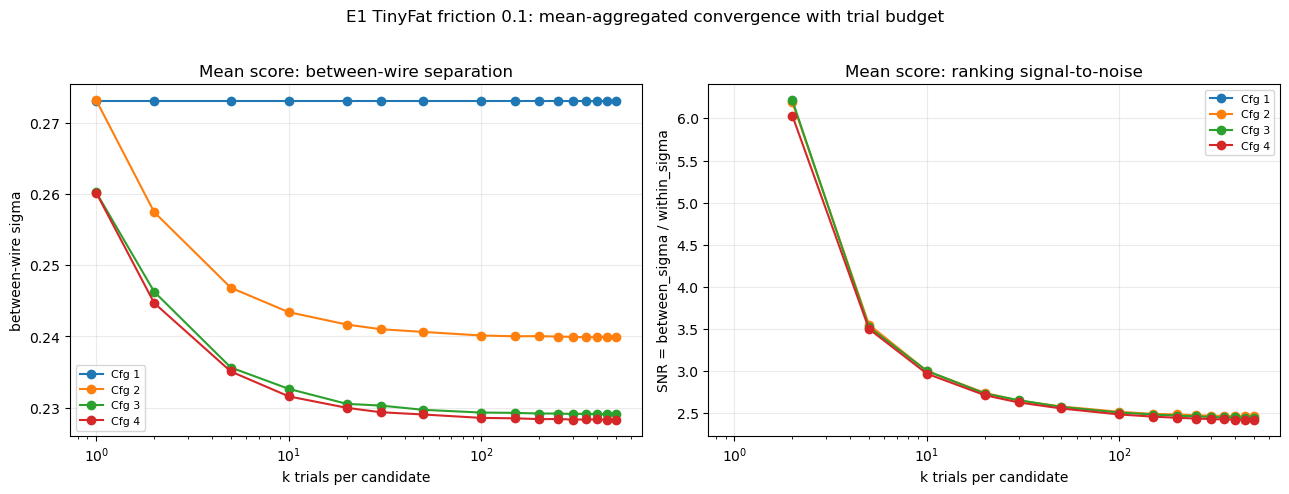

In [7]:
# E1 TinyFat friction 0.1: Step 5 - convergence in k
if trial_df_01.empty:
    display(Markdown("No convergence rows could be built because there are no readable trial rows."))
else:
    k_values_01 = [1, 2, 5, 10, 20, 30, 50, 100,150,200,250,300,350,400,450,500]
    k_conv_rows_01 = compute_k_convergence_table(trial_rows_01, aggregate_fn=iqm, k_values=k_values_01, n_boot=120, seed=99)
    k_conv_df_01 = pd.DataFrame(k_conv_rows_01)
    if k_conv_df_01.empty:
        display(Markdown("No convergence rows could be built from the readable trial table."))
    else:
        display(Markdown("### Within-wire noise as a function of k"))
        display(k_conv_df_01.head())

        fig, ax = plt.subplots(figsize=(10, 5))
        for config_id in sorted(k_conv_df_01["config_id"].dropna().unique()):
            subset = k_conv_df_01.loc[k_conv_df_01["config_id"] == config_id].sort_values("k")
            ax.plot(subset["k"], subset["within_sigma"], marker="o", label=f"Cfg {int(config_id)}")
        ax.set_xscale("log")
        ax.set_xlabel("k trials per candidate")
        ax.set_ylabel("mean within-wire sigma")
        ax.set_title("E1 TinyFat friction 0.1: convergence of within-wire noise with trial budget")
        ax.grid(True, alpha=0.25)
        ax.legend()
        fig.tight_layout()
        k_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / "e1_tinyfat_friction_01_within_sigma_vs_k.png"
        fig.savefig(k_path_01, dpi=200, bbox_inches="tight")
        display(Markdown(f"- saved k-convergence plot: `{k_path_01}`"))


        def arithmetic_mean_01(values):
            values = [float(value) for value in values if value is not None and pd.notna(value)]
            return float(sum(values) / len(values)) if values else float("nan")

        k_conv_mean_rows_01 = compute_k_convergence_table(
            trial_rows_01,
            aggregate_fn=arithmetic_mean_01,
            k_values=k_values_01,
            n_boot=120,
            seed=99,
        )
        k_conv_mean_df_01 = pd.DataFrame(k_conv_mean_rows_01)
        if not k_conv_mean_df_01.empty:
            display(Markdown("### Mean-aggregated convergence as a function of k"))
            display(k_conv_mean_df_01.head())

            fig, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
            for config_id in sorted(k_conv_mean_df_01["config_id"].dropna().unique()):
                subset = k_conv_mean_df_01.loc[k_conv_mean_df_01["config_id"] == config_id].sort_values("k")
                axes[0].plot(subset["k"], subset["between_sigma"], marker="o", label=f"Cfg {int(config_id)}")
                axes[1].plot(subset["k"], subset["snr"], marker="o", label=f"Cfg {int(config_id)}")

            axes[0].set_ylabel("between-wire sigma")
            axes[0].set_title("Mean score: between-wire separation")
            axes[1].set_ylabel("SNR = between_sigma / within_sigma")
            axes[1].set_title("Mean score: ranking signal-to-noise")
            for ax in axes:
                ax.set_xscale("log")
                ax.set_xlabel("k trials per candidate")
                ax.grid(True, alpha=0.25)
                ax.legend(fontsize=8)
            fig.suptitle("E1 TinyFat friction 0.1: mean-aggregated convergence with trial budget", y=1.02)
            fig.tight_layout()
            k_mean_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / "e1_tinyfat_friction_01_mean_aggregate_convergence_vs_k.png"
            fig.savefig(k_mean_path_01, dpi=200, bbox_inches="tight")
            display(Markdown(f"- saved mean-aggregate k-convergence plot: `{k_mean_path_01}`"))


### Step 5b: ranking stability versus full trial budget


### Ranking stability versus the full available-trial ranking

,config_id,anatomy_id,target_index,k,n_wires,n_boot,tau_mean_vs_full,tau_median_vs_full,tau_p10_vs_full,tau_min_vs_full
0,1,Tree_1382,0,1,15,120,1.0,1.0,1.0,1.0
1,1,Tree_1382,0,2,15,120,1.0,1.0,1.0,1.0
2,1,Tree_1382,0,5,15,120,1.0,1.0,1.0,1.0
3,1,Tree_1382,0,10,15,120,1.0,1.0,1.0,1.0
4,1,Tree_1382,0,20,15,120,1.0,1.0,1.0,1.0


### Config-level ranking stability by k

,config_id,k,n_groups,tau_mean,tau_median,tau_p10
0,1,1,36,1.000000,1.000000,1.000000
1,1,2,36,1.000000,1.000000,1.000000
2,1,5,36,1.000000,1.000000,1.000000
3,1,10,36,1.000000,1.000000,1.000000
4,1,20,36,1.000000,1.000000,1.000000
...,...,...,...,...,...,...
67,4,400,36,0.984575,0.980952,0.963923
68,4,450,36,0.985437,0.980952,0.966853
69,4,500,36,0.986370,1.000000,0.968746
70,4,750,36,0.988599,1.000000,0.972698


### Smallest k that is close to the full-trial ranking

,config_id,tau_median_target,tau_p10_target,recommended_k,best_available_k,tau_median_at_best_k,tau_p10_at_best_k
0,1,0.95,0.9,1,1000,1.0,1.000000
1,2,0.95,0.9,30,1000,1.0,0.975240
2,3,0.95,0.9,30,1000,1.0,0.979191
3,4,0.95,0.9,30,1000,1.0,0.975410


- saved ranking-stability plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_ranking_stability_vs_k.png`

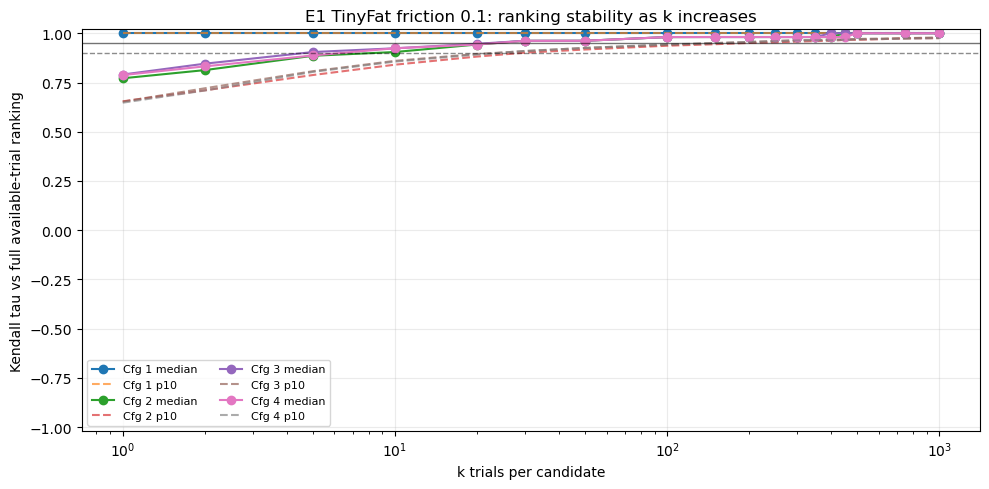

In [8]:
# E1 TinyFat friction 0.1: Step 5b - ranking stability versus full trial budget
if trial_df_01.empty:
    display(Markdown("No ranking-stability rows could be built because there are no readable trial rows."))
else:
    import random
    from statistics import mean, median
    from scipy.stats import kendalltau

    ranking_k_values_01 = [1, 2, 5, 10, 20, 30, 50, 100, 150, 200, 250, 300, 350, 400, 450, 500, 750, 1000]
    ranking_n_boot_01 = 120
    ranking_tau_target_01 = 0.95
    ranking_tau_p10_target_01 = 0.90

    def _ranking_stability_vs_full_01(trial_rows, *, k_values, n_boot, seed):
        grouped = {}
        for row in trial_rows:
            config_id = row.get("config_id")
            anatomy_id = row.get("anatomy_id")
            target_index = row.get("target_index")
            candidate_name = row.get("candidate_name") or row.get("candidate")
            score = row.get("score_total")
            if config_id is None or anatomy_id is None or target_index is None or candidate_name is None or score is None:
                continue
            key = (int(config_id), str(anatomy_id), int(target_index))
            grouped.setdefault(key, {}).setdefault(str(candidate_name), []).append(float(score))

        rows = []
        for (config_id, anatomy_id, target_index), wire_scores in sorted(grouped.items()):
            wire_scores = {name: scores for name, scores in wire_scores.items() if scores}
            if len(wire_scores) < 2:
                continue
            full_scores = {name: float(iqm(scores)) for name, scores in wire_scores.items()}
            shared_names = sorted(full_scores)
            full_vector = [full_scores[name] for name in shared_names]
            for k in k_values:
                taus = []
                rng = random.Random((seed + config_id * 100_003 + target_index * 1009 + int(k) * 37) & 0xFFFFFFFF)
                for _ in range(int(n_boot)):
                    sampled_scores = {}
                    for name in shared_names:
                        scores = wire_scores[name]
                        resampled = [scores[rng.randrange(len(scores))] for _ in range(int(k))]
                        sampled_scores[name] = float(iqm(resampled))
                    sampled_vector = [sampled_scores[name] for name in shared_names]
                    tau = kendalltau(full_vector, sampled_vector, nan_policy="omit").statistic
                    if tau is not None and pd.notna(tau):
                        taus.append(float(tau))
                if not taus:
                    continue
                taus_sorted = sorted(taus)
                p10_index = max(0, min(len(taus_sorted) - 1, int(round(0.10 * (len(taus_sorted) - 1)))))
                rows.append({
                    "config_id": config_id,
                    "anatomy_id": anatomy_id,
                    "target_index": target_index,
                    "k": int(k),
                    "n_wires": len(shared_names),
                    "n_boot": len(taus),
                    "tau_mean_vs_full": float(mean(taus)),
                    "tau_median_vs_full": float(median(taus)),
                    "tau_p10_vs_full": float(taus_sorted[p10_index]),
                    "tau_min_vs_full": float(min(taus)),
                })
        return rows

    ranking_k_rows_01 = _ranking_stability_vs_full_01(
        trial_rows_01,
        k_values=ranking_k_values_01,
        n_boot=ranking_n_boot_01,
        seed=1234,
    )
    ranking_k_df_01 = pd.DataFrame(ranking_k_rows_01)

    if ranking_k_df_01.empty:
        display(Markdown("No ranking-stability rows could be built from the readable trial table."))
    else:
        display(Markdown("### Ranking stability versus the full available-trial ranking"))
        display(ranking_k_df_01.head())

        ranking_k_summary_df_01 = (
            ranking_k_df_01
            .groupby(["config_id", "k"], dropna=False)
            .agg(
                n_groups=("tau_mean_vs_full", "count"),
                tau_mean=("tau_mean_vs_full", "mean"),
                tau_median=("tau_median_vs_full", "median"),
                tau_p10=("tau_p10_vs_full", "mean"),
            )
            .reset_index()
            .sort_values(["config_id", "k"])
            .reset_index(drop=True)
        )
        display(Markdown("### Config-level ranking stability by k"))
        display(ranking_k_summary_df_01)

        recommendation_rows_01 = []
        for config_id, subset in ranking_k_summary_df_01.groupby("config_id", dropna=False):
            subset = subset.sort_values("k")
            stable = subset.loc[
                (subset["tau_median"] >= ranking_tau_target_01)
                & (subset["tau_p10"] >= ranking_tau_p10_target_01)
            ]
            recommendation_rows_01.append({
                "config_id": int(config_id) if pd.notna(config_id) else config_id,
                "tau_median_target": ranking_tau_target_01,
                "tau_p10_target": ranking_tau_p10_target_01,
                "recommended_k": int(stable.iloc[0]["k"]) if not stable.empty else None,
                "best_available_k": int(subset.iloc[-1]["k"]),
                "tau_median_at_best_k": float(subset.iloc[-1]["tau_median"]),
                "tau_p10_at_best_k": float(subset.iloc[-1]["tau_p10"]),
            })
        ranking_k_recommendation_df_01 = pd.DataFrame(recommendation_rows_01)
        display(Markdown("### Smallest k that is close to the full-trial ranking"))
        display(ranking_k_recommendation_df_01)

        fig, ax = plt.subplots(figsize=(10, 5))
        for config_id in sorted(ranking_k_summary_df_01["config_id"].dropna().unique()):
            subset = ranking_k_summary_df_01.loc[ranking_k_summary_df_01["config_id"] == config_id].sort_values("k")
            ax.plot(subset["k"], subset["tau_median"], marker="o", label=f"Cfg {int(config_id)} median")
            ax.plot(subset["k"], subset["tau_p10"], linestyle="--", alpha=0.65, label=f"Cfg {int(config_id)} p10")
        ax.axhline(ranking_tau_target_01, color="black", linewidth=1, alpha=0.55)
        ax.axhline(ranking_tau_p10_target_01, color="black", linewidth=1, linestyle="--", alpha=0.45)
        ax.set_xscale("log")
        ax.set_ylim(-1.02, 1.02)
        ax.set_xlabel("k trials per candidate")
        ax.set_ylabel("Kendall tau vs full available-trial ranking")
        ax.set_title("E1 TinyFat friction 0.1: ranking stability as k increases")
        ax.grid(True, alpha=0.25)
        ax.legend(ncol=2, fontsize=8)
        fig.tight_layout()
        ranking_k_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / "e1_tinyfat_friction_01_ranking_stability_vs_k.png"
        fig.savefig(ranking_k_path_01, dpi=200, bbox_inches="tight")
        display(Markdown(f"- saved ranking-stability plot: `{ranking_k_path_01}`"))


### Single-Anatomy Discrimination Analysis


### Reference within-wire sigma by config

,config_id,k,within_sigma
0,2,500,0.097359
1,3,500,0.093623
2,4,500,0.094333


### Config 2: reference within-wire sigma
Using `within_sigma` from the largest available convergence budget `k = 500` for this config. This gives `sigma_within = 0.0974` score units.

### Config 2: standard error and pairwise discrimination resolution

,k,SE_mean,discrimination_resolution_2SE
0,5,0.0435,0.0871
1,10,0.0308,0.0616
2,20,0.0218,0.0435
3,30,0.0178,0.0356
4,50,0.0138,0.0275
5,100,0.0097,0.0195
6,200,0.0069,0.0138
7,500,0.0044,0.0087
8,1000,0.0031,0.0062


...

### Config 4: standard error and pairwise discrimination resolution

,k,SE_mean,discrimination_resolution_2SE
0,5,0.0422,0.0844
1,10,0.0298,0.0597
2,20,0.0211,0.0422
3,30,0.0172,0.0344
4,50,0.0133,0.0267
5,100,0.0094,0.0189
6,200,0.0067,0.0133
7,500,0.0042,0.0084
8,1000,0.0030,0.0060


### Config 4: power analysis for single-anatomy pairwise comparisons

,effect_size_d,required_n_per_group,interpretation
0,0.100,14,"large effect, easily detectable"
1,0.050,56,"moderate effect, clinically relevant threshold"
2,0.034,121,achievable at k=30
3,0.020,350,"small effect, below clinical relevance"


- saved discrimination plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_single_anatomy_discrimination_config_4.png`

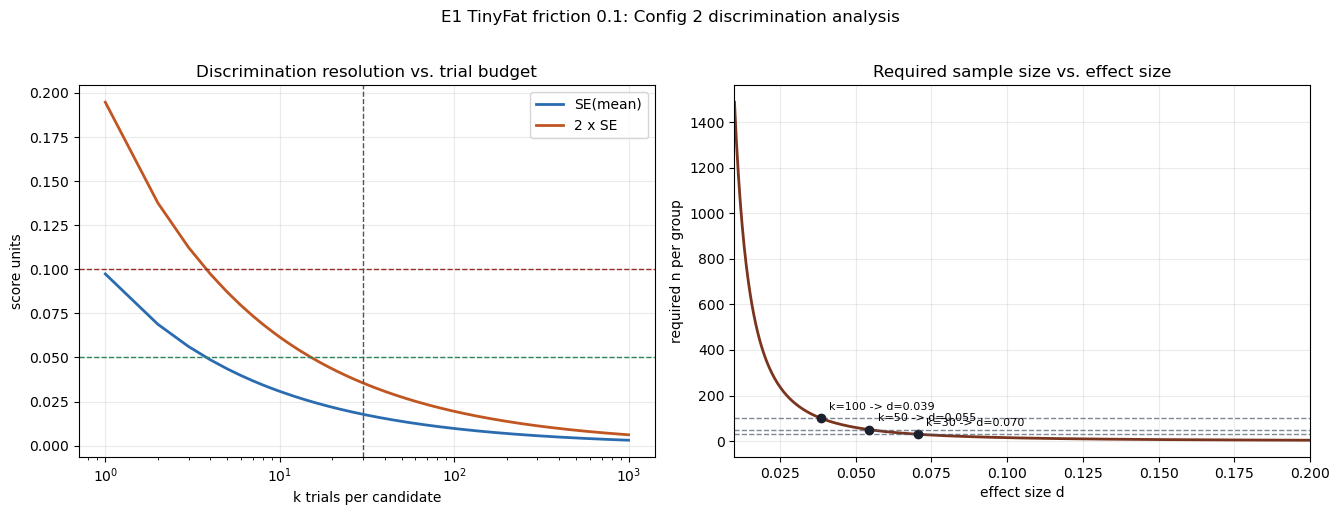

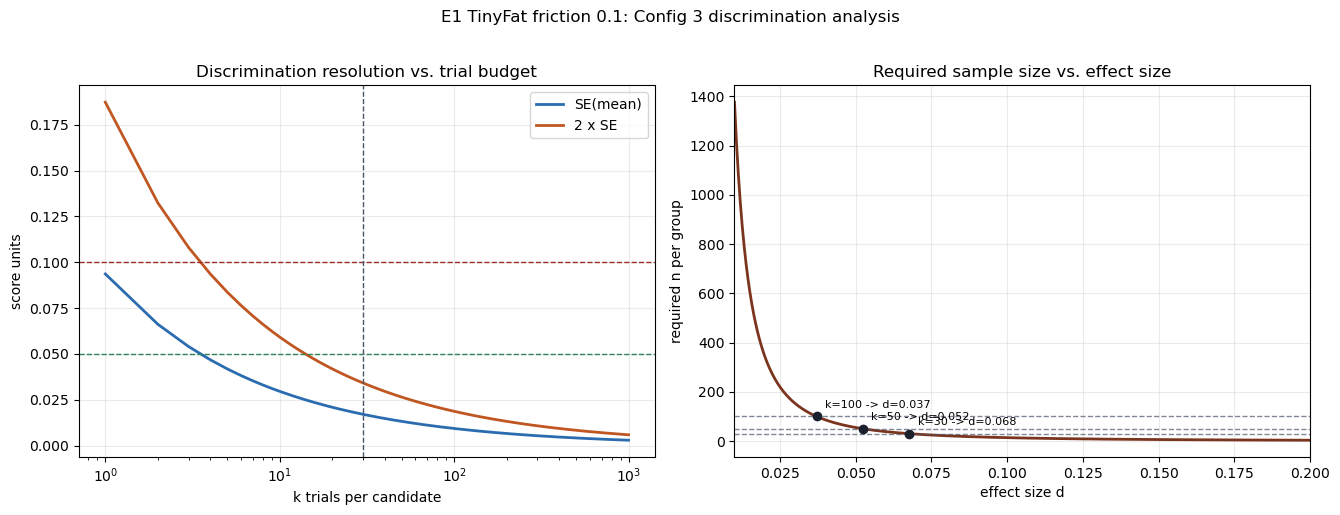

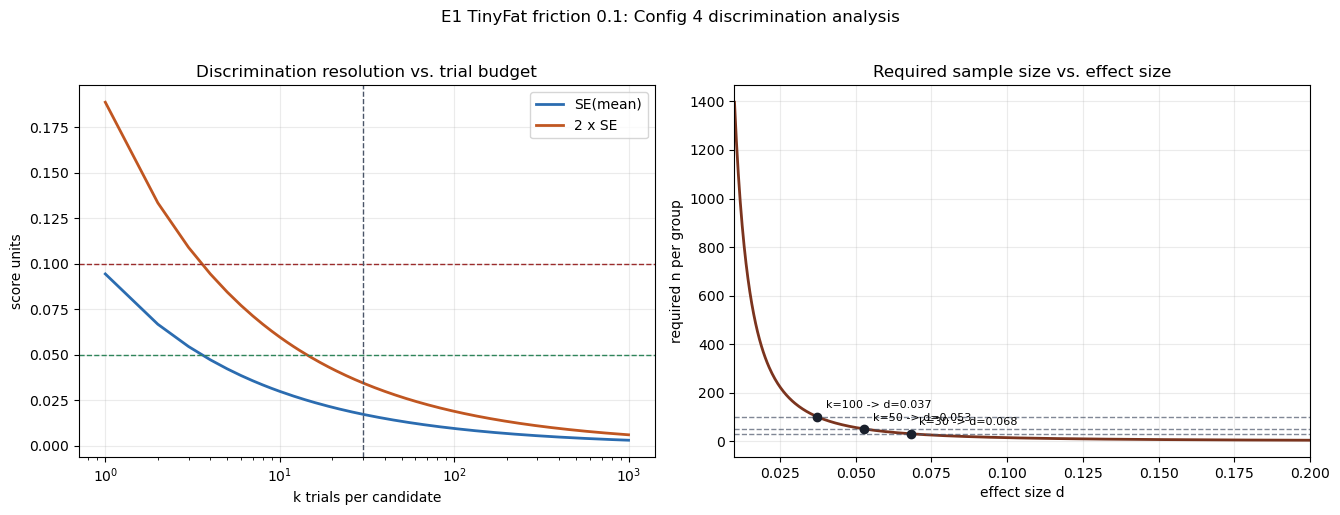

In [12]:
# E1 TinyFat friction 0.1: Single-Anatomy Discrimination Analysis
if "k_conv_df_01" not in globals() or k_conv_df_01.empty:
    display(Markdown("Run Step 5 first so the discrimination analysis can reuse `k_conv_df` without recomputing `within_sigma`."))
else:
    import math
    import numpy as np
    from scipy.stats import norm

    discrimination_reference_rows_01 = (
        k_conv_df_01
        .loc[k_conv_df_01["k"] == k_conv_df_01["k"].max()]
        .copy()
    )
    discrimination_reference_rows_01 = discrimination_reference_rows_01.loc[
        discrimination_reference_rows_01["within_sigma"].notna()
        & (discrimination_reference_rows_01["within_sigma"] > 0)
    ]

    if discrimination_reference_rows_01.empty:
        display(Markdown("No positive `within_sigma` reference values were available in `k_conv_df` for this friction setting."))
    else:
        discrimination_reference_rows_01 = (
            discrimination_reference_rows_01[["config_id", "k", "within_sigma"]]
            .sort_values("config_id")
            .reset_index(drop=True)
        )
        display(Markdown("### Reference within-wire sigma by config"))
        display(discrimination_reference_rows_01)

        discrimination_se_by_config_01 = {}
        discrimination_power_by_config_01 = {}

        alpha_01 = 0.05
        power_01 = 0.80
        z_alpha_half_01 = float(norm.ppf(1.0 - alpha_01 / 2.0))
        z_beta_01 = float(norm.ppf(power_01))
        se_k_values_01 = [5, 10, 20, 30, 50, 100, 200, 500, 1000]
        effect_specs_01 = [
            (0.10, "large effect, easily detectable"),
            (0.05, "moderate effect, clinically relevant threshold"),
            (0.034, "achievable at k=30"),
            (0.02, "small effect, below clinical relevance"),
        ]
        candidate_k_lines_01 = [30, 50, 100]

        for _ref_row in discrimination_reference_rows_01.to_dict("records"):
            config_id_01 = int(_ref_row["config_id"])
            reference_k_01 = int(_ref_row["k"])
            sigma_within_reference_01 = float(_ref_row["within_sigma"])

            display(Markdown(
                f"### Config {config_id_01}: reference within-wire sigma\n"
                f"Using `within_sigma` from the largest available convergence budget `k = {reference_k_01}` for this config. "
                f"This gives `sigma_within = {sigma_within_reference_01:.4f}` score units."
            ))

            se_rows_01 = []
            for k in se_k_values_01:
                se_mean = sigma_within_reference_01 / math.sqrt(float(k))
                se_rows_01.append({
                    "k": int(k),
                    "SE_mean": round(se_mean, 4),
                    "discrimination_resolution_2SE": round(2.0 * se_mean, 4),
                })
            discrimination_se_df_01 = pd.DataFrame(se_rows_01)
            discrimination_se_by_config_01[config_id_01] = discrimination_se_df_01.copy()
            display(Markdown(f"### Config {config_id_01}: standard error and pairwise discrimination resolution"))
            display(discrimination_se_df_01)

            power_rows_01 = []
            for effect_size_d, interpretation in effect_specs_01:
                required_n = 2.0 * (z_alpha_half_01 + z_beta_01) ** 2 * (sigma_within_reference_01 / effect_size_d) ** 2
                power_rows_01.append({
                    "effect_size_d": round(float(effect_size_d), 4),
                    "required_n_per_group": int(math.ceil(required_n)),
                    "interpretation": interpretation,
                })
            discrimination_power_df_01 = pd.DataFrame(power_rows_01)
            discrimination_power_by_config_01[config_id_01] = discrimination_power_df_01.copy()
            display(Markdown(f"### Config {config_id_01}: power analysis for single-anatomy pairwise comparisons"))
            display(discrimination_power_df_01)

            k_curve_01 = np.arange(1, 1001, dtype=float)
            se_curve_01 = sigma_within_reference_01 / np.sqrt(k_curve_01)
            resolution_curve_01 = 2.0 * se_curve_01

            d_curve_01 = np.linspace(0.01, 0.20, 600)
            n_curve_01 = 2.0 * (z_alpha_half_01 + z_beta_01) ** 2 * (sigma_within_reference_01 / d_curve_01) ** 2

            fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

            axes[0].plot(k_curve_01, se_curve_01, label="SE(mean)", color="#2b6cb0", linewidth=2)
            axes[0].plot(k_curve_01, resolution_curve_01, label="2 x SE", color="#c05621", linewidth=2)
            axes[0].axhline(0.05, color="#2f855a", linestyle="--", linewidth=1)
            axes[0].axhline(0.10, color="#9b2c2c", linestyle="--", linewidth=1)
            axes[0].axvline(30, color="#4a5568", linestyle="--", linewidth=1)
            axes[0].set_xscale("log")
            axes[0].set_xlabel("k trials per candidate")
            axes[0].set_ylabel("score units")
            axes[0].set_title("Discrimination resolution vs. trial budget")
            axes[0].grid(True, alpha=0.25)
            axes[0].legend()

            axes[1].plot(d_curve_01, n_curve_01, color="#7b341e", linewidth=2)
            for k_line in candidate_k_lines_01:
                axes[1].axhline(k_line, color="#4a5568", linestyle="--", linewidth=1, alpha=0.7)
                detectable_d = sigma_within_reference_01 * math.sqrt(2.0 * (z_alpha_half_01 + z_beta_01) ** 2 / float(k_line))
                axes[1].plot([detectable_d], [k_line], marker="o", color="#1a202c")
                axes[1].annotate(
                    f"k={k_line} -> d={detectable_d:.3f}",
                    xy=(detectable_d, k_line),
                    xytext=(6, 6),
                    textcoords="offset points",
                    fontsize=8,
                )
            axes[1].set_xlim(0.01, 0.20)
            axes[1].set_xlabel("effect size d")
            axes[1].set_ylabel("required n per group")
            axes[1].set_title("Required sample size vs. effect size")
            axes[1].grid(True, alpha=0.25)

            fig.suptitle(f"E1 TinyFat friction 0.1: Config {config_id_01} discrimination analysis", y=1.02)
            fig.tight_layout()
            discrimination_plot_path_01 = E1_TINYFAT_01_ANALYSIS_ROOT / f"e1_tinyfat_friction_01_single_anatomy_discrimination_config_{config_id_01}.png"
            fig.savefig(discrimination_plot_path_01, dpi=200, bbox_inches="tight")
            display(Markdown(f"- saved discrimination plot: `{discrimination_plot_path_01}`"))


### Step 6: E0-style step-budget summary

This repeats the E0-style reporting for this E1 friction setting: candidate summary table, success-step percentiles, suggested step cutoff, and the same four plots used in E0.

### Config 1: candidate summary

,execution_wire,n_trials,success_rate,score_mean,score_std,score_safety_mean,steps_total_mean,steps_total_p95,steps_to_success_mean,steps_to_success_p95,wire_force_normal_trial_max_mean_N,tip_force_normal_trial_max_mean_N
0,universal_ii/tight_j,36,0.944444,0.906956,0.161638,0.997456,207.166667,922.75,160.529412,527.75,0.076218,0.030970
1,universal_ii/standard_j,36,0.861111,0.865891,0.232413,0.998271,197.166667,1000.00,118.225806,217.50,0.066204,0.028750
2,amplatz_super_stiff/tight_j,36,0.916667,0.855094,0.202356,0.853329,230.222222,1000.00,160.242424,345.00,0.601771,0.255150
3,amplatz_super_stiff/standard_j,36,0.833333,0.817986,0.255363,0.911918,291.027778,1000.00,149.233333,375.60,0.451842,0.202420
4,amplatz_super_stiff/strong_hook,36,0.833333,0.794894,0.266517,0.808104,249.277778,1000.00,144.700000,386.20,0.709608,0.463080
5,universal_ii/gentle,36,0.750000,0.768028,0.279890,0.995348,404.750000,1000.00,206.333333,625.90,0.089275,0.063831
6,universal_ii/strong_hook,36,0.694444,0.755073,0.306650,0.996721,362.916667,1000.00,117.040000,205.60,0.089278,0.043174
7,steve_default/standard_j,36,0.805556,0.601470,0.274589,0.049409,286.500000,1000.00,133.137931,393.40,6.431851,5.113077
8,amplatz_super_stiff/gentle,36,0.555556,0.592080,0.380350,0.711078,494.861111,1000.00,134.550000,279.05,0.868207,0.647512
9,steve_default/strong_hook,36,0.777778,0.568117,0.277074,0.000000,264.777778,1000.00,145.571429,425.15,15.274987,10.949493


### Config 1: step-budget percentiles for successful trials

,quantile,steps_to_success
0,50,90.50
1,75,152.50
2,90,291.10
3,95,443.15
4,99,843.66


- config: `1`
- current max_episode_steps: `1000`
- suggested 95th-percentile cutoff: `450` steps
- successful trials analyzed: `358`
- all readable trials analyzed: `540`

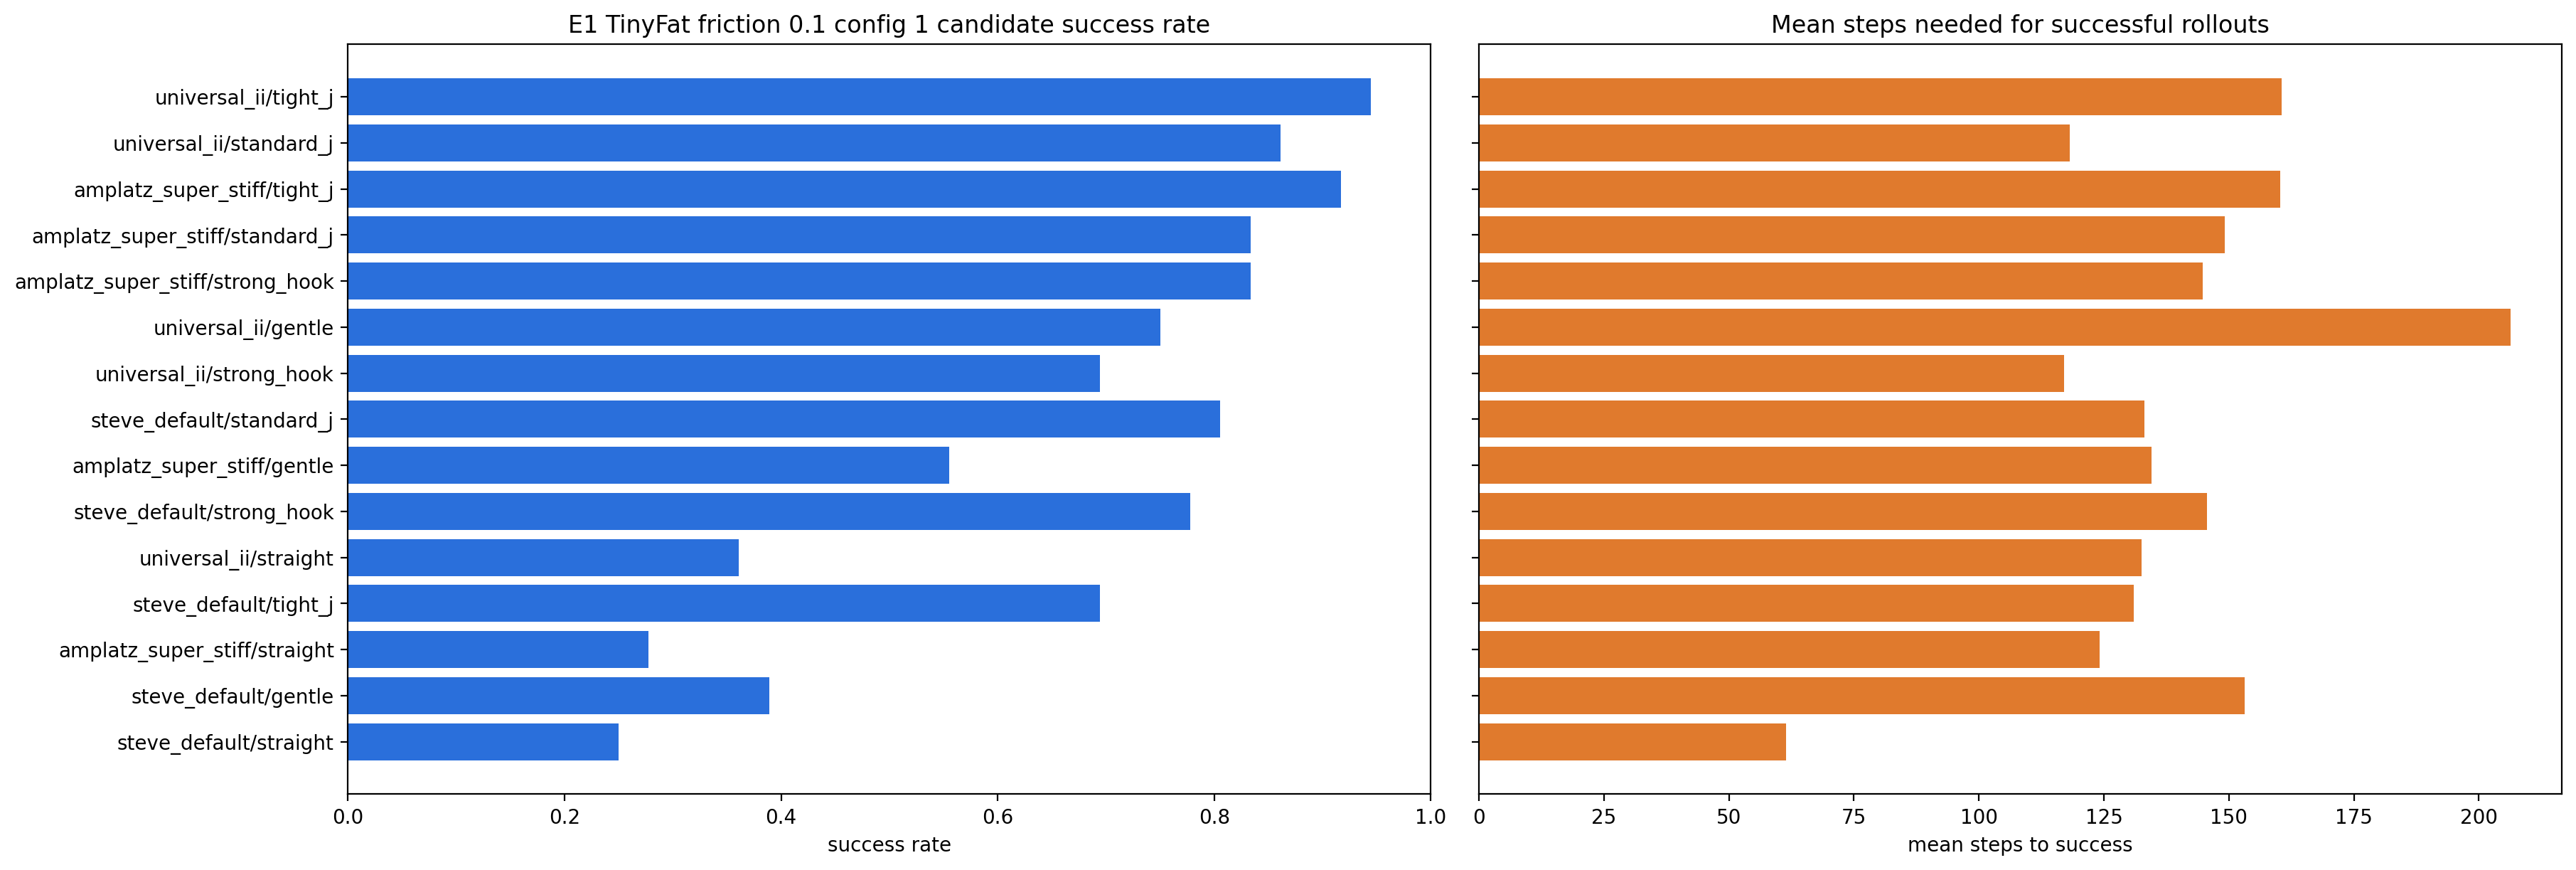

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_1_candidate_summary.png`

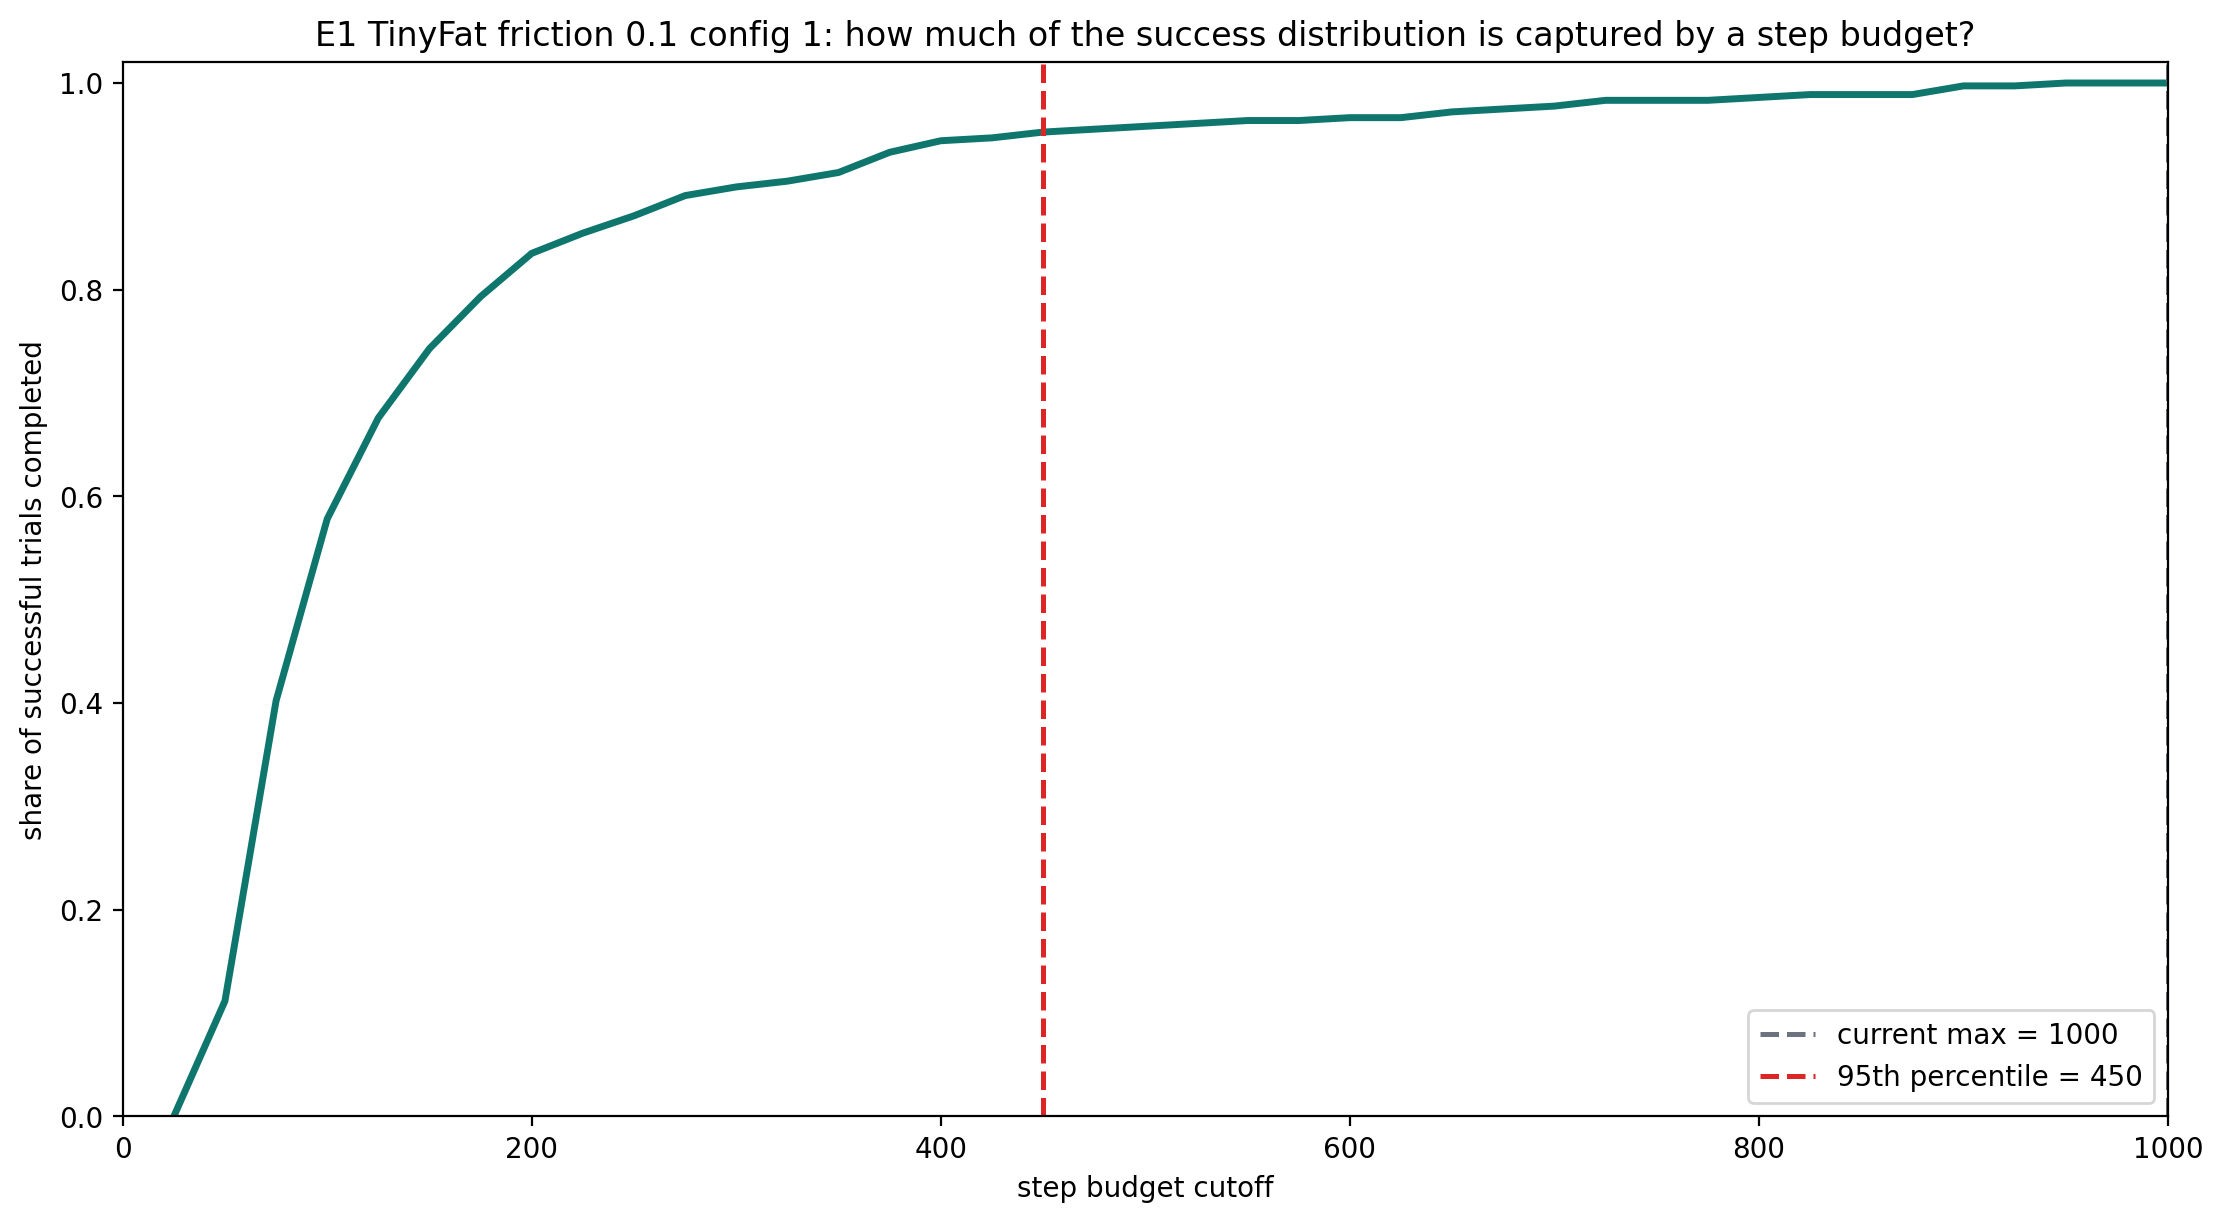

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_1_step_budget_curve.png`

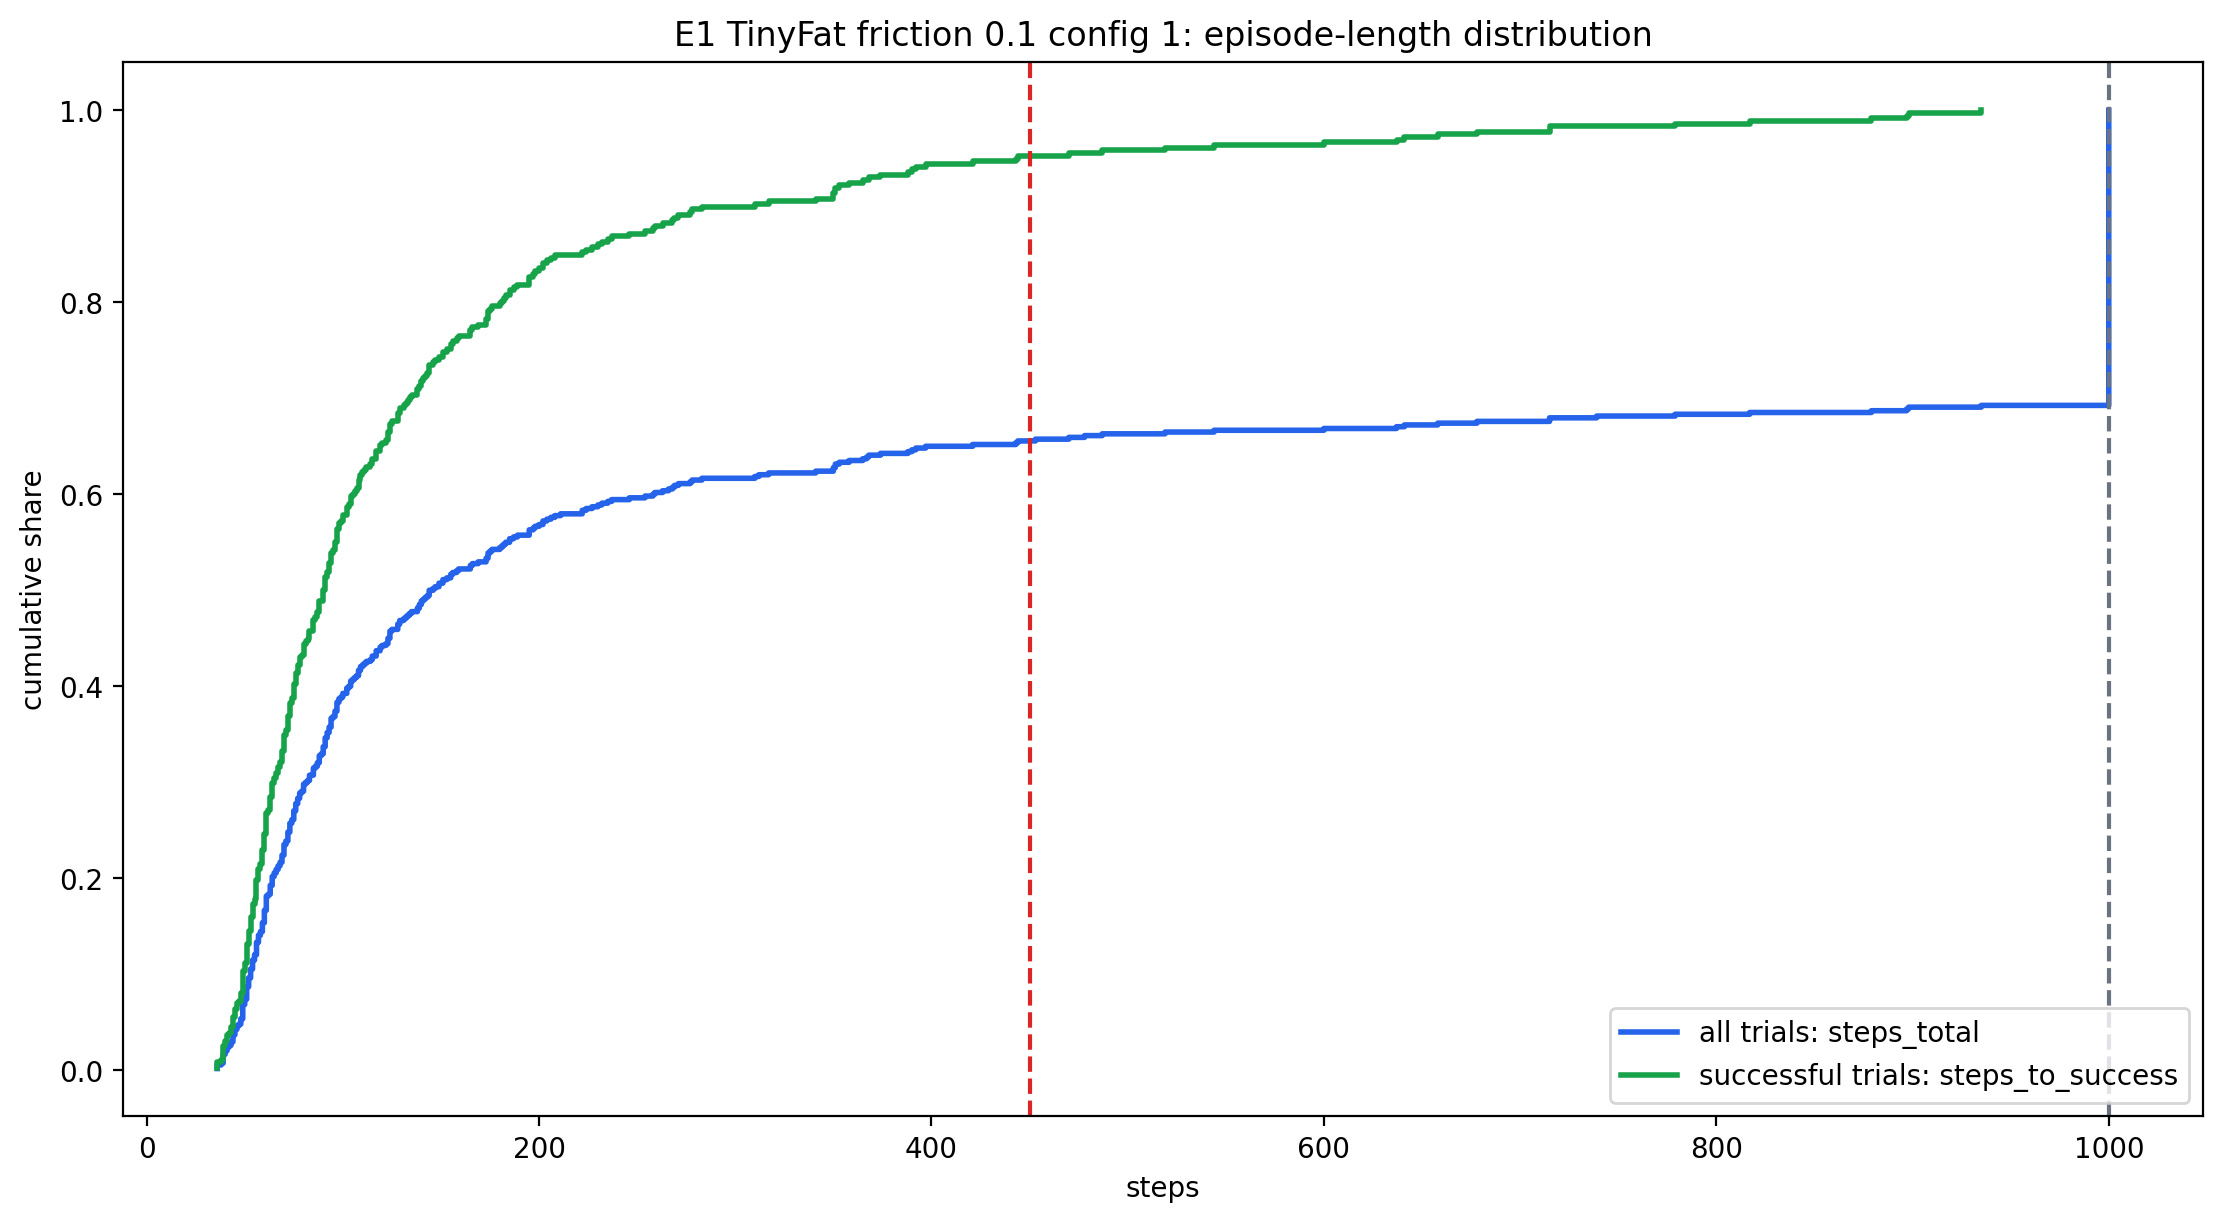

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_1_episode_length_ecdf.png`

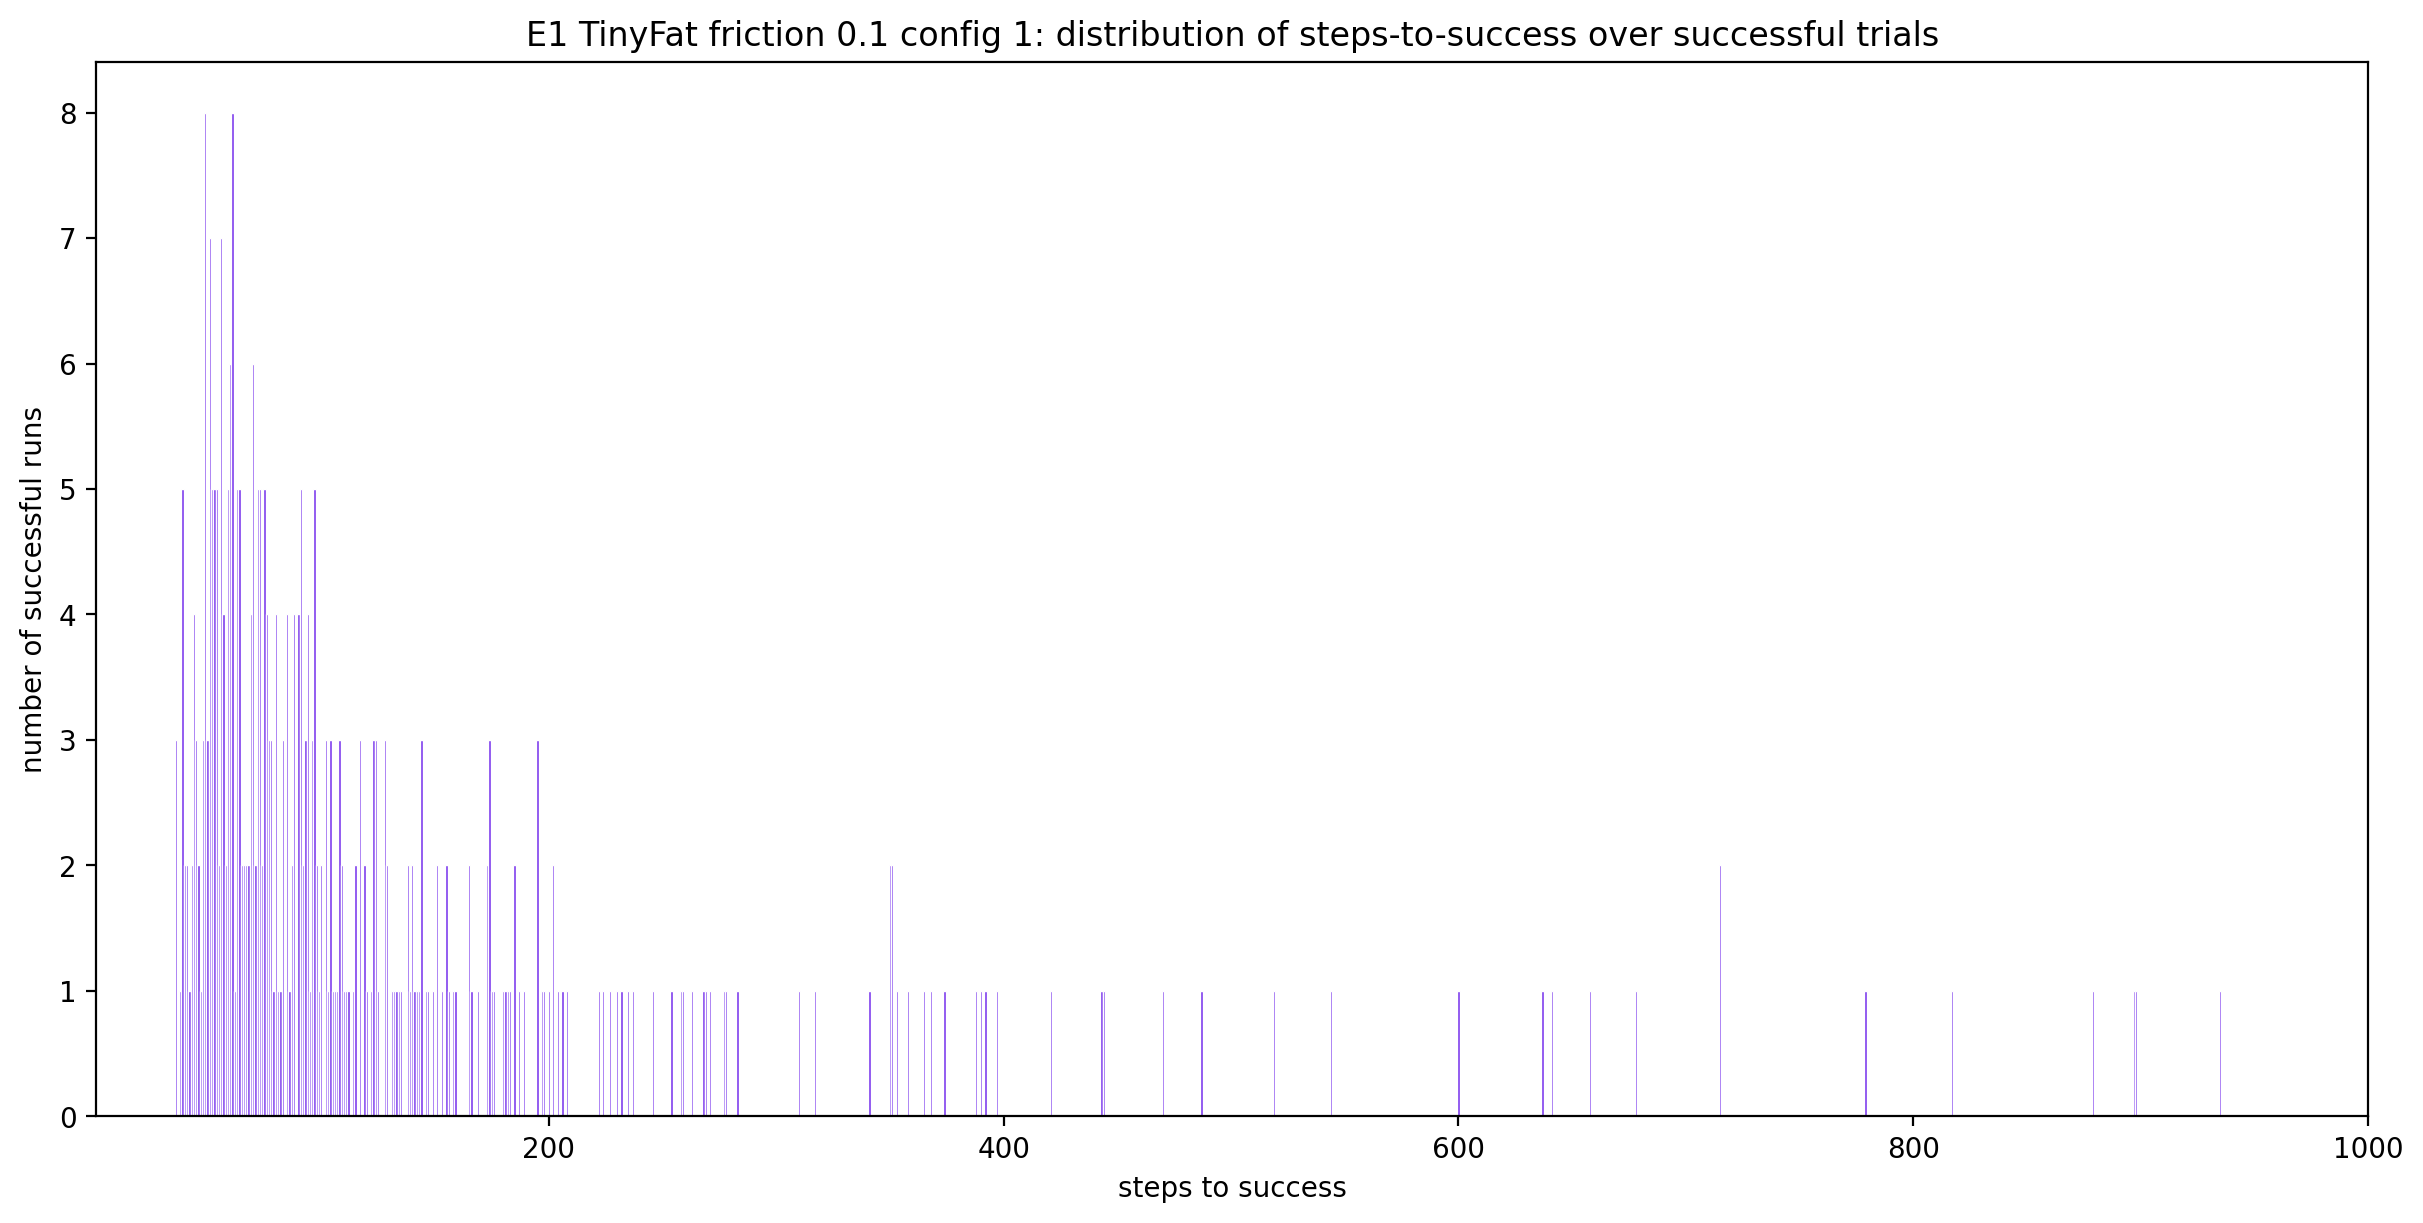

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_1_success_steps_hist.png`

### Config 2: candidate summary

,execution_wire,n_trials,success_rate,score_mean,score_std,score_safety_mean,steps_total_mean,steps_total_p95,steps_to_success_mean,steps_to_success_p95,wire_force_normal_trial_max_mean_N,tip_force_normal_trial_max_mean_N
0,universal_ii/tight_j,36000,0.908500,0.888807,0.196536,0.997851,215.432639,1000.0,144.624595,508.00,0.071118,0.028648
1,amplatz_super_stiff/standard_j,36000,0.899028,0.859002,0.211385,0.894750,226.904972,1000.0,142.548154,433.00,0.484566,0.232376
2,universal_ii/standard_j,36000,0.820889,0.838942,0.257660,0.997984,230.231278,1000.0,118.760490,293.45,0.067892,0.029397
3,amplatz_super_stiff/tight_j,36000,0.880333,0.826553,0.239551,0.845346,258.489417,1000.0,170.082576,554.00,0.603555,0.256309
4,universal_ii/gentle,36000,0.812111,0.808034,0.254455,0.995353,350.729833,1000.0,204.005439,599.00,0.090333,0.055599
5,universal_ii/strong_hook,36000,0.711472,0.757309,0.298462,0.996946,362.125194,1000.0,153.392457,410.40,0.087361,0.039687
6,amplatz_super_stiff/strong_hook,36000,0.765222,0.747695,0.302734,0.776483,313.880528,1000.0,126.717511,278.00,0.766942,0.381651
7,amplatz_super_stiff/gentle,36000,0.658194,0.657991,0.343423,0.753101,447.590583,1000.0,184.369740,633.00,0.783353,0.547206
8,steve_default/strong_hook,36000,0.812278,0.597926,0.261955,0.000000,245.702917,1000.0,120.420217,352.00,15.488406,11.027236
9,steve_default/standard_j,36000,0.784528,0.585724,0.283773,0.047090,295.995778,1000.0,137.968063,536.00,7.228317,5.574854


### Config 2: step-budget percentiles for successful trials

,quantile,steps_to_success
0,50,89.0
1,75,150.0
2,90,308.0
3,95,476.0
4,99,822.0


- config: `2`
- current max_episode_steps: `1000`
- suggested 95th-percentile cutoff: `500` steps
- successful trials analyzed: `362787`
- all readable trials analyzed: `540000`

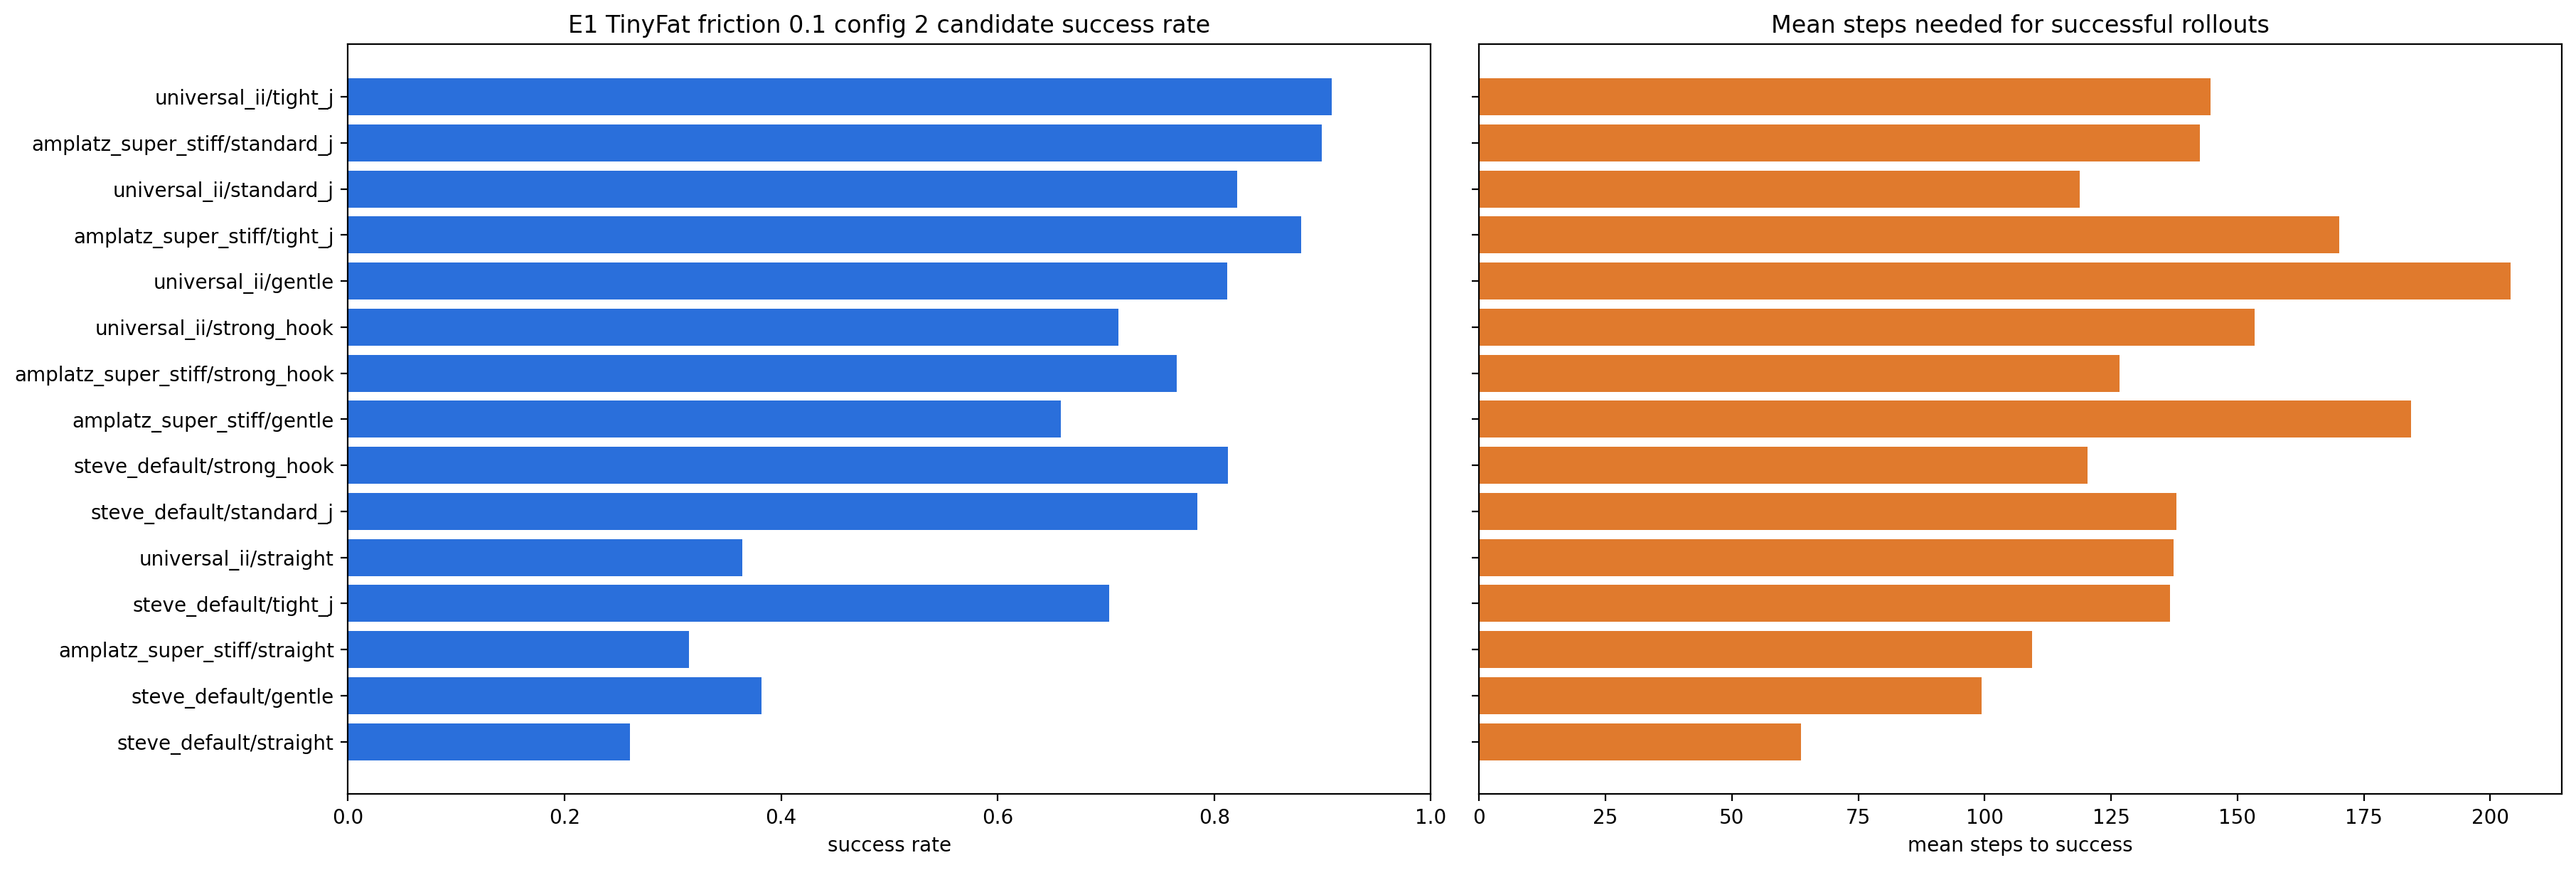

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_2_candidate_summary.png`

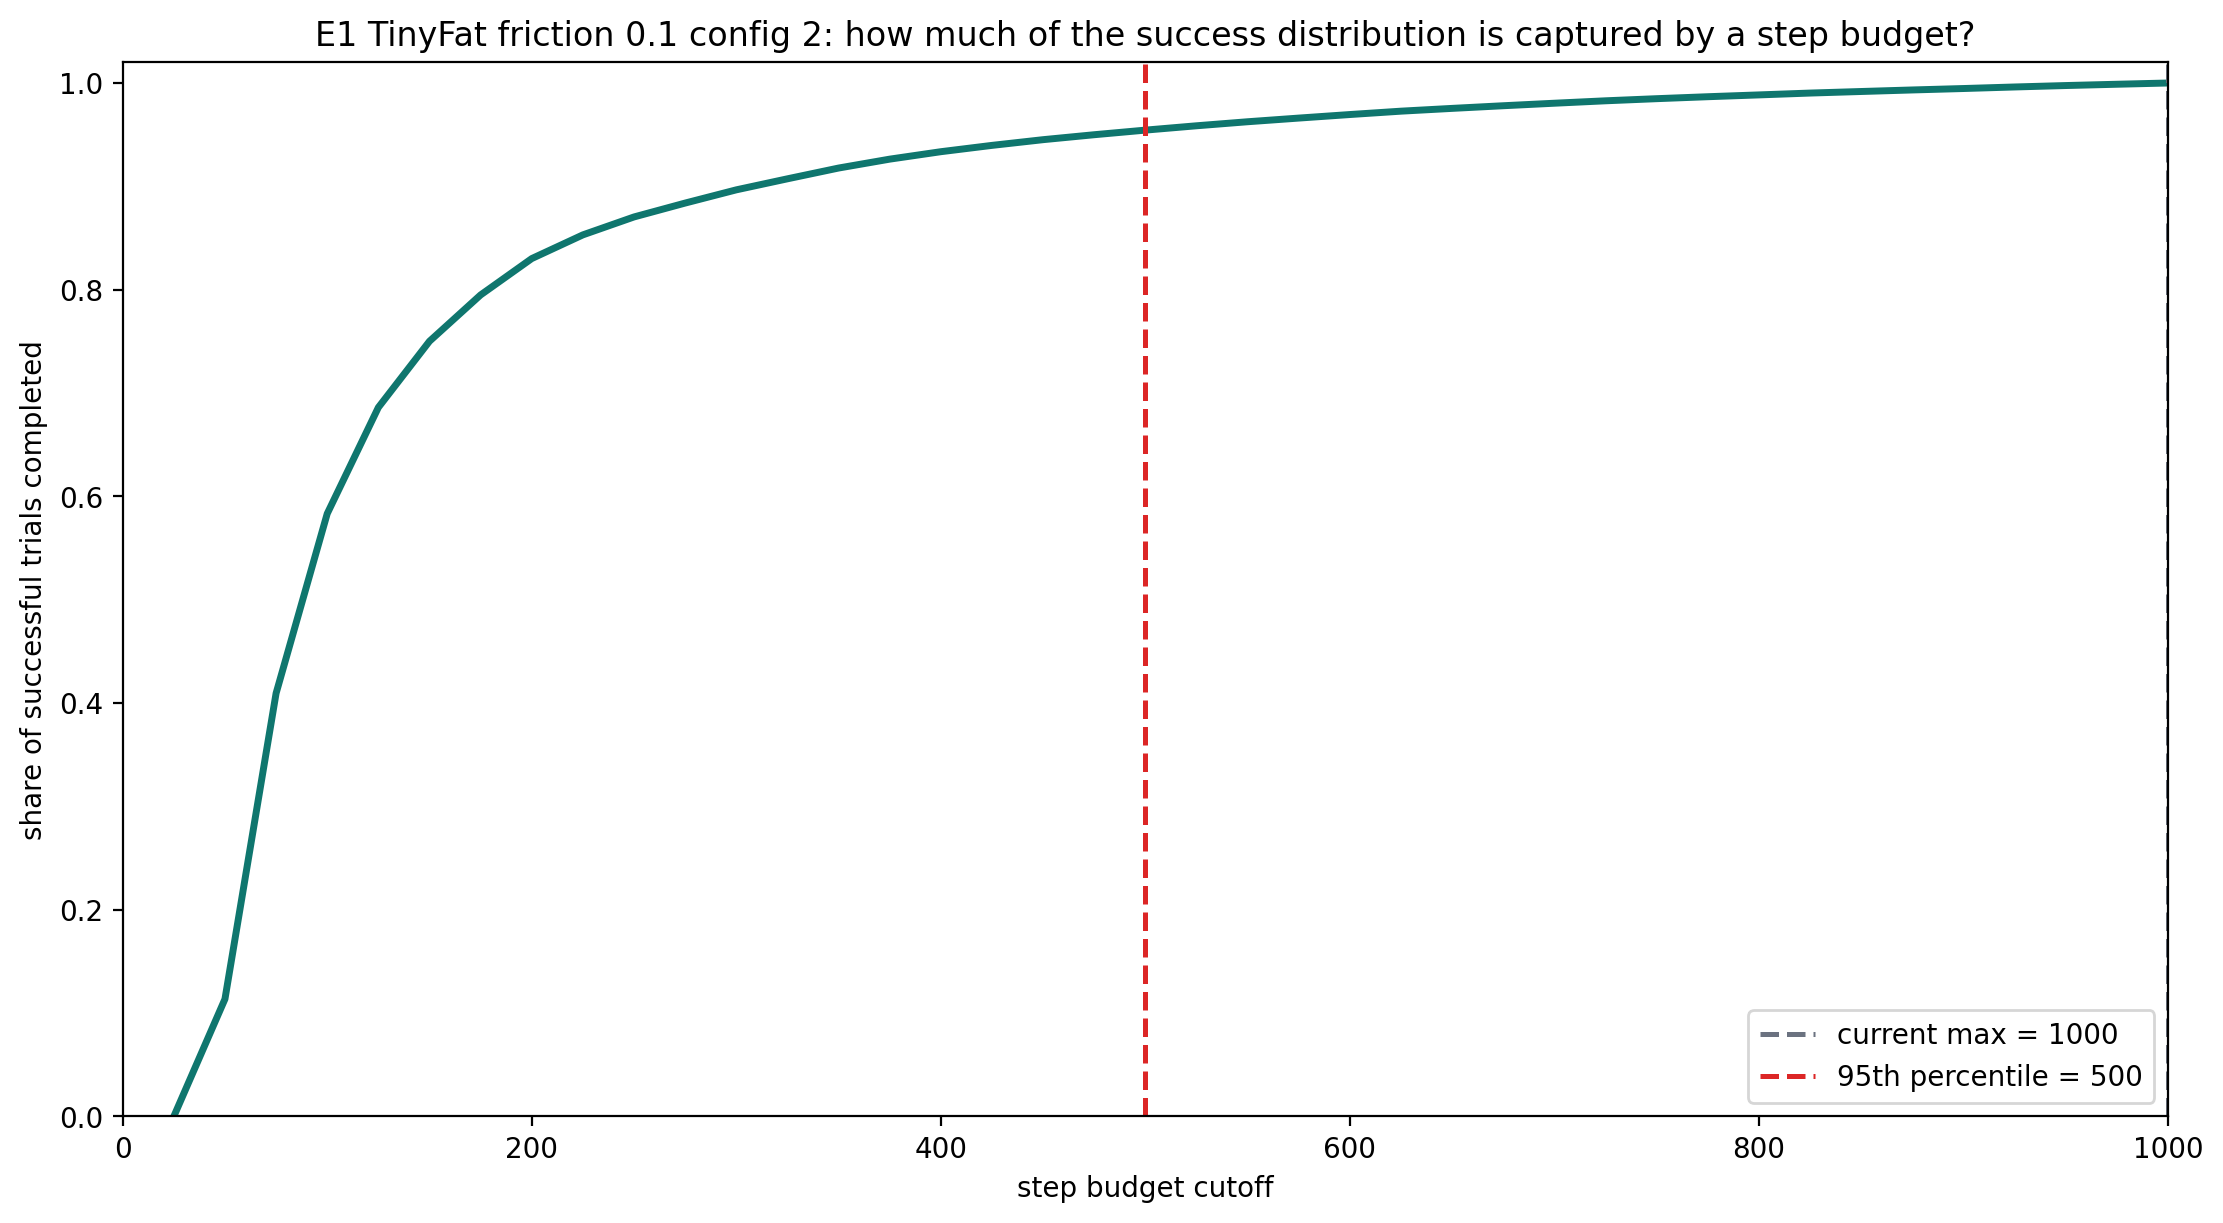

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_2_step_budget_curve.png`

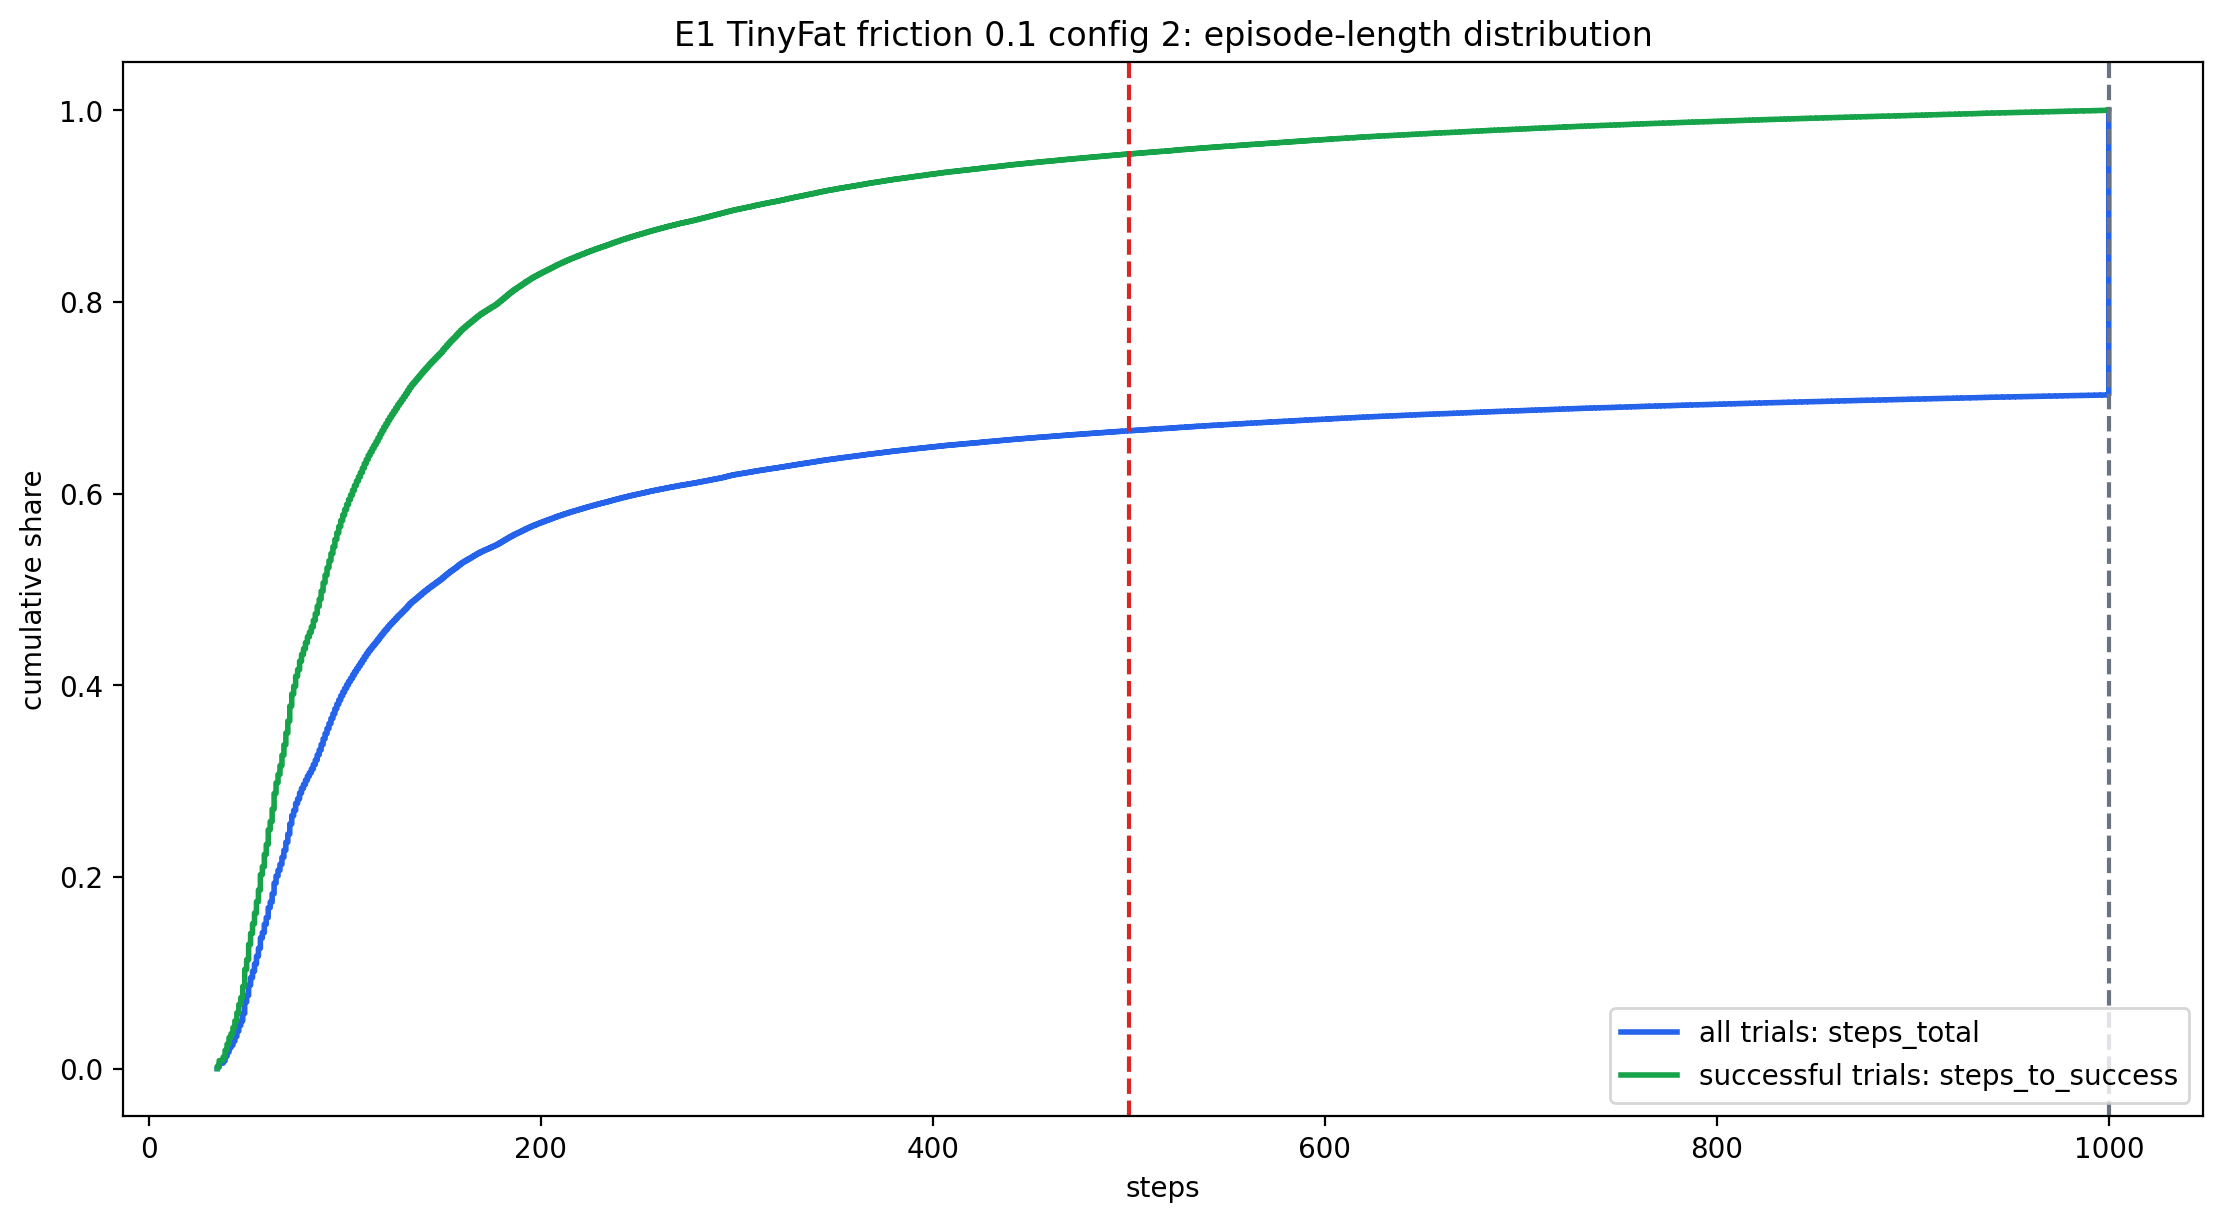

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_2_episode_length_ecdf.png`

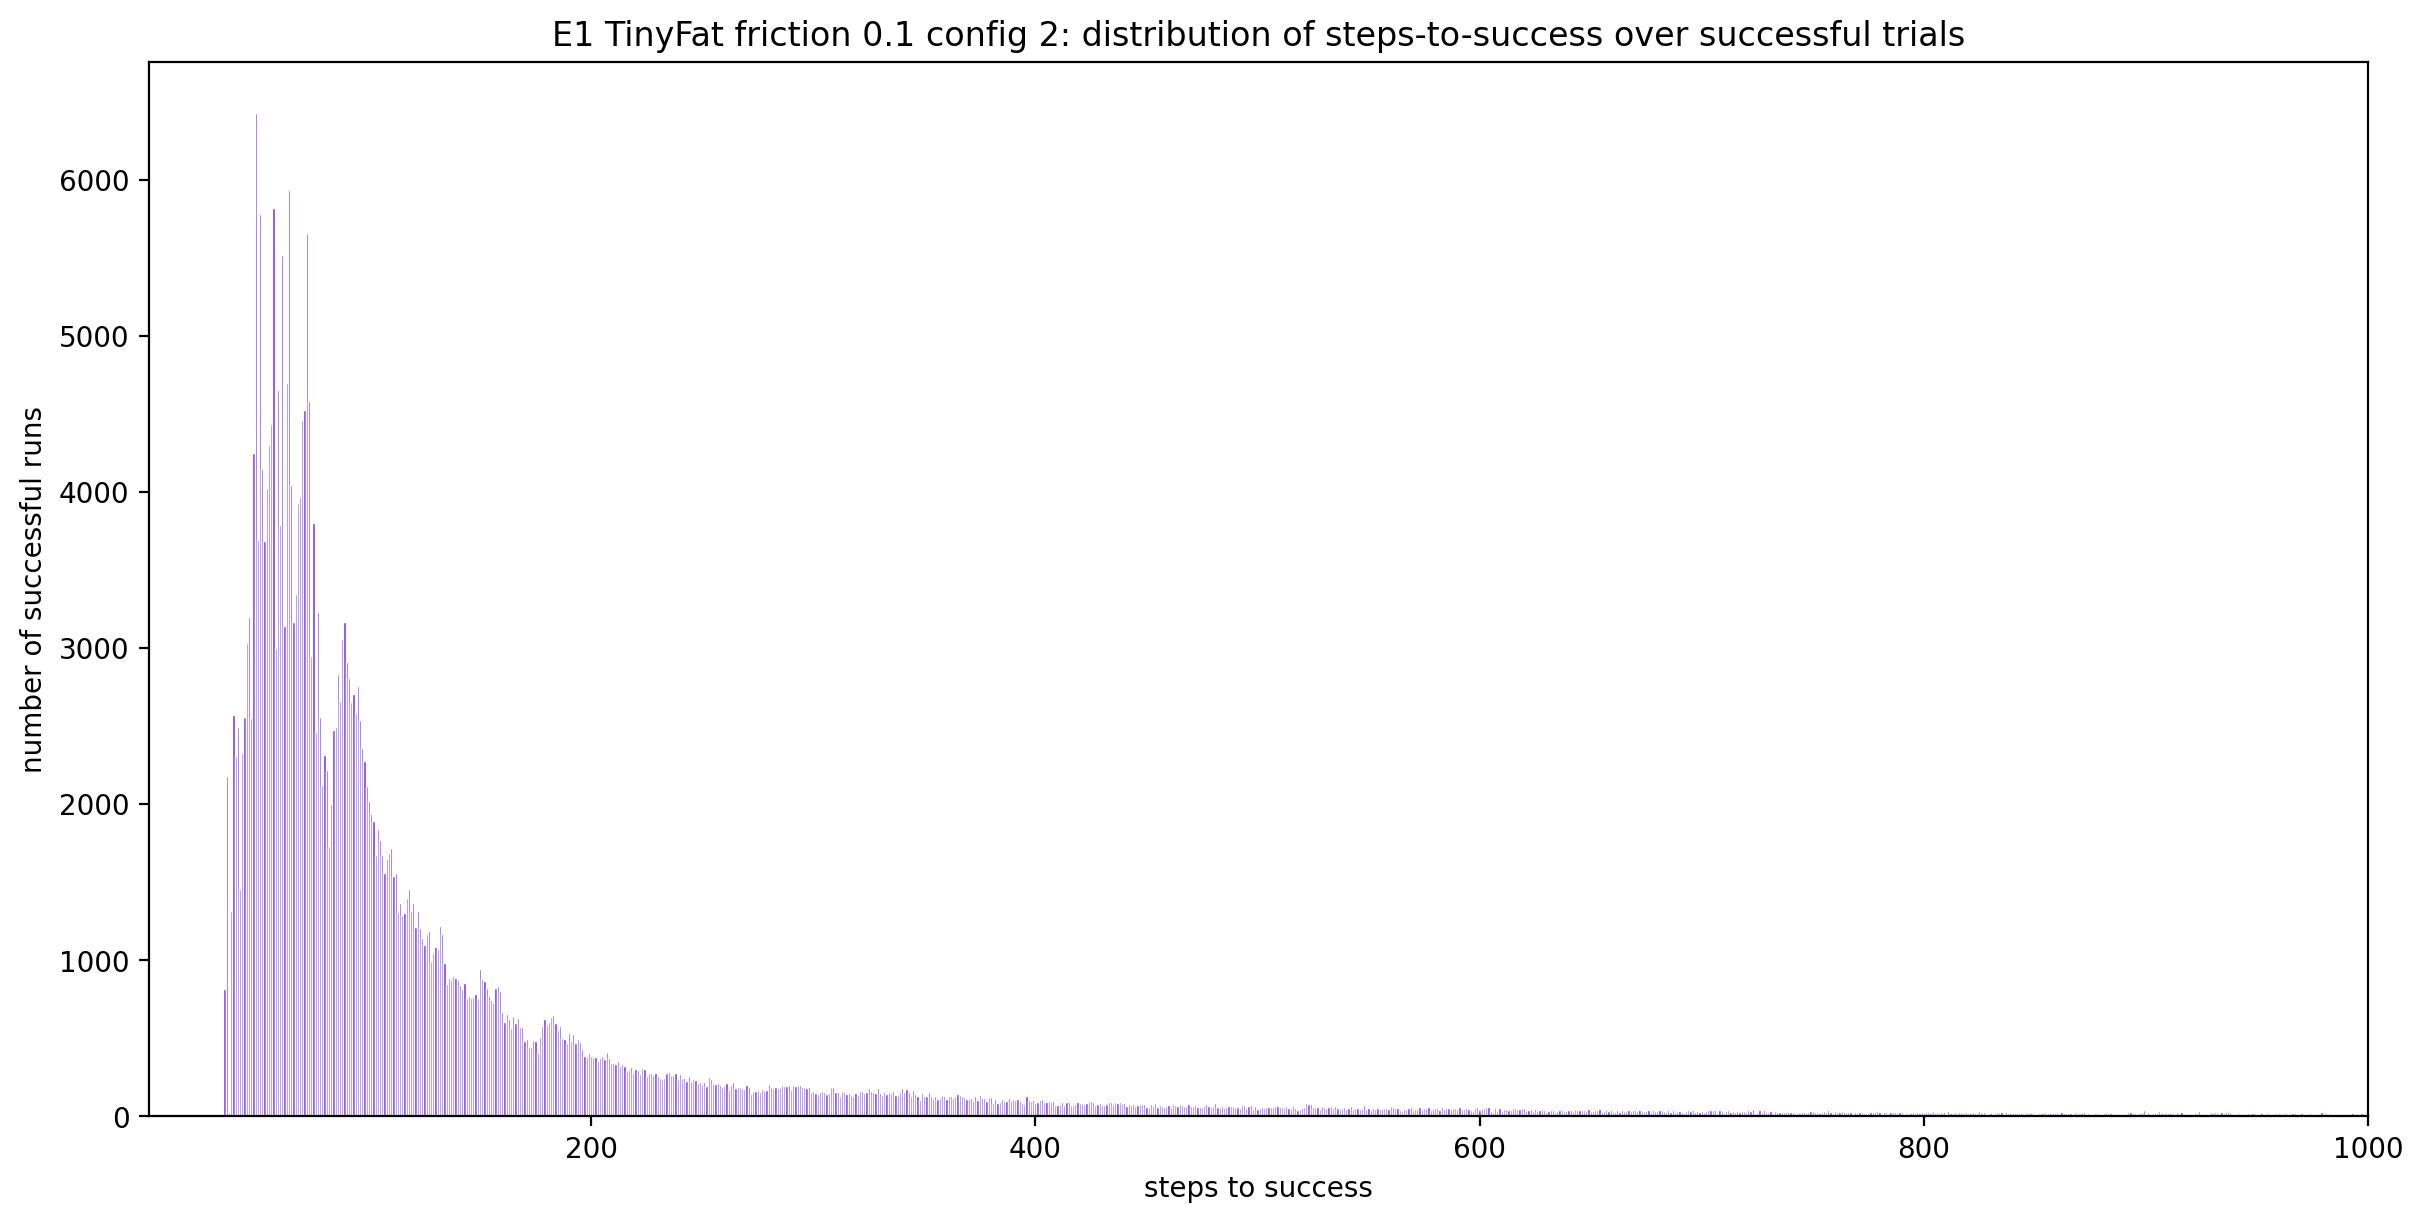

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_2_success_steps_hist.png`

### Config 3: candidate summary

,execution_wire,n_trials,success_rate,score_mean,score_std,score_safety_mean,steps_total_mean,steps_total_p95,steps_to_success_mean,steps_to_success_p95,wire_force_normal_trial_max_mean_N,tip_force_normal_trial_max_mean_N
0,amplatz_super_stiff/standard_j,36000,0.966417,0.906622,0.140395,0.876343,145.661861,426.0,119.843724,298.00,0.524380,0.229137
1,universal_ii/tight_j,36000,0.911583,0.890964,0.192315,0.997341,196.281028,1000.0,143.827772,441.00,0.079132,0.028601
2,universal_ii/standard_j,36000,0.884222,0.878397,0.215763,0.997496,207.825028,1000.0,126.766713,348.00,0.074007,0.028980
3,amplatz_super_stiff/tight_j,36000,0.903250,0.836703,0.222793,0.834239,247.158833,1000.0,176.486669,694.20,0.627688,0.236705
4,universal_ii/strong_hook,36000,0.780444,0.799864,0.273356,0.996175,320.989472,1000.0,161.506193,487.00,0.096893,0.042293
5,universal_ii/gentle,36000,0.770361,0.786753,0.275490,0.996569,371.713139,1000.0,185.966214,599.00,0.083003,0.045777
6,amplatz_super_stiff/strong_hook,36000,0.826389,0.783238,0.283216,0.755843,262.697083,1000.0,126.922487,273.00,0.792386,0.341806
7,steve_default/standard_j,36000,0.931639,0.694007,0.179517,0.050105,154.600583,1000.0,105.006351,247.00,8.751746,5.512897
8,amplatz_super_stiff/gentle,36000,0.678944,0.662365,0.335988,0.753614,464.552972,1000.0,222.100319,762.95,0.776007,0.507284
9,steve_default/tight_j,36000,0.830556,0.611283,0.252500,0.000005,241.520139,1000.0,116.242843,321.00,10.179674,6.124827


### Config 3: step-budget percentiles for successful trials

,quantile,steps_to_success
0,50,86.0
1,75,142.0
2,90,283.0
3,95,455.0
4,99,831.0


- config: `3`
- current max_episode_steps: `1000`
- suggested 95th-percentile cutoff: `475` steps
- successful trials analyzed: `386370`
- all readable trials analyzed: `540000`

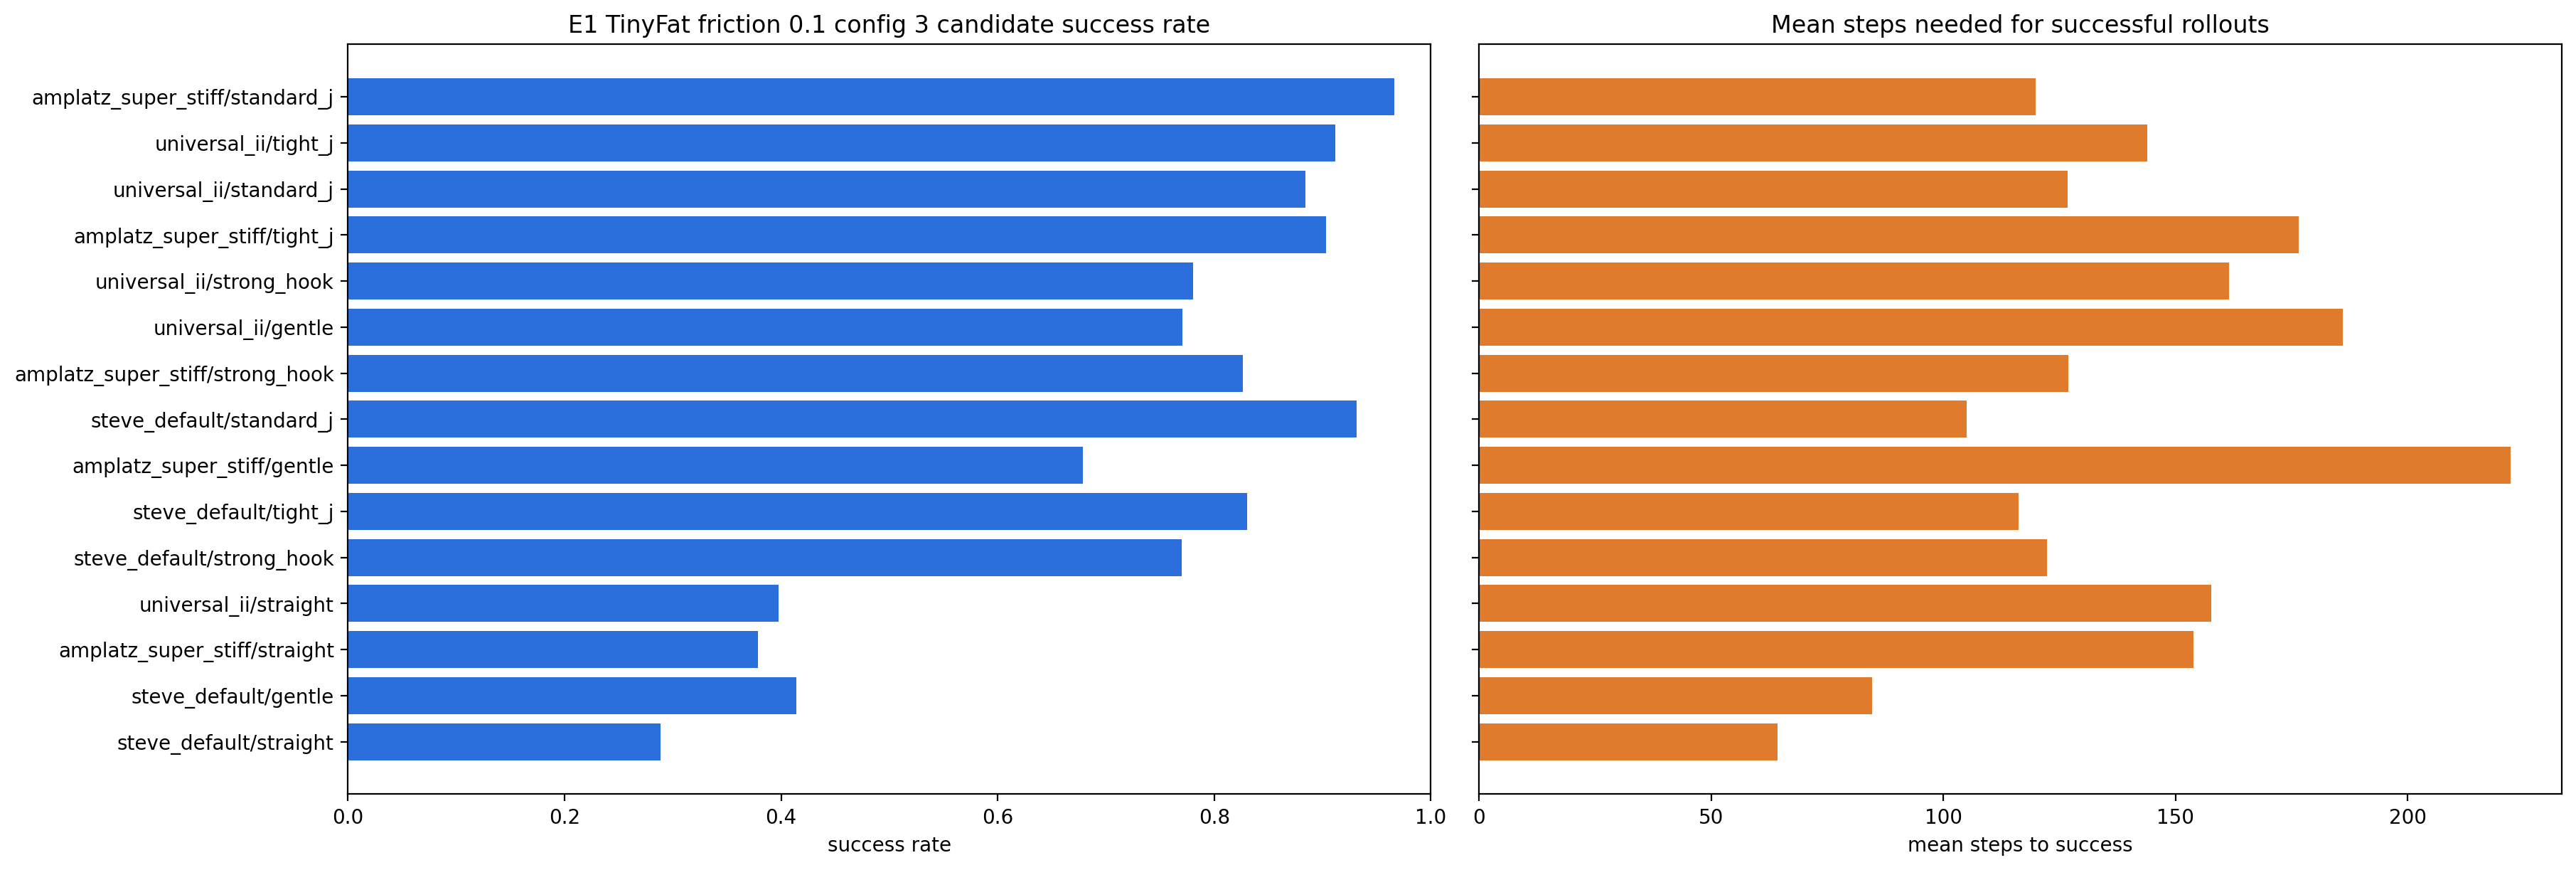

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_3_candidate_summary.png`

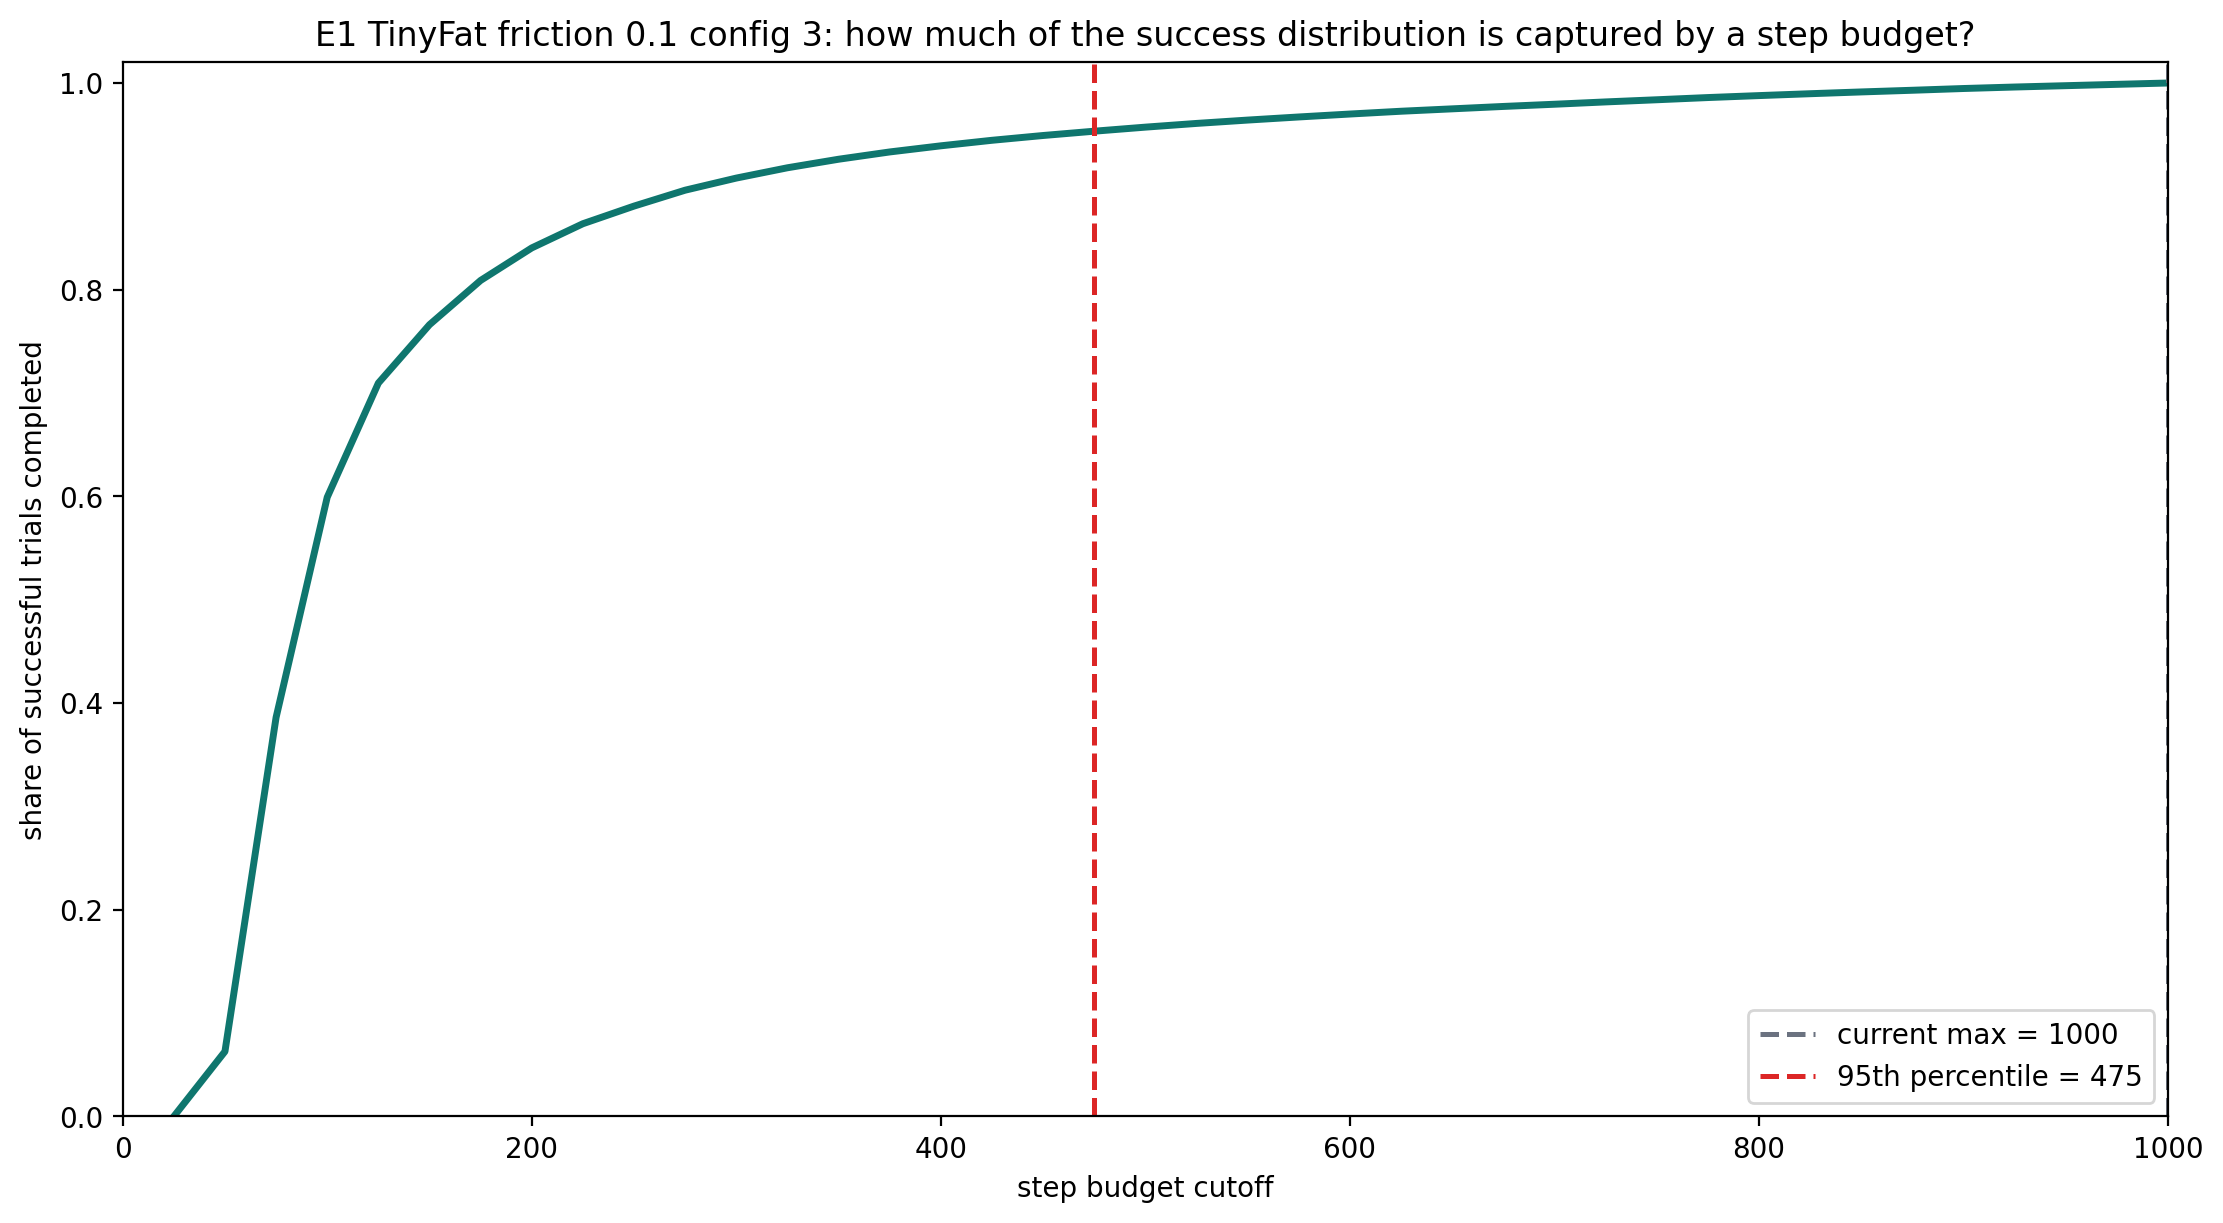

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_3_step_budget_curve.png`

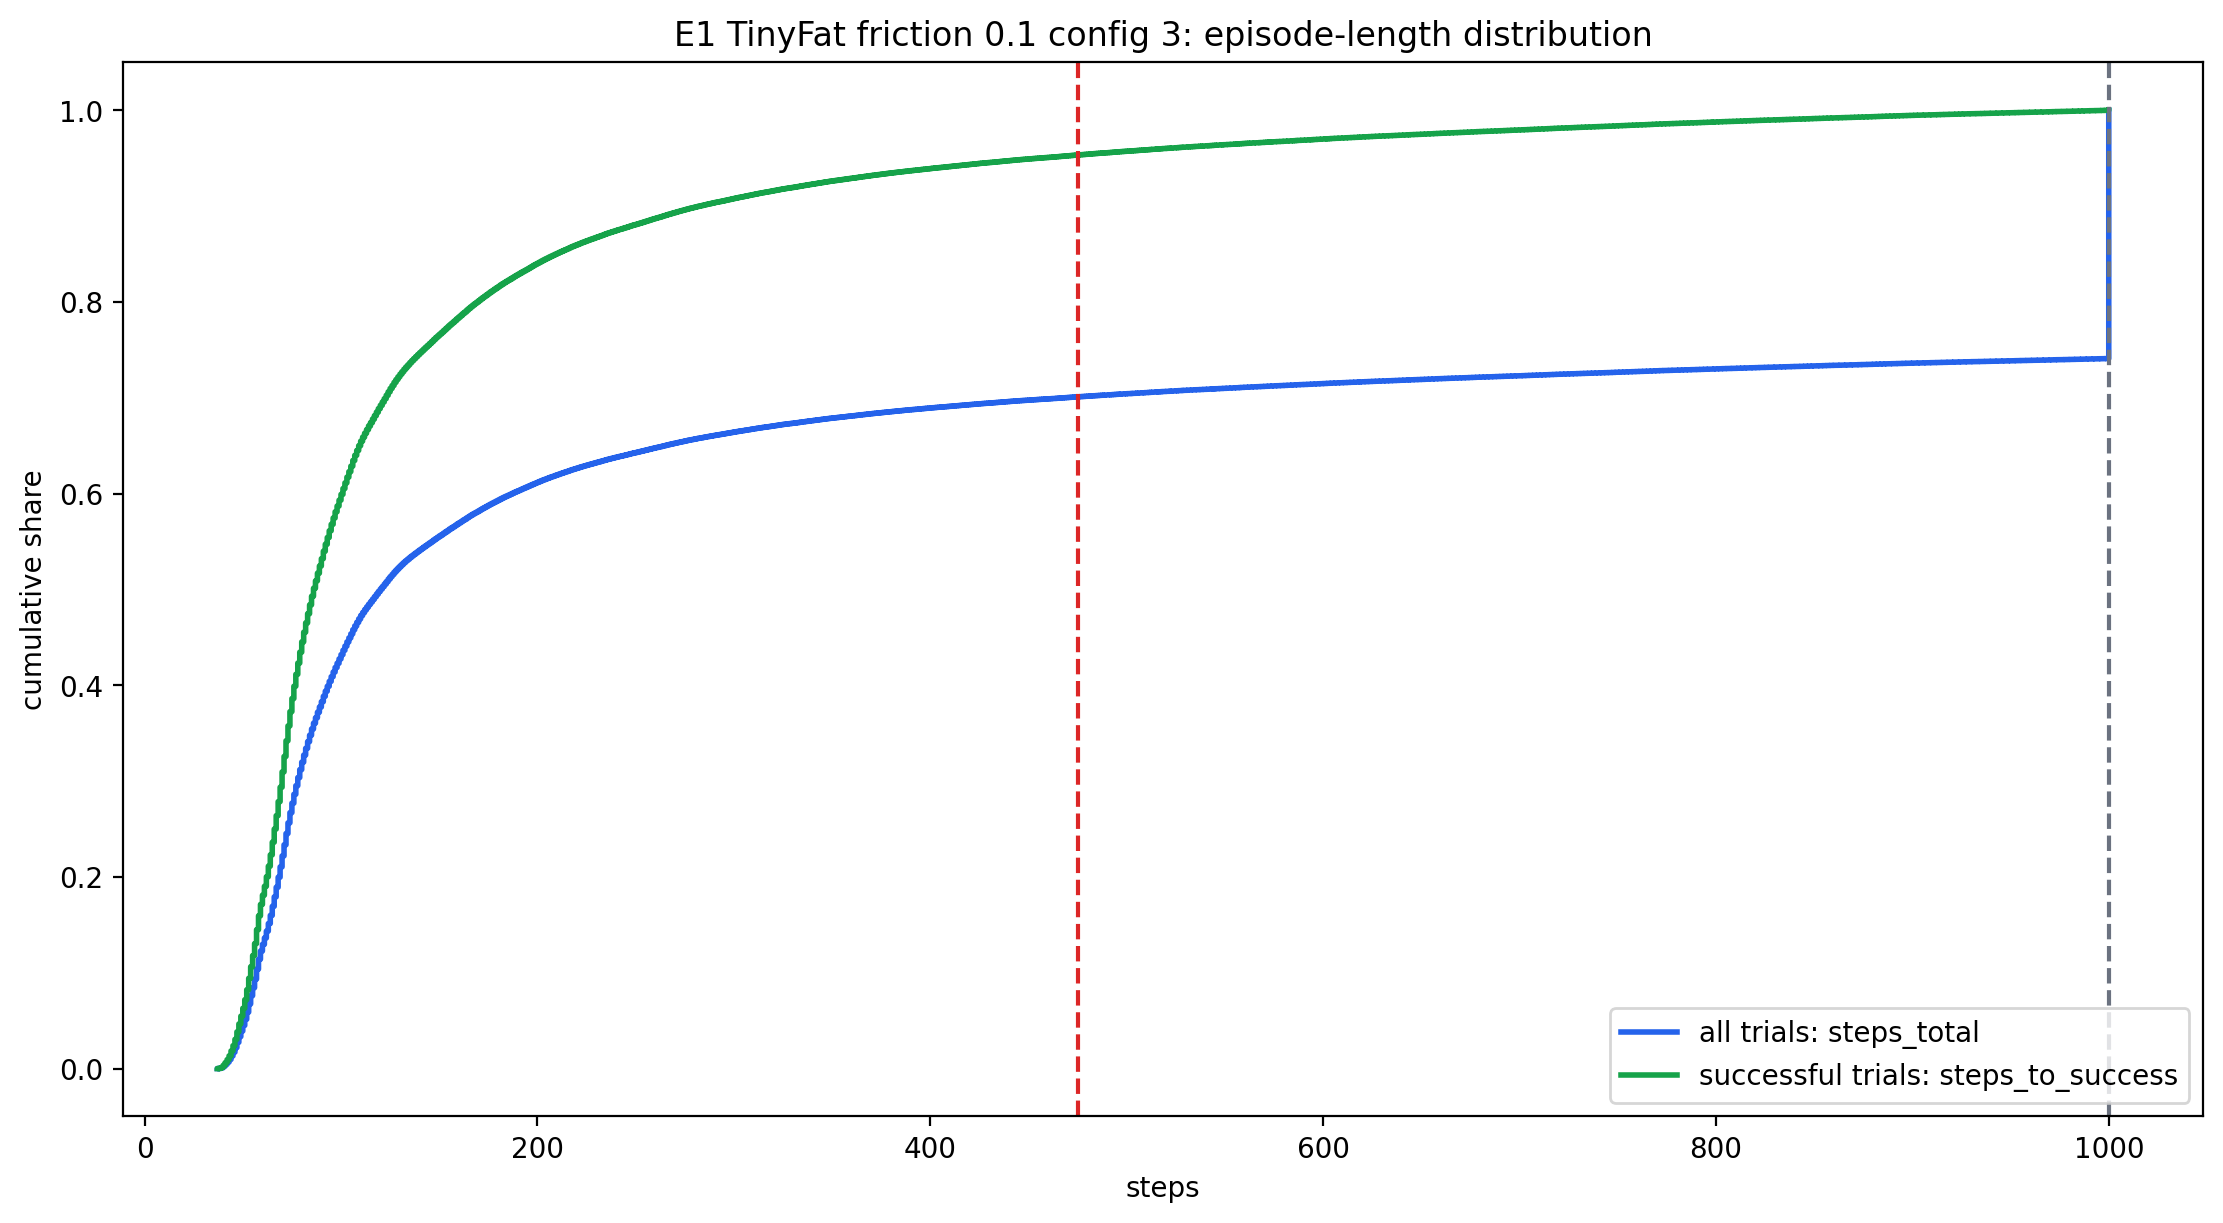

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_3_episode_length_ecdf.png`

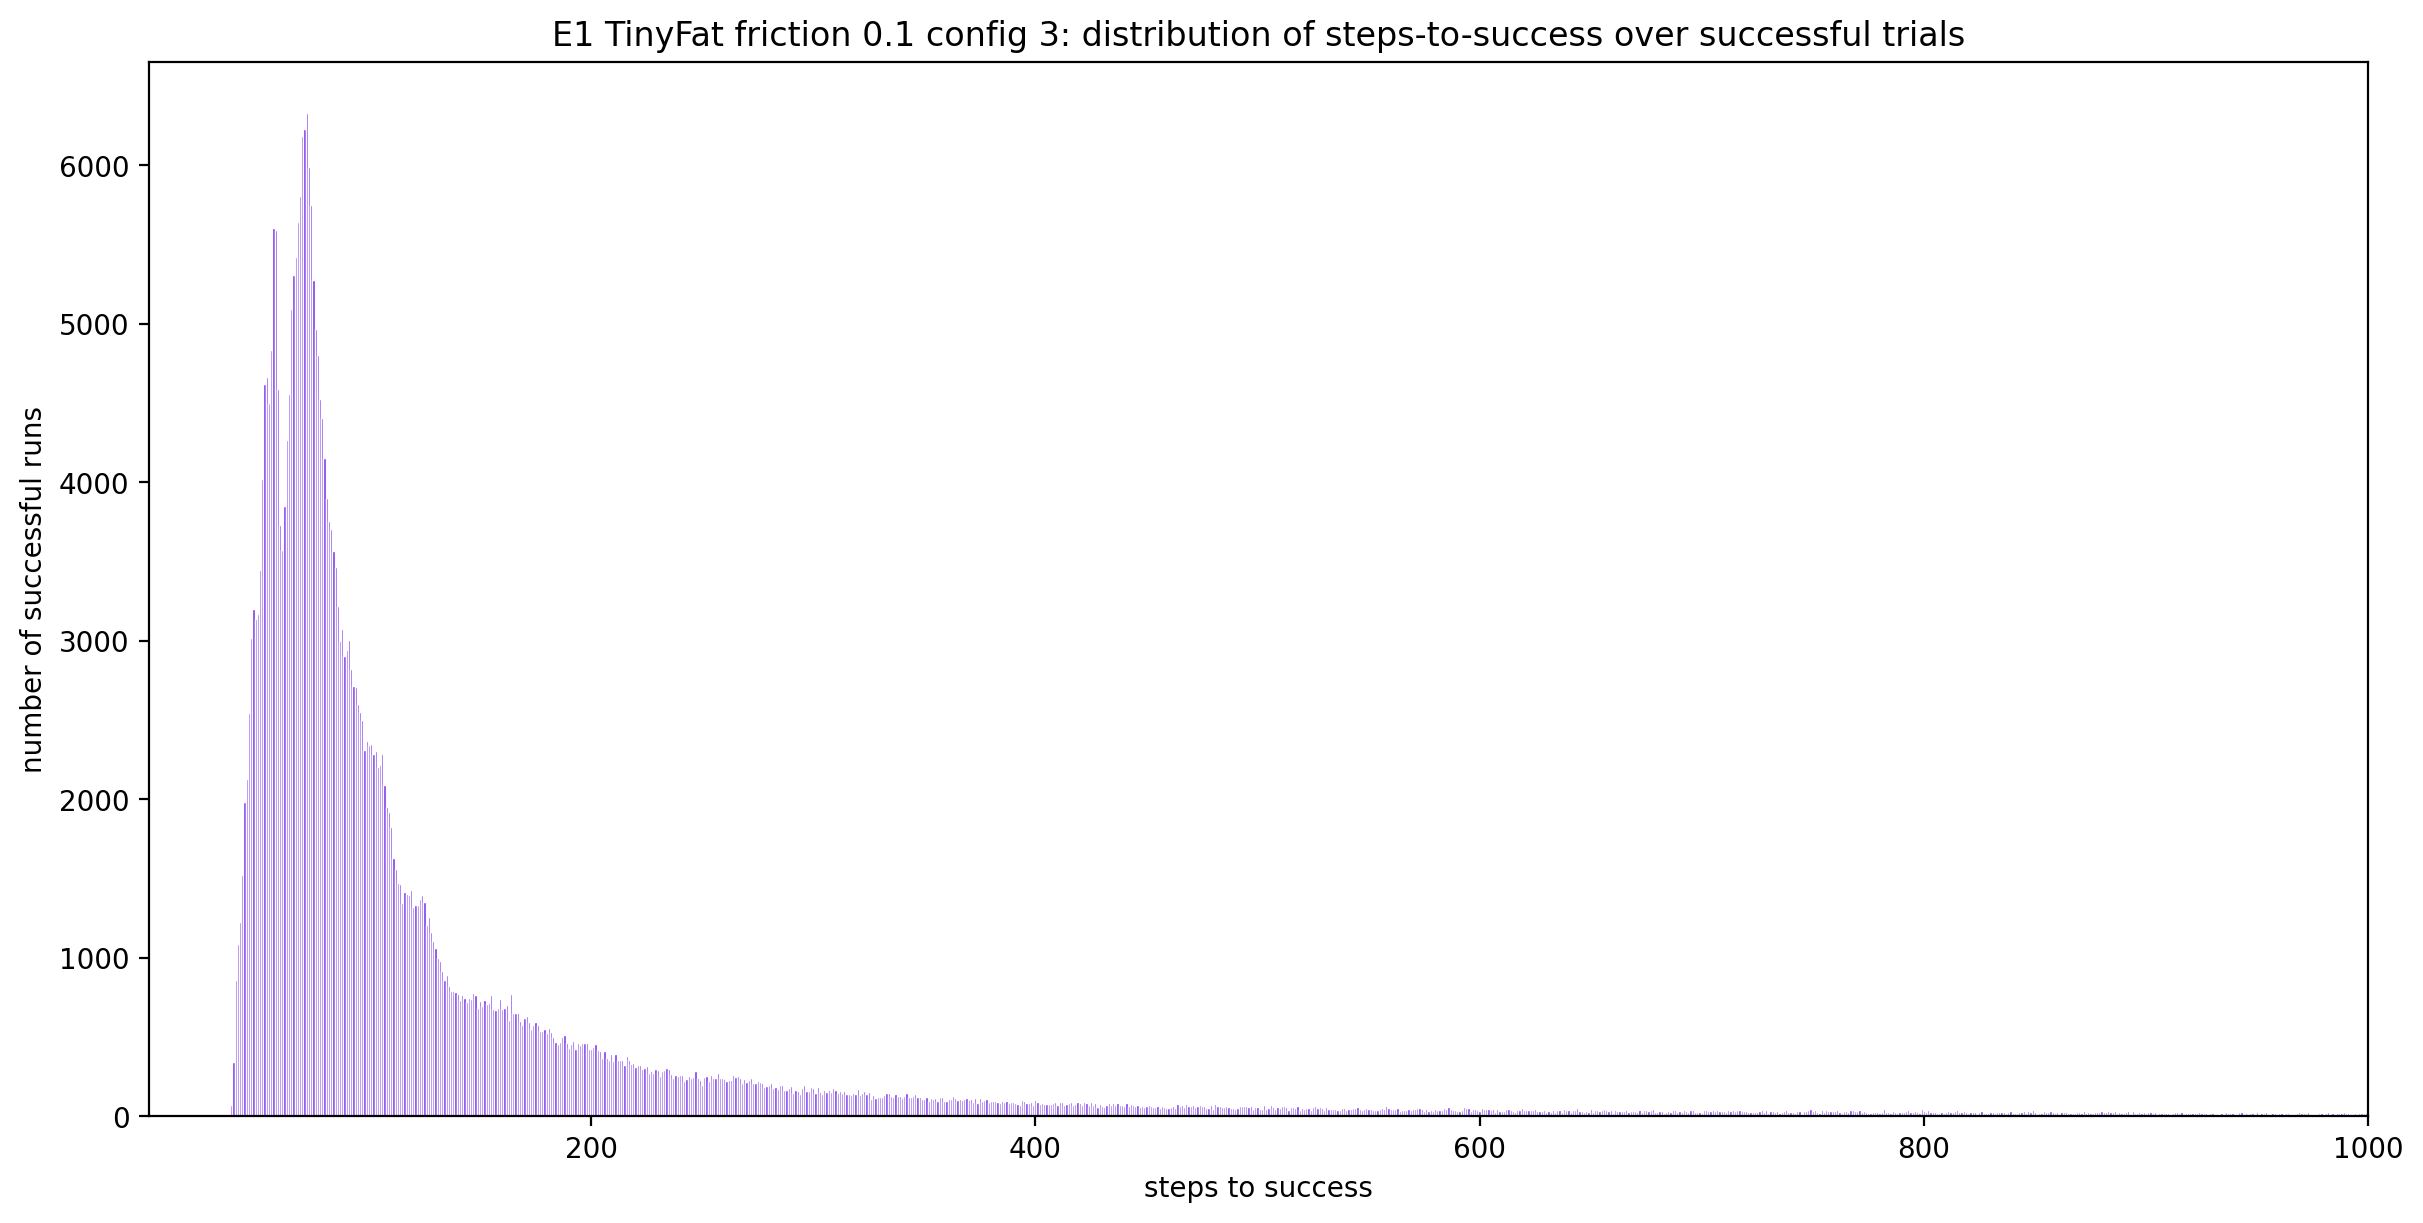

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_3_success_steps_hist.png`

### Config 4: candidate summary

,execution_wire,n_trials,success_rate,score_mean,score_std,score_safety_mean,steps_total_mean,steps_total_p95,steps_to_success_mean,steps_to_success_p95,wire_force_normal_trial_max_mean_N,tip_force_normal_trial_max_mean_N
0,amplatz_super_stiff/standard_j,36000,0.965056,0.905304,0.142627,0.875106,147.769889,450.0,120.203730,299.00,0.525608,0.226637
1,universal_ii/tight_j,36000,0.913389,0.892563,0.190672,0.997351,192.793861,1000.0,142.546712,445.00,0.079240,0.028695
2,universal_ii/standard_j,36000,0.884861,0.878386,0.215208,0.997471,208.710917,1000.0,128.135709,355.00,0.074409,0.029358
3,amplatz_super_stiff/tight_j,36000,0.906667,0.839740,0.220428,0.836517,244.071278,1000.0,175.547028,692.00,0.622626,0.235264
4,universal_ii/strong_hook,36000,0.780333,0.801407,0.274008,0.996165,315.732222,1000.0,155.640004,468.00,0.096866,0.042499
5,amplatz_super_stiff/strong_hook,36000,0.827333,0.784544,0.281816,0.758719,261.809889,1000.0,126.907769,272.00,0.786575,0.339899
6,universal_ii/gentle,36000,0.755639,0.777439,0.281036,0.996664,383.476833,1000.0,185.615520,597.90,0.082144,0.045696
7,steve_default/standard_j,36000,0.932167,0.694117,0.178462,0.047420,153.433694,1000.0,103.827284,243.00,8.796583,5.538416
8,amplatz_super_stiff/gentle,36000,0.675111,0.660994,0.338133,0.753876,464.646250,1000.0,218.014195,752.85,0.772507,0.505113
9,steve_default/tight_j,36000,0.835917,0.614800,0.249538,0.000007,237.962778,1000.0,116.411790,330.40,10.231900,6.078203


### Config 4: step-budget percentiles for successful trials

,quantile,steps_to_success
0,50,86.0
1,75,140.0
2,90,280.0
3,95,453.0
4,99,828.0


- config: `4`
- current max_episode_steps: `1000`
- suggested 95th-percentile cutoff: `475` steps
- successful trials analyzed: `385897`
- all readable trials analyzed: `540000`

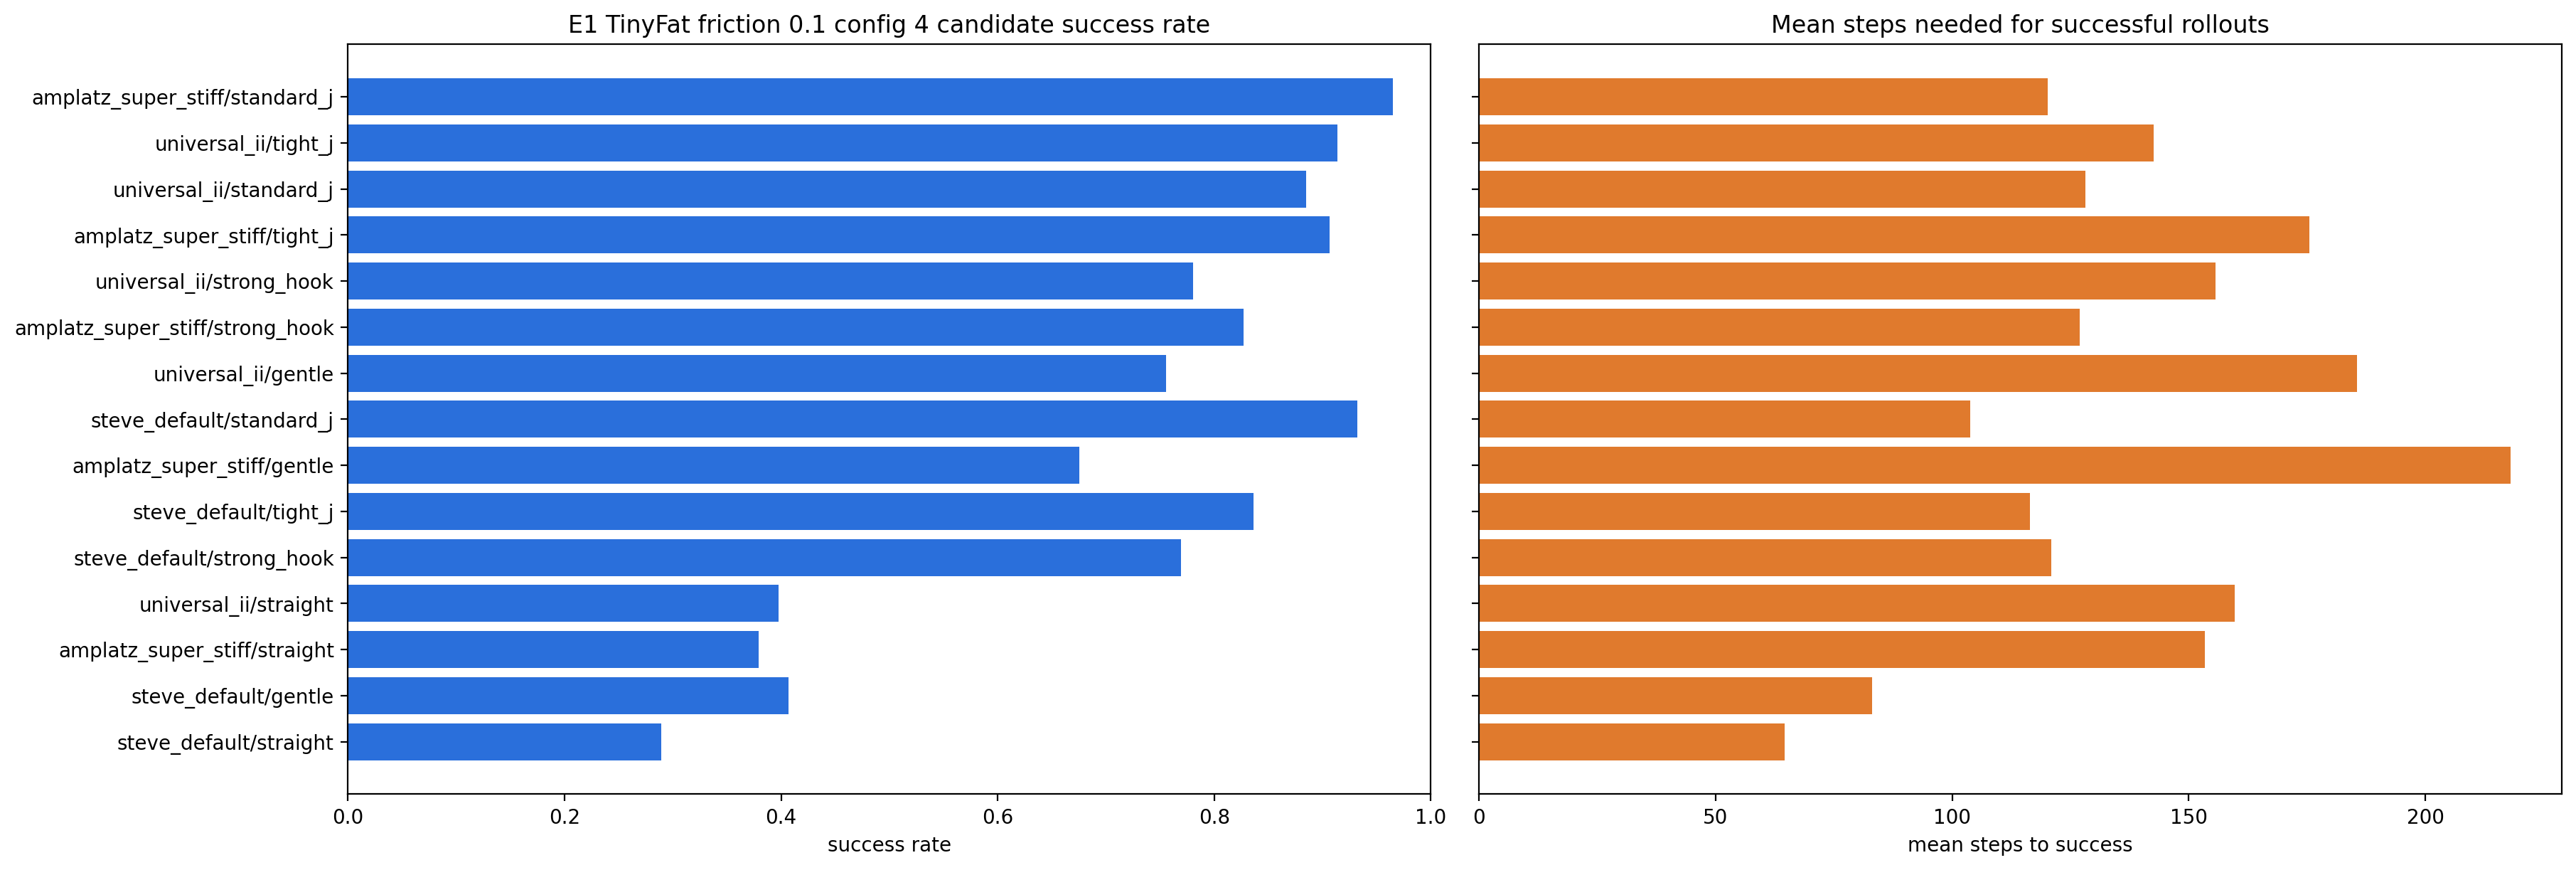

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_4_candidate_summary.png`

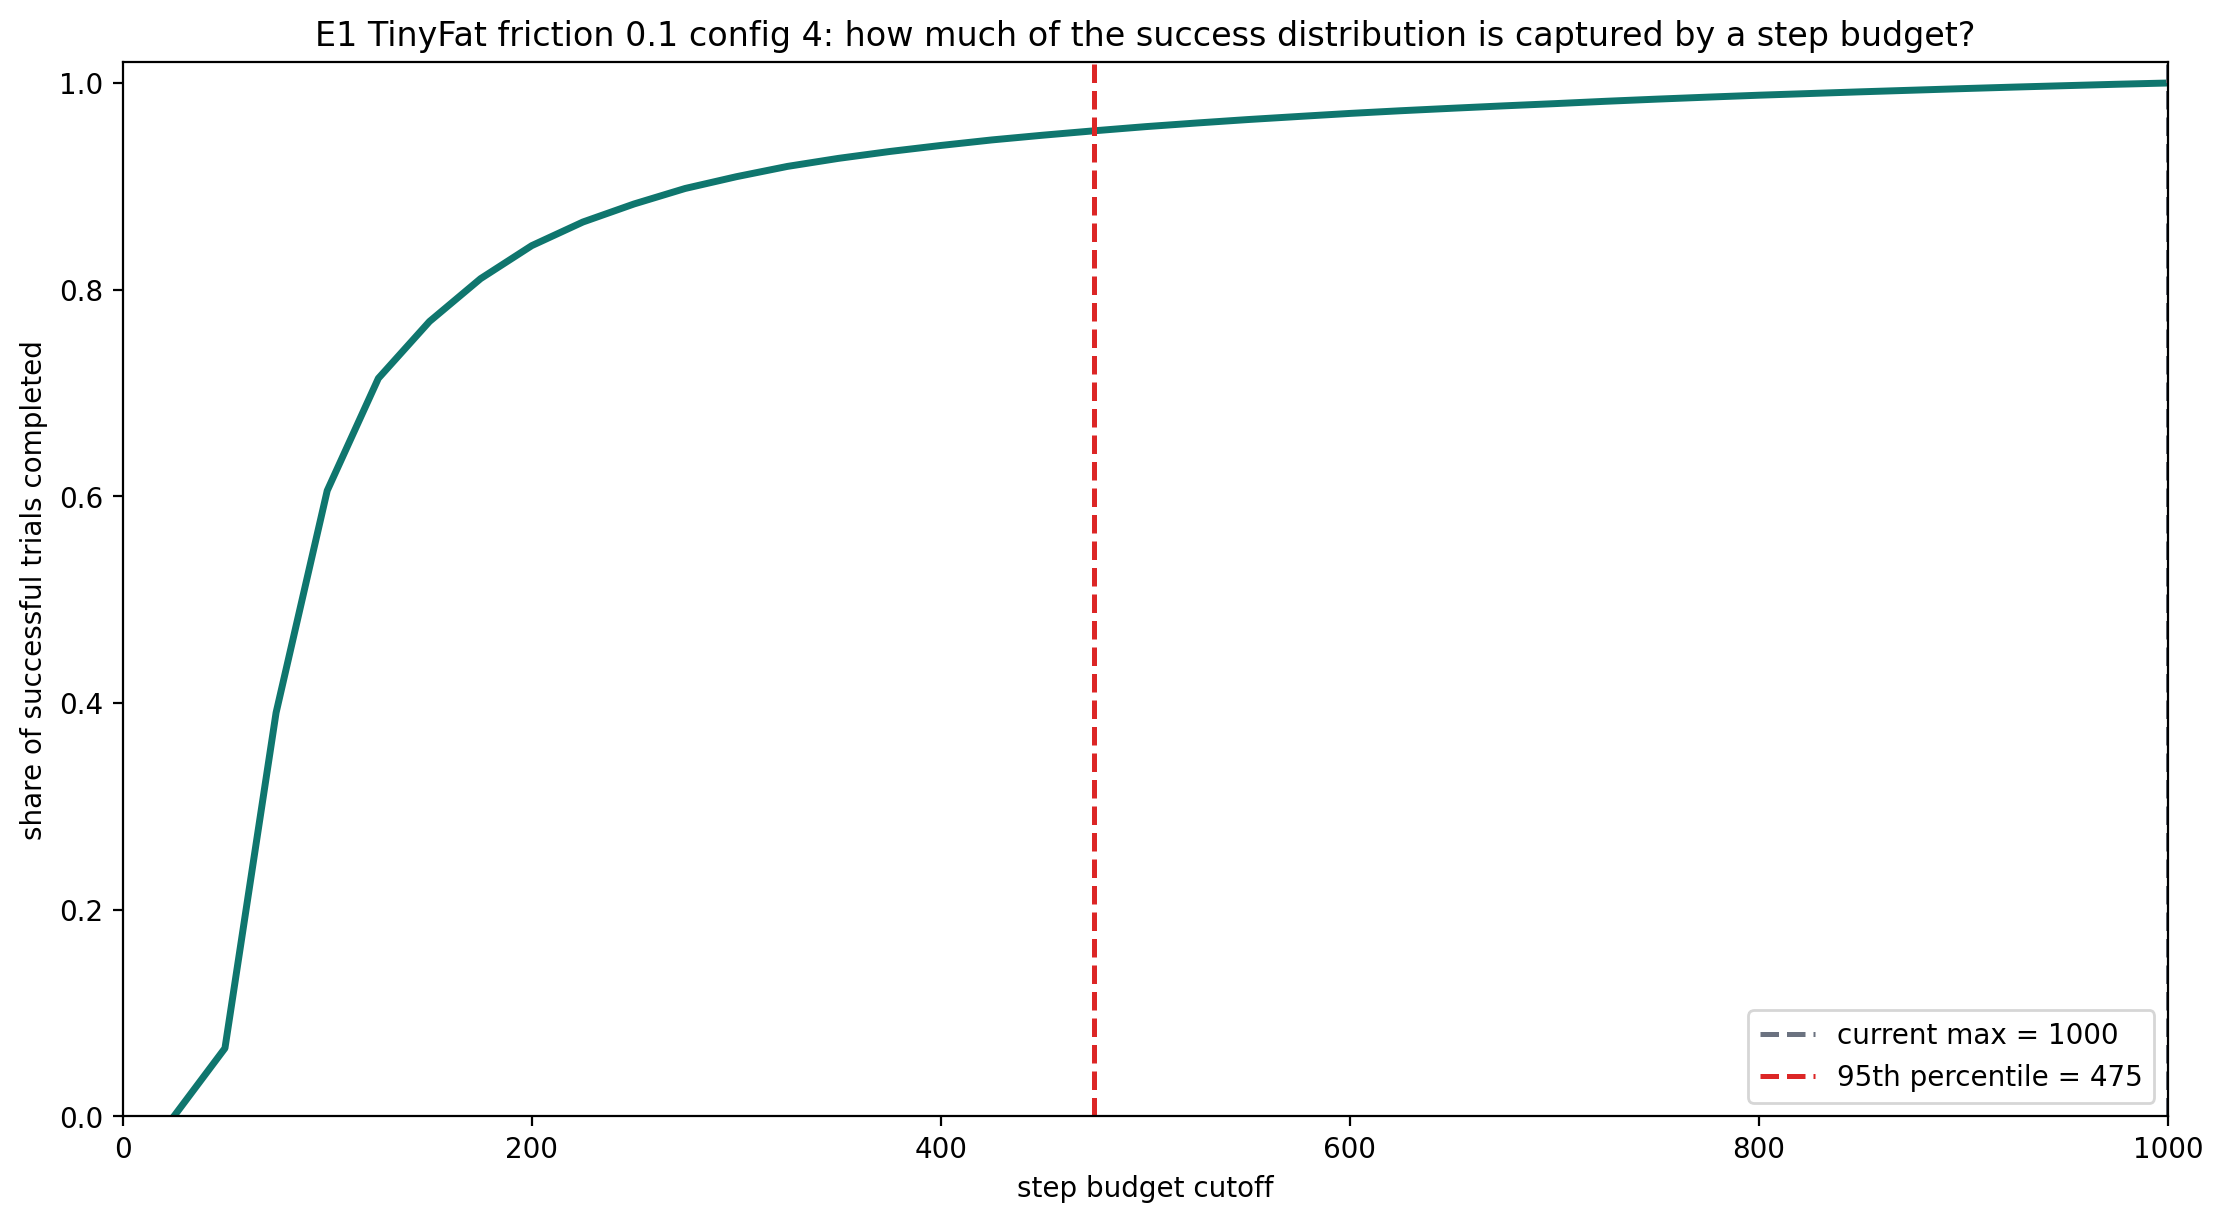

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_4_step_budget_curve.png`

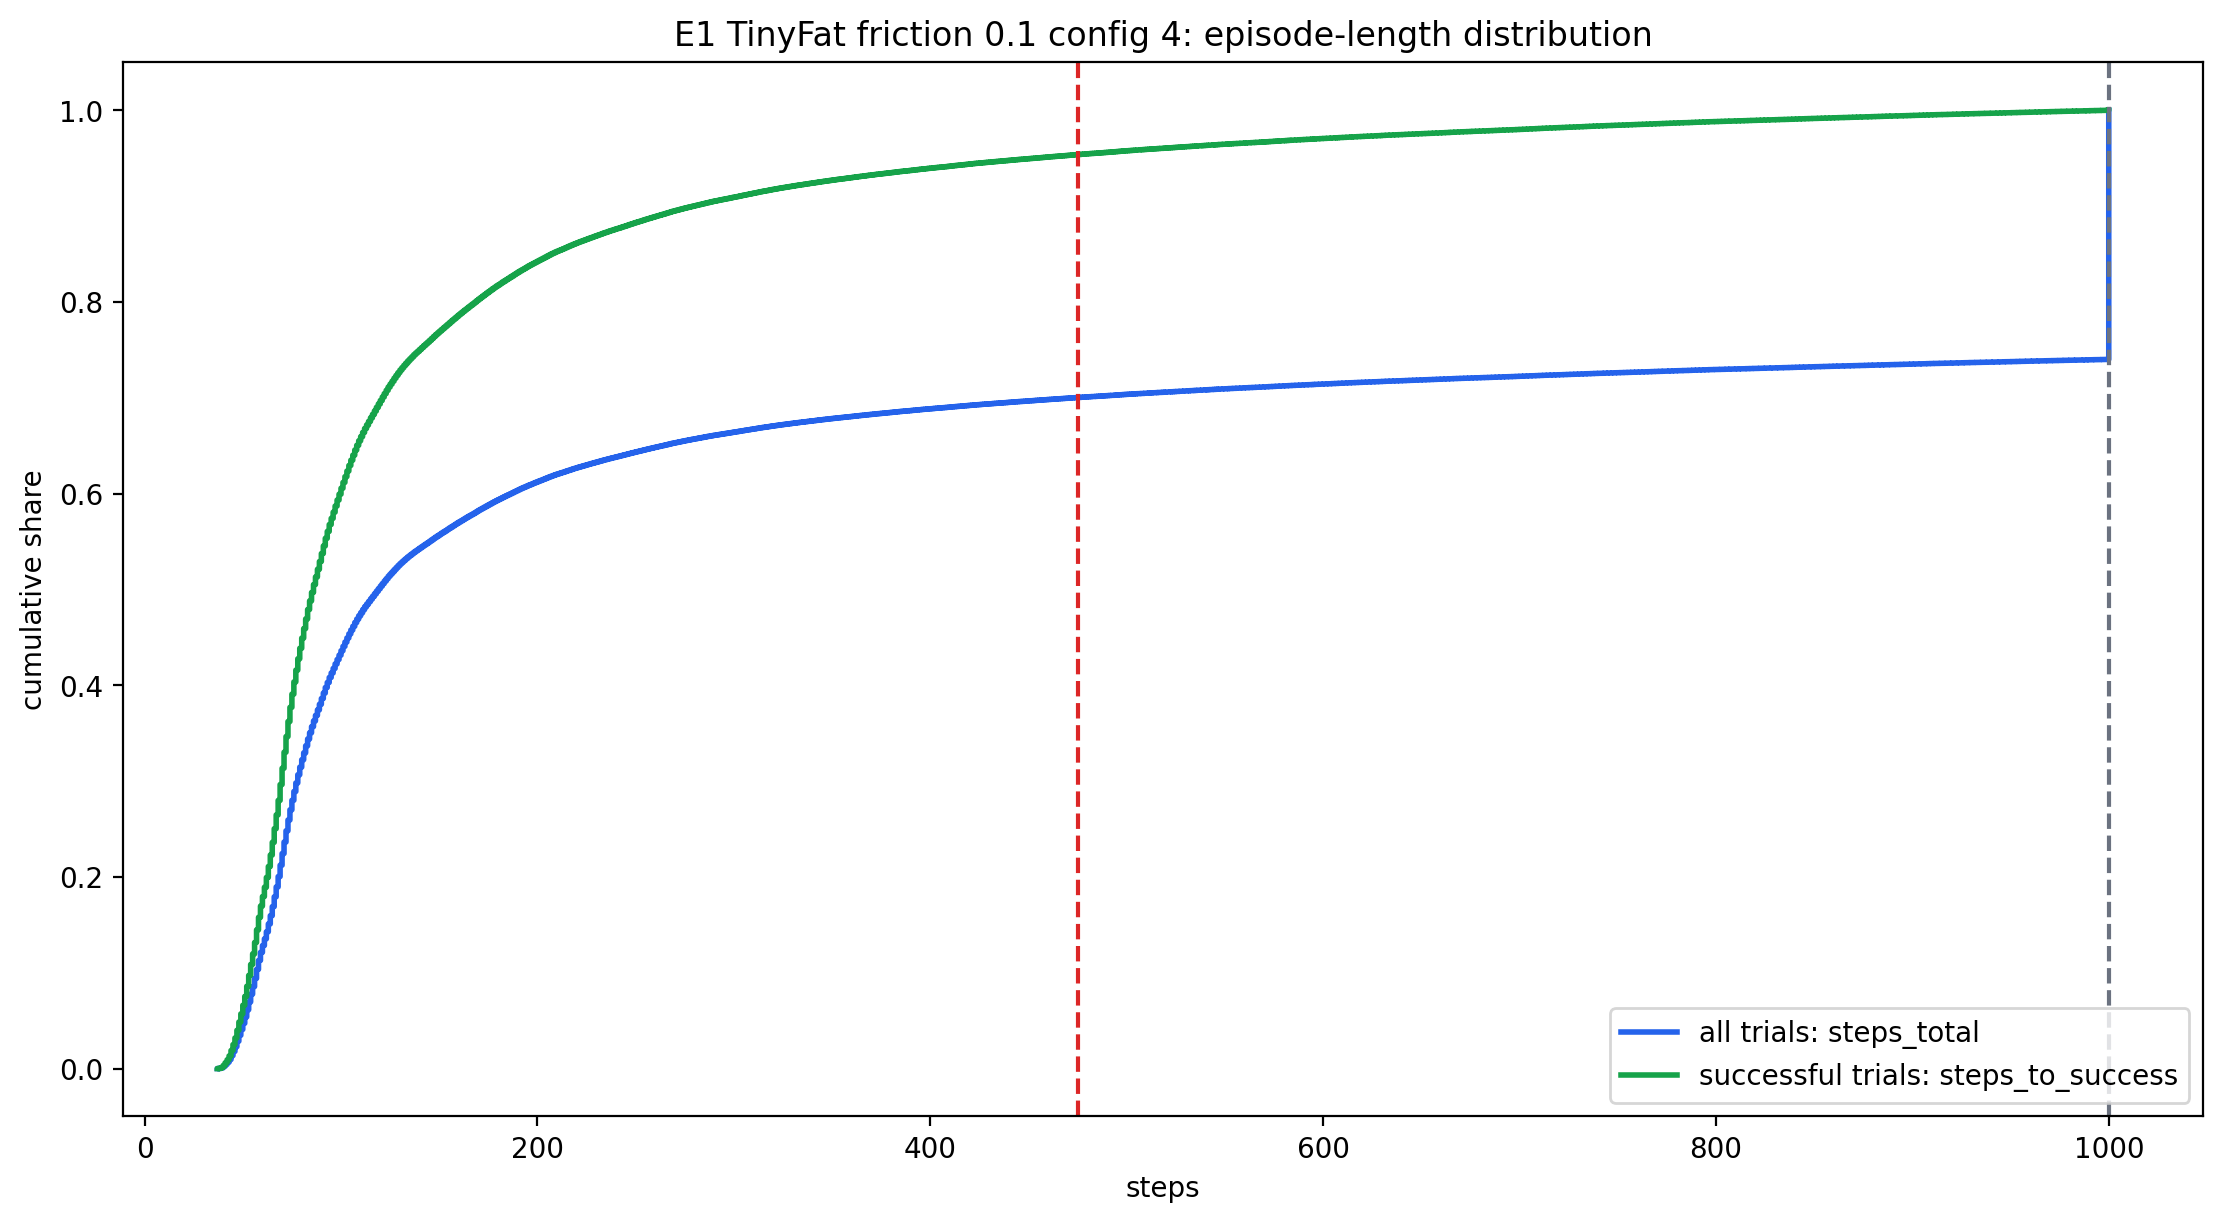

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_4_episode_length_ecdf.png`

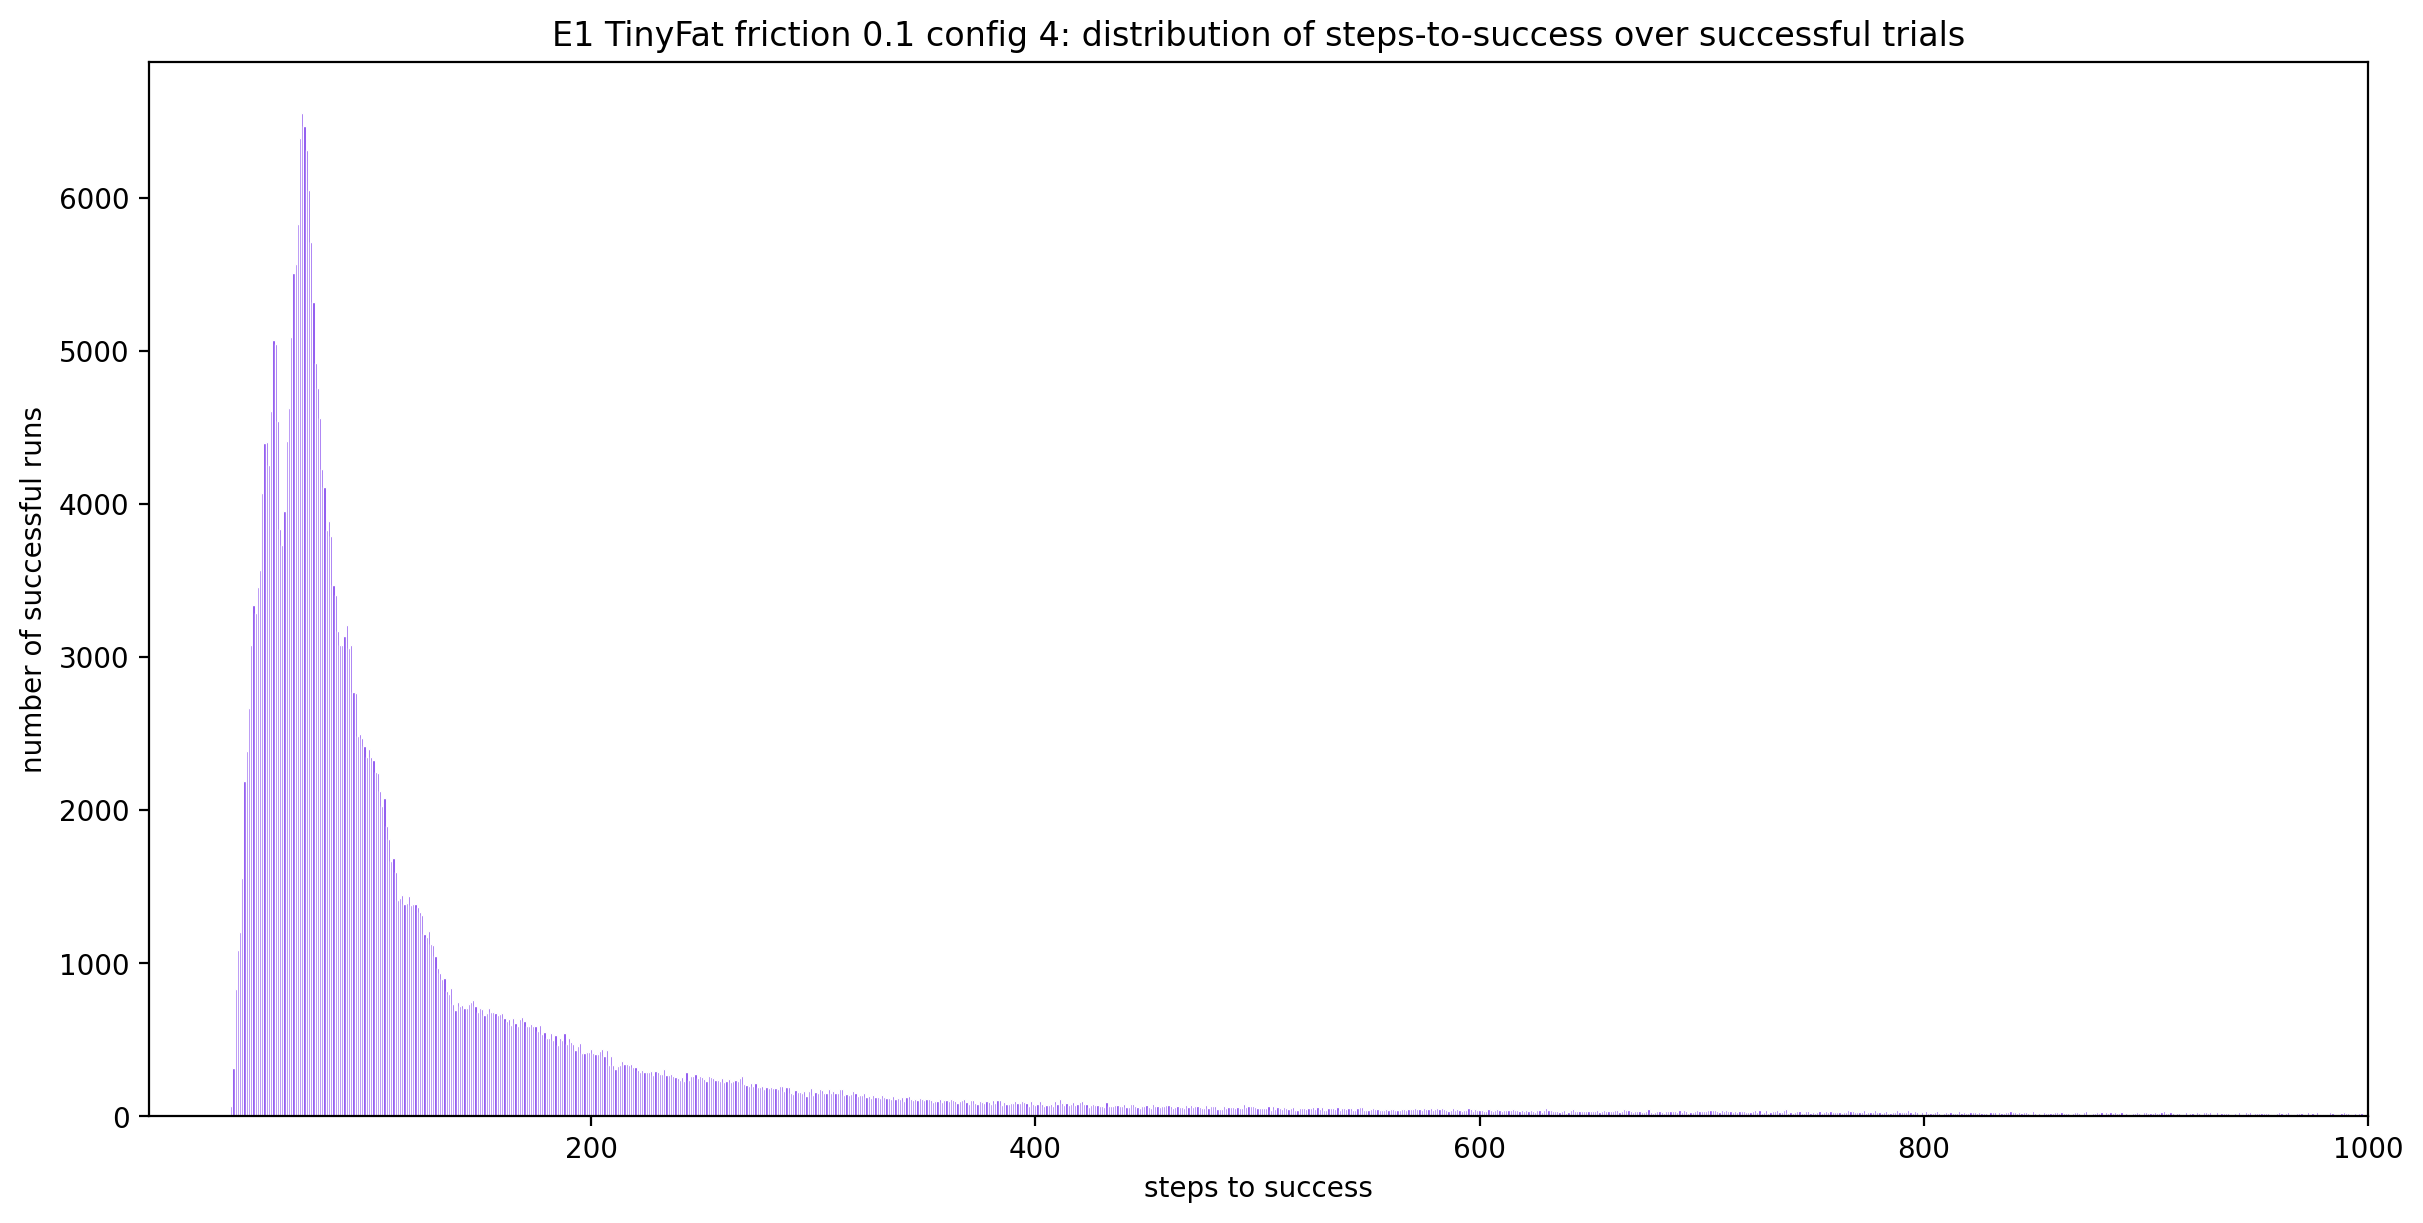

*Saved:* `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_tinyfat_friction_01_real/e1_tinyfat_friction_01_e0_style_config_4_success_steps_hist.png`

In [10]:
# E1 TinyFat friction 0.1: additional E0-style step-budget analysis per config

# Direct-run bootstrap: this lets the Step 6 cell run after a kernel restart.
from pathlib import Path
from typing import Optional
import importlib
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

if "PROJECT_ROOT" not in globals():
    def find_project_root(start: Optional[Path] = None) -> Path:
        start = Path.cwd() if start is None else Path(start)
        for candidate in (start, *start.parents):
            helper = candidate / "experiments" / "master-thesis" / "notebook_helpers" / "e1_analysis.py"
            if helper.exists():
                return candidate.resolve()
        raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")

    PROJECT_ROOT = find_project_root()

HELPER_DIR = PROJECT_ROOT / "experiments" / "master-thesis" / "notebook_helpers"
for _path in (PROJECT_ROOT, HELPER_DIR):
    if str(_path) not in sys.path:
        sys.path.insert(0, str(_path))

import e1_analysis as e1_analysis_module
importlib.reload(e1_analysis_module)
from e1_analysis import (
    analyze_e1_e0_style_results_by_config,
    load_e1_result_rows,
)

if "E1_TINYFAT_01_ROOT" not in globals():
    E1_TINYFAT_01_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_friction_01_real"
if "E1_TINYFAT_01_ANALYSIS_ROOT" not in globals():
    E1_TINYFAT_01_ANALYSIS_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_tinyfat_friction_01_real"
E1_TINYFAT_01_ANALYSIS_ROOT.mkdir(parents=True, exist_ok=True)

if "trial_df_01" not in globals() or "candidate_df_01" not in globals():
    manifest_rows_01, summary_rows_01, trial_rows_01 = load_e1_result_rows(E1_TINYFAT_01_ROOT)
    manifest_df_01 = pd.DataFrame(manifest_rows_01)
    candidate_df_01 = pd.DataFrame(summary_rows_01)
    trial_df_01 = pd.DataFrame(trial_rows_01)

    for _column in ["config_id", "target_index", "trial_count", "max_episode_steps", "n_trials_total", "trial_rows_loaded", "friction"]:
        if _column in manifest_df_01.columns:
            manifest_df_01[_column] = pd.to_numeric(manifest_df_01[_column], errors="coerce")
    for _column in ["config_id", "target_index", "score_total", "candidate_score_final", "score_mean", "success_rate", "valid_rate", "friction"]:
        if _column in candidate_df_01.columns:
            candidate_df_01[_column] = pd.to_numeric(candidate_df_01[_column], errors="coerce")
    for _column in ["config_id", "target_index", "score_total", "trial_index", "steps_total", "wire_force_normal_trial_max_N", "friction"]:
        if _column in trial_df_01.columns:
            trial_df_01[_column] = pd.to_numeric(trial_df_01[_column], errors="coerce")
if trial_df_01.empty:
    display(Markdown("""#### No trial rows available yet
- The synced E1 result tree currently contains no readable `trials.h5` rows for this friction setting.
- Once more results are synced, rerun this cell to generate the per-config E0-style plots and derived tables."""))
    if not candidate_df_01.empty:
        display(Markdown("#### Candidate summary rows loaded from CSV"))
        summary_columns_01 = [
            column
            for column in [
                "execution_wire",
                "trial_count",
                "success_rate",
                "score_mean",
                "score_std",
                "steps_total_mean",
                "steps_to_success_mean",
                "wire_force_normal_trial_max_mean_N",
                "tip_force_normal_trial_max_mean_N",
            ]
            if column in candidate_df_01.columns
        ]
        display(candidate_df_01[summary_columns_01].head(20) if summary_columns_01 else candidate_df_01.head(20))
    else:
        display(Markdown("**No candidate summary rows were loaded either.**"))
else:
    e1_e0_style_by_config_01 = analyze_e1_e0_style_results_by_config(
        trial_df_01.to_dict("records"),
        analysis_root=E1_TINYFAT_01_ANALYSIS_ROOT,
        prefix="e1_tinyfat_friction_01_e0_style",
        title_prefix="E1 TinyFat friction 0.1",
    )

    if not e1_e0_style_by_config_01:
        display(Markdown("**No per-config E0-style analyses could be built. Check that `config_id` is present in `trial_df`.**"))

    for config_id_01, analysis_01 in e1_e0_style_by_config_01.items():
        display(Markdown(f"### Config {config_id_01}: candidate summary"))
        display(pd.DataFrame(analysis_01["candidate_rows"]))

        if analysis_01["percentiles_rows"]:
            display(Markdown(f"### Config {config_id_01}: step-budget percentiles for successful trials"))
            percentiles_df_01 = pd.DataFrame(analysis_01["percentiles_rows"])
            display(percentiles_df_01)
            summary_lines_01 = [
                f"- config: `{config_id_01}`",
                f"- current max_episode_steps: `{analysis_01['current_max']}`",
                f"- suggested 95th-percentile cutoff: `{analysis_01['recommended_cutoff']}` steps",
                f"- successful trials analyzed: `{len(analysis_01['successful_steps'])}`",
                f"- all readable trials analyzed: `{len(analysis_01['all_steps'])}`",
            ]
            display(Markdown("\n".join(summary_lines_01)))
        else:
            display(Markdown(f"**Config {config_id_01}: no successful trials were found yet.**"))

        for image_name in [
            f"e1_tinyfat_friction_01_e0_style_config_{config_id_01}_candidate_summary.png",
            f"e1_tinyfat_friction_01_e0_style_config_{config_id_01}_step_budget_curve.png",
            f"e1_tinyfat_friction_01_e0_style_config_{config_id_01}_episode_length_ecdf.png",
            f"e1_tinyfat_friction_01_e0_style_config_{config_id_01}_success_steps_hist.png",
        ]:
            image_path = E1_TINYFAT_01_ANALYSIS_ROOT / image_name
            if image_path.exists():
                display(Image(filename=str(image_path)))
                display(Markdown(f"*Saved:* `{image_path}`"))


### E1 answer field

- Recommended `max_episode_steps`: `________`
- Recommended friction setting: `________`
- Recommended E1 config: `________`
- Evidence summary: `________`

E1 config definitions:

- Config 1: deterministic policy, fixed start, 1 trial.
- Config 2: deterministic policy, random start, 1000 trials.
- Config 3: stochastic policy, fixed start, 1000 trials.
- Config 4: stochastic policy, random start, 1000 trials.


### Step 7: select an execution wire
Run this cell first, then type the displayed `wire_id` into `E1_01_VISUAL_WIRE_ID`. The next step will only show trials for that wire.

In [ ]:
# E1 TinyFat friction 0.1: Step 7 - select execution wire
E1_01_VISUAL_WIRE_ID = 0

if trial_df_01.empty or "execution_wire" not in trial_df_01.columns:
    e1_visual_wire_df_01 = pd.DataFrame()
    display(Markdown("No readable trial rows with execution wires are available."))
else:
    e1_visual_wire_df_01 = (
        trial_df_01.groupby("execution_wire", dropna=False)
        .agg(
            trial_rows=("execution_wire", "size"),
            configs=("config_id", lambda s: ", ".join(str(int(v)) for v in sorted(pd.Series(s).dropna().unique()))),
            policies=("candidate_name", lambda s: ", ".join(str(v) for v in sorted(pd.Series(s).dropna().unique()))),
        )
        .reset_index()
        .sort_values("execution_wire")
        .reset_index(drop=True)
    )
    e1_visual_wire_df_01.insert(0, "wire_id", range(len(e1_visual_wire_df_01)))
    display(Markdown("### Available execution wires"))
    display(e1_visual_wire_df_01)

    selected_wire_rows_01 = e1_visual_wire_df_01.loc[
        e1_visual_wire_df_01["wire_id"].eq(E1_01_VISUAL_WIRE_ID)
    ]
    if selected_wire_rows_01.empty:
        valid_ids = e1_visual_wire_df_01["wire_id"].tolist()
        raise ValueError(f"Unknown E1_01_VISUAL_WIRE_ID={E1_01_VISUAL_WIRE_ID}. Valid ids: {valid_ids}")
    E1_01_VISUAL_WIRE = selected_wire_rows_01.iloc[0]["execution_wire"]
    display(Markdown(f"**Selected wire:** `{E1_01_VISUAL_WIRE}`"))


### Step 8: select one concrete trial
For the selected wire, this samples 10 random trials per policy/candidate and config. Use one `selection_id` from these tables in the next cell.

In [ ]:
# E1 TinyFat friction 0.1: Step 8 - trial-level visual rerun selection table
E1_01_VISUAL_RANDOM_SEED = 42
E1_01_VISUAL_TRIALS_PER_POLICY_CONFIG = 10

if "E1_01_VISUAL_WIRE" not in globals():
    display(Markdown("Run Step 7 first to select an execution wire."))
elif trial_df_01.empty:
    e1_visual_df_01 = pd.DataFrame()
    display(Markdown("No readable trial rows are available for visual rerun selection."))
else:
    selected_trials_01 = trial_df_01.loc[trial_df_01["execution_wire"].eq(E1_01_VISUAL_WIRE)].copy()
    if selected_trials_01.empty:
        e1_visual_df_01 = pd.DataFrame()
        display(Markdown(f"No trial rows found for wire `{E1_01_VISUAL_WIRE}`."))
    else:
        sampled_01 = (
            selected_trials_01
            .groupby(["config_id", "candidate_name"], dropna=False, group_keys=False)
            .apply(lambda g: g.sample(n=min(E1_01_VISUAL_TRIALS_PER_POLICY_CONFIG, len(g)), random_state=E1_01_VISUAL_RANDOM_SEED))
            .reset_index(drop=True)
        )
        e1_visual_rows_01 = build_e1_visual_selection_table(
            sampled_01.to_dict("records"),
            max_rows_per_config=None,
            representative="worst_score",
        )
        e1_visual_df_01 = pd.DataFrame(e1_visual_rows_01)
        display(Markdown(f"### Selectable visual reruns for `{E1_01_VISUAL_WIRE}`: {len(e1_visual_df_01)} trial rows"))

        if e1_visual_df_01.empty:
            display(Markdown("No selectable visual rerun rows could be built."))
        else:
            visual_cols_01 = [
                "selection_id", "config_id", "anatomy_id", "target_index", "target_seed",
                "execution_wire", "candidate_name", "trial_index", "env_seed", "policy_seed",
                "success", "valid_for_ranking", "end_reason", "score_total", "score_safety",
                "steps_total", "steps_to_success", "wire_force_normal_trial_max_N",
                "wire_force_normal_trial_mean_N", "tip_force_normal_trial_max_N", "wall_time_s",
            ]
            visual_cols_01 = [c for c in visual_cols_01 if c in e1_visual_df_01.columns]
            for config_id in sorted(e1_visual_df_01["config_id"].dropna().unique()):
                cfg_df = (
                    e1_visual_df_01.loc[e1_visual_df_01["config_id"].eq(config_id), visual_cols_01]
                    .sort_values(["candidate_name", "trial_index", "selection_id"])
                    .reset_index(drop=True)
                )
                display(Markdown(f"#### Config {int(config_id)}"))
                display(cfg_df)


### Step 9: generate a single visualized rerun command
Enter one `selection_id` from Step 8. The generated command reuses the selected config mode, anatomy, target seed, environment seed, policy seed when present, candidate policy, execution wire, and friction.

In [ ]:
# E1 TinyFat friction 0.1: Step 9 - generate visualized Eval V2 rerun command
E1_01_VISUAL_SELECTION_ID = 0
E1_01_VISUAL_FRICTION = 0.1

if "e1_visual_df_01" not in globals() or e1_visual_df_01.empty:
    display(Markdown("Run Step 8 first; no visual selection table is available."))
else:
    selected_01 = e1_visual_df_01.loc[
        e1_visual_df_01["selection_id"].eq(E1_01_VISUAL_SELECTION_ID)
    ]
    if selected_01.empty:
        valid_ids = e1_visual_df_01["selection_id"].head(20).tolist()
        raise ValueError(
            f"Unknown E1_01_VISUAL_SELECTION_ID={E1_01_VISUAL_SELECTION_ID}. "
            f"Example valid ids: {valid_ids}"
        )

    selected_row_01 = selected_01.iloc[0].to_dict()
    display(Markdown("### Selected visual rerun"))
    display(pd.DataFrame([selected_row_01]))

    command_01 = e1_visual_command_from_selection(
        selected_row_01,
        output_root=PROJECT_ROOT / "results" / "master_thesis" / "e1_visual_reruns" / "friction_01",
        friction=E1_01_VISUAL_FRICTION,
    )
    print(command_01)
    display(Markdown("```bash\n" + command_01 + "\n```"))


## E1 TinyFat friction comparison
\n
This section compares the old E1 TinyFat friction `0.001` run against the new friction `0.1` run. It deliberately uses the small per-job `candidate_summaries.csv` artifacts instead of loading `trials.h5`, so it is safe to run locally even while HDF5 files are corrupt, partial, or still being resubmitted. Rows are joined on `(config, anatomy, target, execution wire)`.\n

In [9]:
# E1 friction comparison: Step 1 - lightweight load from candidate_summaries.csv only
from pathlib import Path
from typing import Optional
import csv
import json
import sys

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

if "PROJECT_ROOT" not in globals():
    def find_project_root(start: Optional[Path] = None) -> Path:
        start = Path.cwd() if start is None else Path(start)
        for candidate in (start, *start.parents):
            helper = candidate / "experiments" / "master-thesis" / "notebook_helpers" / "e1_analysis.py"
            if helper.exists():
                return candidate.resolve()
        raise FileNotFoundError("Could not locate the project root from the current notebook working directory.")

    PROJECT_ROOT = find_project_root()

E1_TINYFAT_0001_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_0001_merged"
E1_TINYFAT_01_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_tinyfat_friction_01_real"
E1_FRICTION_COMPARISON_ROOT = PROJECT_ROOT / "results" / "master_thesis" / "e1_analysis_friction_comparison"
E1_FRICTION_COMPARISON_ROOT.mkdir(parents=True, exist_ok=True)


def _read_json(path: Path):
    return json.loads(path.read_text(encoding="utf-8"))


def _local_run_dir(result_root: Path, output_dir: str) -> Path:
    """Map cluster/local manifest output_dir to this checkout's result root."""
    text = str(output_dir)
    marker = "/runs/"
    if marker in text:
        return result_root / "runs" / text.split(marker, 1)[1]
    path = Path(text)
    return path if path.is_absolute() and path.exists() else result_root / path


def _load_e1_candidate_summaries_light(result_root: Path, friction_label: str):
    result_root = Path(result_root).resolve()
    manifest_paths = sorted((result_root / "metadata").glob("job_manifest*.json"))
    if not manifest_paths:
        raise FileNotFoundError(f"No metadata/job_manifest*.json files found under {result_root}")

    jobs_by_output = {}
    for manifest_path in manifest_paths:
        payload = _read_json(manifest_path)
        for array_index, job in enumerate(payload.get("jobs", [])):
            run_dir = _local_run_dir(result_root, job.get("output_dir", ""))
            jobs_by_output[str(run_dir)] = {**job, "array_index": array_index, "run_dir": run_dir}

    coverage_rows = []
    summary_rows = []
    for job in sorted(jobs_by_output.values(), key=lambda item: int(item.get("array_index", 0))):
        run_dir = Path(job["run_dir"])
        candidate_csv = run_dir / "candidate_summaries.csv"
        manifest_json = run_dir / "manifest.json"
        trials_h5 = run_dir / "trials.h5"
        target_spec = job.get("target_spec") or {}
        coverage_rows.append(
            {
                "friction_label": friction_label,
                "array_index": job.get("array_index"),
                "job_name": job.get("job_name"),
                "config_id": job.get("config_id"),
                "anatomy_id": job.get("anatomy_id"),
                "target_index": job.get("target_index"),
                "target_seed": target_spec.get("target_seed"),
                "seed_base": job.get("seed_base"),
                "candidate_csv_exists": candidate_csv.exists(),
                "manifest_json_exists": manifest_json.exists(),
                "trials_h5_exists": trials_h5.exists(),
                "trials_h5_size_mb": trials_h5.stat().st_size / 1_000_000 if trials_h5.exists() else 0.0,
                "run_dir": str(run_dir),
            }
        )
        if not candidate_csv.exists():
            continue
        with candidate_csv.open("r", encoding="utf-8", newline="") as handle:
            for row in csv.DictReader(handle):
                row.update(
                    {
                        "friction_label": friction_label,
                        "array_index": job.get("array_index"),
                        "job_name": job.get("job_name"),
                        "config_id": job.get("config_id"),
                        "anatomy_id": job.get("anatomy_id"),
                        "target_index": job.get("target_index"),
                        "target_seed": target_spec.get("target_seed"),
                        "seed_base": job.get("seed_base"),
                        "run_dir": str(run_dir),
                    }
                )
                summary_rows.append(row)

    coverage_df = pd.DataFrame(coverage_rows)
    summary_df = pd.DataFrame(summary_rows)
    return coverage_df, summary_df

coverage_df_0001_light, candidate_df_0001_light = _load_e1_candidate_summaries_light(E1_TINYFAT_0001_ROOT, "0.001")
coverage_df_01_light, candidate_df_01_light = _load_e1_candidate_summaries_light(E1_TINYFAT_01_ROOT, "0.1")

coverage_compare_light = (
    pd.concat([coverage_df_0001_light, coverage_df_01_light], ignore_index=True)
    .groupby(["friction_label", "config_id", "candidate_csv_exists", "manifest_json_exists"], dropna=False)
    .size()
    .reset_index(name="jobs")
    .sort_values(["friction_label", "config_id", "candidate_csv_exists", "manifest_json_exists"])
)

display(Markdown("### Lightweight artifact coverage"))
display(coverage_compare_light)
print(f"candidate rows 0.001: {len(candidate_df_0001_light):,}")
print(f"candidate rows 0.1:   {len(candidate_df_01_light):,}")
print(f"comparison output: {E1_FRICTION_COMPARISON_ROOT}")


### Lightweight artifact coverage

,friction_label,config_id,candidate_csv_exists,manifest_json_exists,jobs
0,0.001,1,True,True,36
1,0.001,2,False,False,10
2,0.001,2,True,True,26
3,0.001,3,False,False,6
4,0.001,3,True,True,30
5,0.001,4,False,False,8
6,0.001,4,True,True,28
7,0.1,1,True,True,36
8,0.1,2,False,False,14
9,0.1,2,True,True,22


candidate rows 0.001: 1,800
candidate rows 0.1:   1,635
comparison output: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_friction_comparison


In [10]:
# E1 friction comparison: Step 2 - build paired per-wire summaries
PAIR_KEYS = ["config_id", "anatomy_id", "target_index", "execution_wire"]
SCENARIO_KEYS = ["config_id", "anatomy_id", "target_index"]


def _prepare_candidate_summary(df: pd.DataFrame, friction_label: str) -> pd.DataFrame:
    out = df.copy()
    for key in PAIR_KEYS:
        if key not in out.columns:
            out[key] = None
    for column in [
        "success_rate",
        "valid_rate",
        "candidate_score_final",
        "score_mean",
        "score_std",
        "soft_score_mean_valid",
        "steps_to_success_mean",
        "steps_total_mean",
        "tip_speed_max_mean_mm_s",
        "wire_force_normal_trial_max_mean_N",
        "trial_count",
    ]:
        if column in out.columns:
            out[column] = pd.to_numeric(out[column], errors="coerce")
        else:
            out[column] = float("nan")
    # One row per run/wire is expected, but aggregate defensively in case a CSV was merged twice.
    grouped = out.groupby(PAIR_KEYS, dropna=False)
    summary = grouped.agg(
        rows=("candidate_name", "count"),
        candidate_name=("candidate_name", "first"),
        trained_on_wire=("trained_on_wire", "first"),
        trial_count=("trial_count", "sum"),
        success_rate=("success_rate", "mean"),
        valid_rate=("valid_rate", "mean"),
        candidate_score_final=("candidate_score_final", "mean"),
        score_mean=("score_mean", "mean"),
        soft_score_mean_valid=("soft_score_mean_valid", "mean"),
        steps_to_success_mean=("steps_to_success_mean", "mean"),
        steps_total_mean=("steps_total_mean", "mean"),
        wire_force_normal_trial_max_mean_N=("wire_force_normal_trial_max_mean_N", "mean"),
        tip_speed_max_mean_mm_s=("tip_speed_max_mean_mm_s", "mean"),
    ).reset_index()
    summary["friction_label"] = friction_label
    return summary

agg_0001 = _prepare_candidate_summary(candidate_df_0001_light, "0.001")
agg_01 = _prepare_candidate_summary(candidate_df_01_light, "0.1")

paired = agg_0001.merge(agg_01, on=PAIR_KEYS, how="inner", suffixes=("_0001", "_01"))

for metric in [
    "success_rate",
    "valid_rate",
    "candidate_score_final",
    "score_mean",
    "soft_score_mean_valid",
    "steps_to_success_mean",
    "steps_total_mean",
    "wire_force_normal_trial_max_mean_N",
    "tip_speed_max_mean_mm_s",
]:
    paired[f"delta_{metric}"] = paired[f"{metric}_01"] - paired[f"{metric}_0001"]

paired_path = E1_FRICTION_COMPARISON_ROOT / "e1_friction_paired_candidate_metrics.csv"
paired.to_csv(paired_path, index=False)

display(Markdown("### Paired candidate-summary coverage"))
display(pd.DataFrame({
    "table": ["0.001 candidate summaries", "0.1 candidate summaries", "paired common rows"],
    "rows": [len(agg_0001), len(agg_01), len(paired)],
    "unique_scenarios": [
        agg_0001[SCENARIO_KEYS].drop_duplicates().shape[0],
        agg_01[SCENARIO_KEYS].drop_duplicates().shape[0],
        paired[SCENARIO_KEYS].drop_duplicates().shape[0],
    ],
}))
print(f"saved paired metrics: {paired_path}")


### Paired candidate-summary coverage

,table,rows,unique_scenarios
0,0.001 candidate summaries,1800,120
1,0.1 candidate summaries,1635,109
2,paired common rows,1590,106


saved paired metrics: /home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_friction_comparison/e1_friction_paired_candidate_metrics.csv


In [11]:
# E1 friction comparison: Step 3 - tables for score, success and force shifts
if paired.empty:
    display(Markdown("No paired friction rows available. Candidate summaries must exist in both result roots."))
else:
    scenario_count = paired[SCENARIO_KEYS].drop_duplicates().groupby("config_id").size().rename("scenarios")
    config_delta = (
        paired.groupby("config_id", dropna=False)
        .agg(
            paired_wire_cases=("execution_wire", "count"),
            delta_success_mean=("delta_success_rate", "mean"),
            delta_valid_mean=("delta_valid_rate", "mean"),
            delta_candidate_score_mean=("delta_candidate_score_final", "mean"),
            delta_score_mean=("delta_score_mean", "mean"),
            delta_soft_score_valid_mean=("delta_soft_score_mean_valid", "mean"),
            delta_force_mean_N=("delta_wire_force_normal_trial_max_mean_N", "mean"),
            delta_steps_total_mean=("delta_steps_total_mean", "mean"),
            frac_success_improved=("delta_success_rate", lambda values: (values > 0).mean()),
            frac_success_worse=("delta_success_rate", lambda values: (values < 0).mean()),
            frac_force_higher=("delta_wire_force_normal_trial_max_mean_N", lambda values: (values > 0).mean()),
            frac_score_higher=("delta_score_mean", lambda values: (values > 0).mean()),
        )
        .join(scenario_count, on="config_id")
        .reset_index()
    )

    wire_delta = (
        paired.groupby(["config_id", "execution_wire"], dropna=False)
        .agg(
            paired_cases=("anatomy_id", "count"),
            delta_success_mean=("delta_success_rate", "mean"),
            delta_score_mean=("delta_score_mean", "mean"),
            delta_candidate_score_mean=("delta_candidate_score_final", "mean"),
            delta_force_mean_N=("delta_wire_force_normal_trial_max_mean_N", "mean"),
            success_0001=("success_rate_0001", "mean"),
            success_01=("success_rate_01", "mean"),
            force_0001_N=("wire_force_normal_trial_max_mean_N_0001", "mean"),
            force_01_N=("wire_force_normal_trial_max_mean_N_01", "mean"),
        )
        .reset_index()
        .sort_values(["config_id", "delta_score_mean"], ascending=[True, False])
    )

    delta_columns = [column for column in paired.columns if column.startswith("delta_")]
    delta_diagnostics = pd.DataFrame(
        {
            "metric": delta_columns,
            "max_abs_delta": [paired[column].abs().max(skipna=True) for column in delta_columns],
            "mean_abs_delta": [paired[column].abs().mean(skipna=True) for column in delta_columns],
        }
    )

    display(Markdown("### Mean paired deltas by config (`0.1 - 0.001`)"))
    display(config_delta)
    display(Markdown("### Per-wire paired deltas by config (`0.1 - 0.001`)"))
    display(wire_delta)
    display(Markdown("### Delta diagnostics"))
    display(delta_diagnostics)
    if delta_diagnostics["max_abs_delta"].fillna(0).max() == 0:
        display(Markdown("**All paired candidate-summary deltas are exactly zero.** That means the currently loaded summaries are identical for the common rows. Check whether the 0.1 result folder has been resynced after the latest jobs, and whether the old cluster runner actually applied `E1_FRICTION=0.1` inside the scene."))

    config_delta.to_csv(E1_FRICTION_COMPARISON_ROOT / "e1_friction_delta_by_config.csv", index=False)
    wire_delta.to_csv(E1_FRICTION_COMPARISON_ROOT / "e1_friction_delta_by_wire_config.csv", index=False)
    delta_diagnostics.to_csv(E1_FRICTION_COMPARISON_ROOT / "e1_friction_delta_diagnostics.csv", index=False)


### Mean paired deltas by config (`0.1 - 0.001`)

,config_id,paired_wire_cases,delta_success_mean,delta_valid_mean,delta_candidate_score_mean,delta_score_mean,delta_soft_score_valid_mean,delta_force_mean_N,delta_steps_total_mean,frac_success_improved,frac_success_worse,frac_force_higher,frac_score_higher,scenarios
0,1,540,0.000000,-0.012963,-0.012565,0.005692,-0.005056,0.711492,6.627778,0.053704,0.053704,0.590741,0.494444,36
1,2,315,-0.005394,-0.014098,-0.015192,-0.001168,-0.007011,0.601984,11.150644,0.209524,0.326984,0.780952,0.393651,21
2,3,360,-0.011111,-0.018717,-0.019077,-0.003196,-0.005954,0.649647,13.749778,0.211111,0.319444,0.822222,0.386111,24
3,4,375,-0.012061,-0.019840,-0.019836,-0.003512,-0.006289,0.671007,14.775285,0.213333,0.336000,0.821333,0.400000,25


### Per-wire paired deltas by config (`0.1 - 0.001`)

,config_id,execution_wire,paired_cases,delta_success_mean,delta_score_mean,delta_candidate_score_mean,delta_force_mean_N,success_0001,success_01,force_0001_N,force_01_N
8,1,steve_default/strong_hook,36,0.083333,0.085158,0.000000,2.707832,0.694444,0.777778,12.567154,15.274987
4,1,amplatz_super_stiff/tight_j,36,0.111111,0.068036,0.071358,0.002055,0.805556,0.916667,0.599715,0.601771
3,1,amplatz_super_stiff/strong_hook,36,0.083333,0.045206,0.046446,0.065616,0.750000,0.833333,0.643992,0.709608
14,1,universal_ii/tight_j,36,0.083333,0.043783,0.068078,0.007659,0.861111,0.944444,0.068559,0.076218
5,1,steve_default/gentle,36,0.027778,0.035810,-0.045240,2.741400,0.361111,0.388889,5.815148,8.556548
7,1,steve_default/straight,36,0.027778,0.035645,0.002514,2.572671,0.222222,0.250000,4.240806,6.813476
6,1,steve_default/standard_j,36,0.027778,0.015223,-0.001815,0.236757,0.777778,0.805556,6.195094,6.431851
9,1,steve_default/tight_j,36,-0.055556,0.006415,-0.020761,2.589082,0.750000,0.694444,7.218746,9.807828
13,1,universal_ii/strong_hook,36,-0.027778,-0.000368,-0.008662,0.001235,0.722222,0.694444,0.088043,0.089278
2,1,amplatz_super_stiff/straight,36,0.000000,-0.004911,-0.025157,-0.273570,0.277778,0.277778,1.069777,0.796207


### Delta diagnostics

,metric,max_abs_delta,mean_abs_delta
0,delta_success_rate,1.000000,0.061436
1,delta_valid_rate,1.000000,0.050818
2,delta_candidate_score_final,0.971637,0.050389
3,delta_score_mean,0.779260,0.054204
4,delta_soft_score_mean_valid,0.309588,0.014802
5,delta_steps_to_success_mean,873.000000,30.501831
6,delta_steps_total_mean,939.000000,59.802879
7,delta_wire_force_normal_trial_max_mean_N,30.925699,0.830570
8,delta_tip_speed_max_mean_mm_s,2.849505,0.104543


In [12]:
# E1 friction comparison: Step 4 - ranking/correlation stability per anatomy-target-config
if paired.empty:
    display(Markdown("No paired rows available for correlation analysis."))
else:
    scenario_rows = []
    for scenario_key, group in paired.groupby(SCENARIO_KEYS, dropna=False):
        row = dict(zip(SCENARIO_KEYS, scenario_key))
        row["n_wires"] = len(group)
        for metric in ["success_rate", "score_mean", "candidate_score_final", "wire_force_normal_trial_max_mean_N"]:
            left = pd.to_numeric(group[f"{metric}_0001"], errors="coerce")
            right = pd.to_numeric(group[f"{metric}_01"], errors="coerce")
            valid = left.notna() & right.notna()
            row[f"pearson_{metric}"] = left[valid].corr(right[valid], method="pearson") if valid.sum() >= 2 else float("nan")
            row[f"spearman_{metric}"] = left[valid].corr(right[valid], method="spearman") if valid.sum() >= 2 else float("nan")
        best_0001 = group.sort_values(["score_mean_0001", "success_rate_0001"], ascending=False).iloc[0]
        best_01 = group.sort_values(["score_mean_01", "success_rate_01"], ascending=False).iloc[0]
        row["best_wire_0001"] = best_0001["execution_wire"]
        row["best_wire_01"] = best_01["execution_wire"]
        row["best_wire_changed"] = row["best_wire_0001"] != row["best_wire_01"]
        row["best_score_delta"] = float(best_01["score_mean_01"] - best_0001["score_mean_0001"])
        scenario_rows.append(row)

    scenario_compare = pd.DataFrame(scenario_rows)
    ranking_summary = (
        scenario_compare.groupby("config_id", dropna=False)
        .agg(
            scenarios=("n_wires", "count"),
            best_wire_change_rate=("best_wire_changed", "mean"),
            spearman_score_mean=("spearman_score_mean", "mean"),
            spearman_success_rate=("spearman_success_rate", "mean"),
            spearman_candidate_score=("spearman_candidate_score_final", "mean"),
            spearman_force_mean=("spearman_wire_force_normal_trial_max_mean_N", "mean"),
            pearson_score_mean=("pearson_score_mean", "mean"),
        )
        .reset_index()
    )

    display(Markdown("### Ranking stability by anatomy-target-config"))
    display(ranking_summary)
    display(Markdown("### Most friction-sensitive scenarios by best-wire score delta"))
    display(
        scenario_compare.assign(abs_best_score_delta=scenario_compare["best_score_delta"].abs())
        .sort_values("abs_best_score_delta", ascending=False)
        .head(20)
    )

    scenario_compare.to_csv(E1_FRICTION_COMPARISON_ROOT / "e1_friction_scenario_ranking_stability.csv", index=False)
    ranking_summary.to_csv(E1_FRICTION_COMPARISON_ROOT / "e1_friction_ranking_stability_by_config.csv", index=False)


/home/hannes-deittert/miniconda3/envs/master-project/lib/python3.8/site-packages/scipy/stats/_stats_py.py:4916: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  warnings.warn(stats.ConstantInputWarning(warn_msg))


### Ranking stability by anatomy-target-config

,config_id,scenarios,best_wire_change_rate,spearman_score_mean,spearman_success_rate,spearman_candidate_score,spearman_force_mean,pearson_score_mean
0,1,36,0.361111,0.775936,0.677383,0.821367,0.934921,0.740573
1,2,21,0.142857,0.944898,0.847766,0.965069,0.983503,0.951031
2,3,24,0.250000,0.944643,0.816243,0.974151,0.988393,0.949736
3,4,25,0.320000,0.947000,0.829868,0.974099,0.987286,0.951838


### Most friction-sensitive scenarios by best-wire score delta

,config_id,anatomy_id,target_index,n_wires,pearson_success_rate,spearman_success_rate,pearson_score_mean,spearman_score_mean,pearson_candidate_score_final,spearman_candidate_score_final,pearson_wire_force_normal_trial_max_mean_N,spearman_wire_force_normal_trial_max_mean_N,best_wire_0001,best_wire_01,best_wire_changed,best_score_delta,abs_best_score_delta
25,1,Tree_7638,1,15,NaN,NaN,0.343709,0.717857,NaN,NaN,0.868734,0.914286,universal_ii/gentle,steve_default/strong_hook,True,0.397998,0.397998
26,1,Tree_7638,2,15,NaN,NaN,0.553843,0.667857,NaN,NaN,0.902657,0.928571,universal_ii/gentle,universal_ii/tight_j,True,0.384725,0.384725
7,1,Tree_1996,1,15,0.554700,0.554700,0.616783,0.510714,0.471076,0.476331,0.963835,0.975000,amplatz_super_stiff/standard_j,universal_ii/tight_j,True,0.060809,0.060809
2,1,Tree_1382,2,15,0.294174,0.294174,0.434188,0.492857,0.443608,0.418367,0.816123,0.932143,universal_ii/standard_j,amplatz_super_stiff/standard_j,True,-0.059947,0.059947
21,1,Tree_7363,0,15,0.600099,0.600099,0.574712,0.532143,0.435466,0.432473,0.973883,0.950000,universal_ii/standard_j,amplatz_super_stiff/tight_j,True,0.038140,0.038140
0,1,Tree_1382,0,15,0.472456,0.472456,0.447011,0.375000,0.764043,0.793335,0.706081,0.853571,universal_ii/tight_j,universal_ii/tight_j,False,-0.035145,0.035145
88,4,Tree_6399,0,15,0.795406,0.741733,0.813583,0.721429,0.865581,0.862963,0.995227,0.975000,universal_ii/strong_hook,universal_ii/gentle,True,-0.029127,0.029127
35,1,Tree_8547,2,15,0.554700,0.554700,0.669184,0.692857,0.467658,0.555719,0.837026,0.964286,universal_ii/standard_j,universal_ii/standard_j,False,0.026434,0.026434
65,3,Tree_6399,0,15,0.808890,0.689288,0.822886,0.657143,0.873563,0.866667,0.996781,0.975000,universal_ii/strong_hook,universal_ii/gentle,True,-0.026018,0.026018
42,2,Tree_6399,0,15,0.982579,0.922941,0.984709,0.950000,0.984494,0.981481,0.961554,0.985714,universal_ii/gentle,universal_ii/gentle,False,-0.024073,0.024073


Saved config delta plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_friction_comparison/e1_friction_delta_by_config.png`

Saved force-vs-score plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_friction_comparison/e1_friction_force_vs_score_delta.png`

Saved ranking-correlation plot: `/home/hannes-deittert/dev/Uni/master-project/results/master_thesis/e1_analysis_friction_comparison/e1_friction_ranking_correlation_by_config.png`

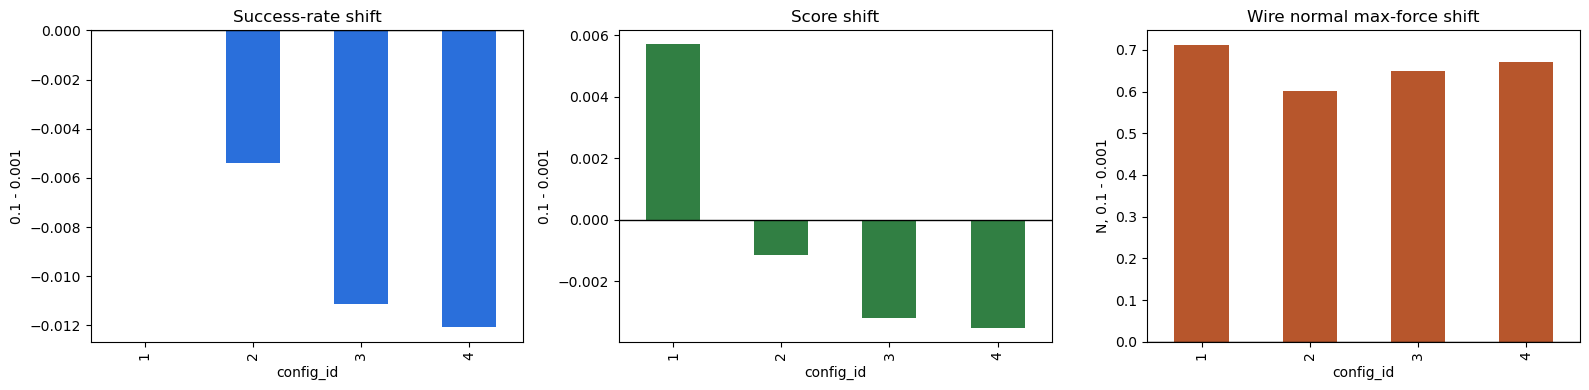

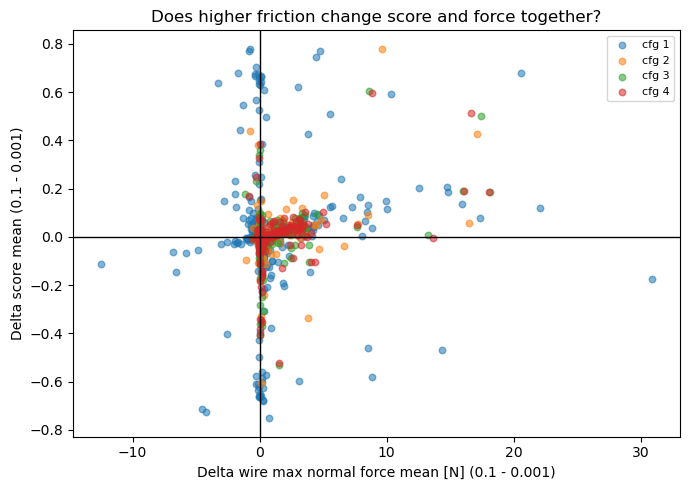

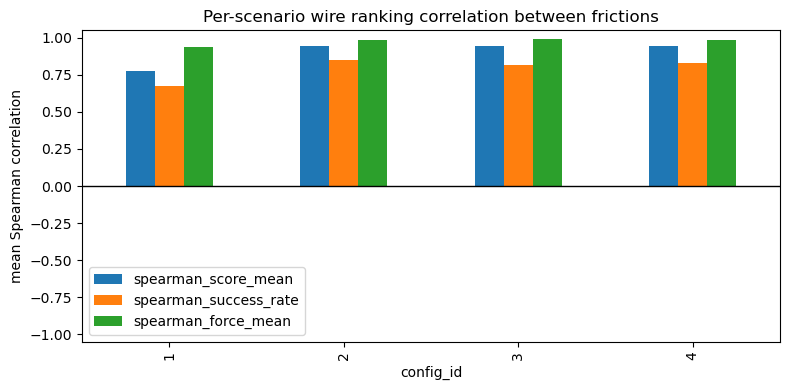

In [13]:
# E1 friction comparison: Step 5 - plots
if paired.empty:
    display(Markdown("No paired rows available for plots."))
else:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    config_delta.plot.bar(x="config_id", y="delta_success_mean", ax=axes[0], color="#2a6fdb", legend=False)
    axes[0].axhline(0, color="black", linewidth=1)
    axes[0].set_title("Success-rate shift")
    axes[0].set_ylabel("0.1 - 0.001")

    config_delta.plot.bar(x="config_id", y="delta_score_mean", ax=axes[1], color="#317f43", legend=False)
    axes[1].axhline(0, color="black", linewidth=1)
    axes[1].set_title("Score shift")
    axes[1].set_ylabel("0.1 - 0.001")

    config_delta.plot.bar(x="config_id", y="delta_force_mean_N", ax=axes[2], color="#b7562c", legend=False)
    axes[2].axhline(0, color="black", linewidth=1)
    axes[2].set_title("Wire normal max-force shift")
    axes[2].set_ylabel("N, 0.1 - 0.001")
    fig.tight_layout()
    summary_plot = E1_FRICTION_COMPARISON_ROOT / "e1_friction_delta_by_config.png"
    fig.savefig(summary_plot, dpi=200, bbox_inches="tight")
    display(Markdown(f"Saved config delta plot: `{summary_plot}`"))

    fig, ax = plt.subplots(figsize=(7, 5))
    for config_id, group in paired.groupby("config_id", dropna=False):
        ax.scatter(group["delta_wire_force_normal_trial_max_mean_N"], group["delta_score_mean"], alpha=0.55, s=22, label=f"cfg {config_id}")
    ax.axhline(0, color="black", linewidth=1)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_xlabel("Delta wire max normal force mean [N] (0.1 - 0.001)")
    ax.set_ylabel("Delta score mean (0.1 - 0.001)")
    ax.set_title("Does higher friction change score and force together?")
    ax.legend(loc="best", fontsize=8)
    fig.tight_layout()
    scatter_plot = E1_FRICTION_COMPARISON_ROOT / "e1_friction_force_vs_score_delta.png"
    fig.savefig(scatter_plot, dpi=200, bbox_inches="tight")
    display(Markdown(f"Saved force-vs-score plot: `{scatter_plot}`"))

    fig, ax = plt.subplots(figsize=(8, 4))
    ranking_summary.plot.bar(x="config_id", y=["spearman_score_mean", "spearman_success_rate", "spearman_force_mean"], ax=ax)
    ax.axhline(0, color="black", linewidth=1)
    ax.set_ylim(-1.05, 1.05)
    ax.set_title("Per-scenario wire ranking correlation between frictions")
    ax.set_ylabel("mean Spearman correlation")
    fig.tight_layout()
    ranking_plot = E1_FRICTION_COMPARISON_ROOT / "e1_friction_ranking_correlation_by_config.png"
    fig.savefig(ranking_plot, dpi=200, bbox_inches="tight")
    display(Markdown(f"Saved ranking-correlation plot: `{ranking_plot}`"))
